# Group 2 - Non-financial time-series analysis
---

- Navenkumar Balasubhramanium,
- Vikram Bhatt,
- Isabella Deabreu,
- Laurenz Jakob Kluth, and
- Sofia Mollon Laorca

In [ ]:
# Install libraries
!pip install statsforecast
!pip install seaborn
!pip install pandas
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.7/280.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.6 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [ ]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import requests
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Get data
data_url = "https://services.swpc.noaa.gov/json/solar-cycle/observed-solar-cycle-indices.json"
response = requests.get(data_url)

solar_cycle_data = pd.read_json(data_url)

print(solar_cycle_data.tail())

     time-tag    ssn  smoothed_ssn  observed_swpc_ssn  smoothed_swpc_ssn  \
3318  2025-07  125.6          -1.0             120.81               -1.0   
3319  2025-08  133.5          -1.0             133.71               -1.0   
3320  2025-09  129.8          -1.0             128.57               -1.0   
3321  2025-10  114.6          -1.0             107.06               -1.0   
3322  2025-11   91.8          -1.0              88.63               -1.0   

       f10.7  smoothed_f10.7  
3318  137.72            -1.0  
3319  156.11            -1.0  
3320  153.93            -1.0  
3321  139.68            -1.0  
3322  141.63            -1.0  


# Exploratory Data Analysis
---

## Data Description:
---
1. `time-tag`

The column is in the format of 'YYYY-MM'. The data in the json file is aggregated by month and year from a daily count. Sunspot data is aggregated monthly instead of daily to reveal long-term trends and smooth out the day-to-day fluctuations that can make it difficult to see the larger solar cycle. Monthly averages, especially when smoothed over 13 months, provide a more stable and reliable picture of solar activity for studying the approximately 11-year solar cycle, which is the primary reason for this data collection. Daily data is too noisy for tracking this long-term cycle, though it is still recorded and used for more immediate analysis.  

2. `ssn`

This column represents the `sun-spot number` data aggregated at the Solar Influences Data-Analysis Center (C.I.D.C) in Brussels. It is the longest running observatory with their first observation noted in 1749. We shall be modeling through this number.

3. `smoothed_ssn`

This is the 13-month smoothed average of the `ssn`. Please note that we will not be using these smoothing functions, we will employ our own to understand the data and then compare between to see the similaries and differences.

4. `observed_swpc_ssn`

This column represents the `sun-spot number` data aggregated at the U.S. Government's Space Weather Prediction Center (SWPC) for Space Weathor Operations (SWO). They started tracking sun spot numbers in January 1997. We will not be modeling using this.

5. `smoothed_swpc_ssn`

This is the smoothed average of the `observed_swpc_ssn`.

6. `f10.7`

This column represents the 10.7cm radio flux values (sfu) measured at the Penticton stations in British Columbia in Canada. It measures something called Solar radio Flux which is a measure of the radio emission from the Sun, specifically at a wavelength of 10.7 centimeters, and is used as a daily index of solar activity. It is a reliable indicator because it correlates well with other measures of solar activity, such as sunspot numbers and UV irradiance, and can be measured from Earth's surface regardless of weather conditions. This flux is also a useful tool for space weather forecasting. It started operatios in 2004. This will not be used for the purposes of the project.

7. `smoothed_f10.7`

This is the smoothed average of the `f10.7`.

## 2.1 Visuals and 2.2 Pattern Identification:
---

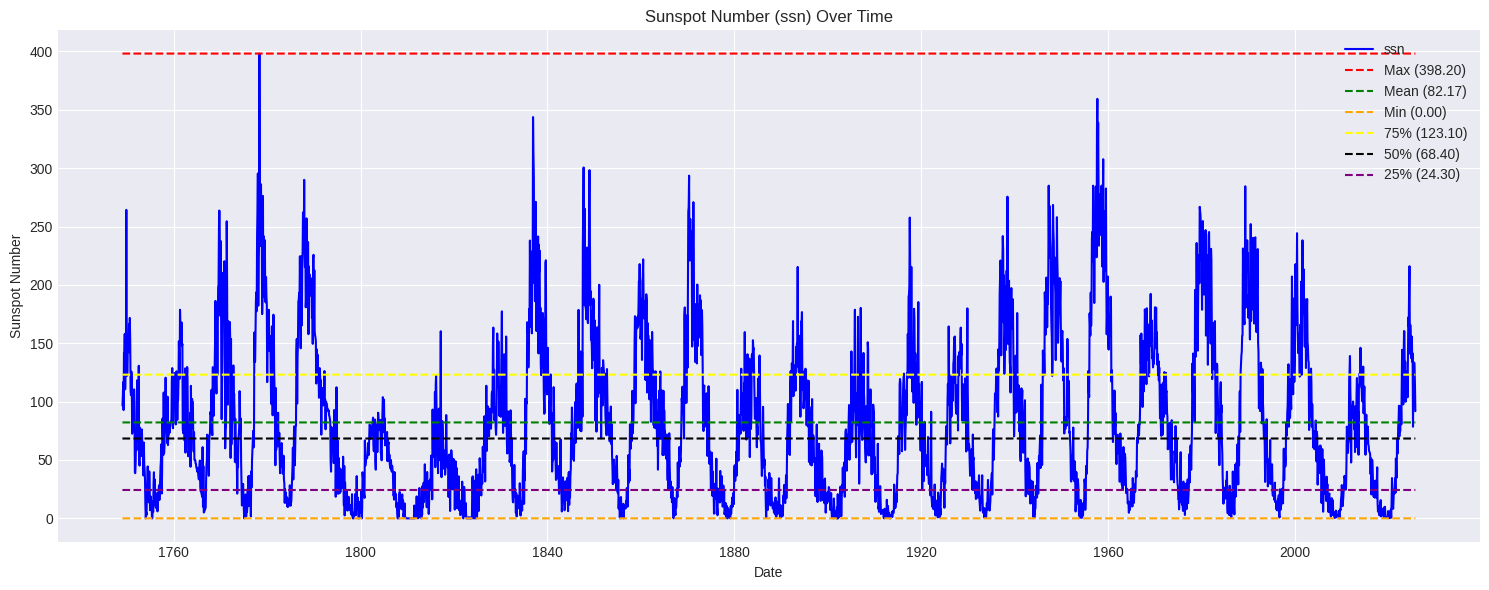

In [ ]:
# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create the figure
plt.figure(figsize=(15, 6))

timings = pd.to_datetime(solar_cycle_data['time-tag'])
calculate_data_statistics = solar_cycle_data['ssn'].describe()

# Create series for max, mean, and min with same length as original data
max_line = pd.Series([calculate_data_statistics['max']] * len(solar_cycle_data), index=solar_cycle_data.index)
mean_line = pd.Series([calculate_data_statistics['mean']] * len(solar_cycle_data), index=solar_cycle_data.index)
min_line = pd.Series([calculate_data_statistics['min']] * len(solar_cycle_data), index=solar_cycle_data.index)
third_quart_line = pd.Series([calculate_data_statistics['75%']] * len(solar_cycle_data), index=solar_cycle_data.index)
second_quart_line = pd.Series([calculate_data_statistics['50%']] * len(solar_cycle_data), index=solar_cycle_data.index)
first_quart_line = pd.Series([calculate_data_statistics['25%']] * len(solar_cycle_data), index=solar_cycle_data.index)

# Plot ssn over time
plt.plot(timings, solar_cycle_data['ssn'], color='blue', label='ssn')

# Plot the statistical lines
plt.plot(timings, max_line, color='red', linestyle='--', label=f'Max ({calculate_data_statistics["max"]:.2f})')
plt.plot(timings, mean_line, color='green', linestyle='--', label=f'Mean ({calculate_data_statistics["mean"]:.2f})')
plt.plot(timings, min_line, color='orange', linestyle='--', label=f'Min ({calculate_data_statistics["min"]:.2f})')
plt.plot(timings, third_quart_line, color='yellow', linestyle='--', label=f'75% ({calculate_data_statistics["75%"]:.2f})')
plt.plot(timings, second_quart_line, color='black', linestyle='--', label=f'50% ({calculate_data_statistics["50%"]:.2f})')
plt.plot(timings, first_quart_line, color='purple', linestyle='--', label=f'25% ({calculate_data_statistics["25%"]:.2f})')

# Labels and title
plt.title('Sunspot Number (ssn) Over Time')
plt.xlabel('Date')
plt.ylabel('Sunspot Number')
plt.legend(loc='upper right')
plt.grid(True)

# Display the plot
plt.tight_layout()
plt.show()

### What does thie data mean?

---

1. `Seasonality`

We can clearly see seasonality in the number of sun sports over the years. The peaks may sometimes go higher, however, the numbers always go near-zero or zero (as you cannot have a sun spot observation below it).

2. `Trends`

There doesn't seem to be a notable upwards or downwards trend in the data. However, we will perform a more thorough analysis later down to verify this visual.

3. `Mean, Max, Min`

The three statistics do not really give us a good understanding of the data. The data is seasonal and hence a global statistic will not help us understand anything.

---

We see that there are a couple of things to fix up to better see the plots.

1. To better see the plot, lets put it on a smaller same scale. Lets start the graph in 1997. Lets do this for both `ssn` and `observed_swpc_ssn` to see the graphs one top another.

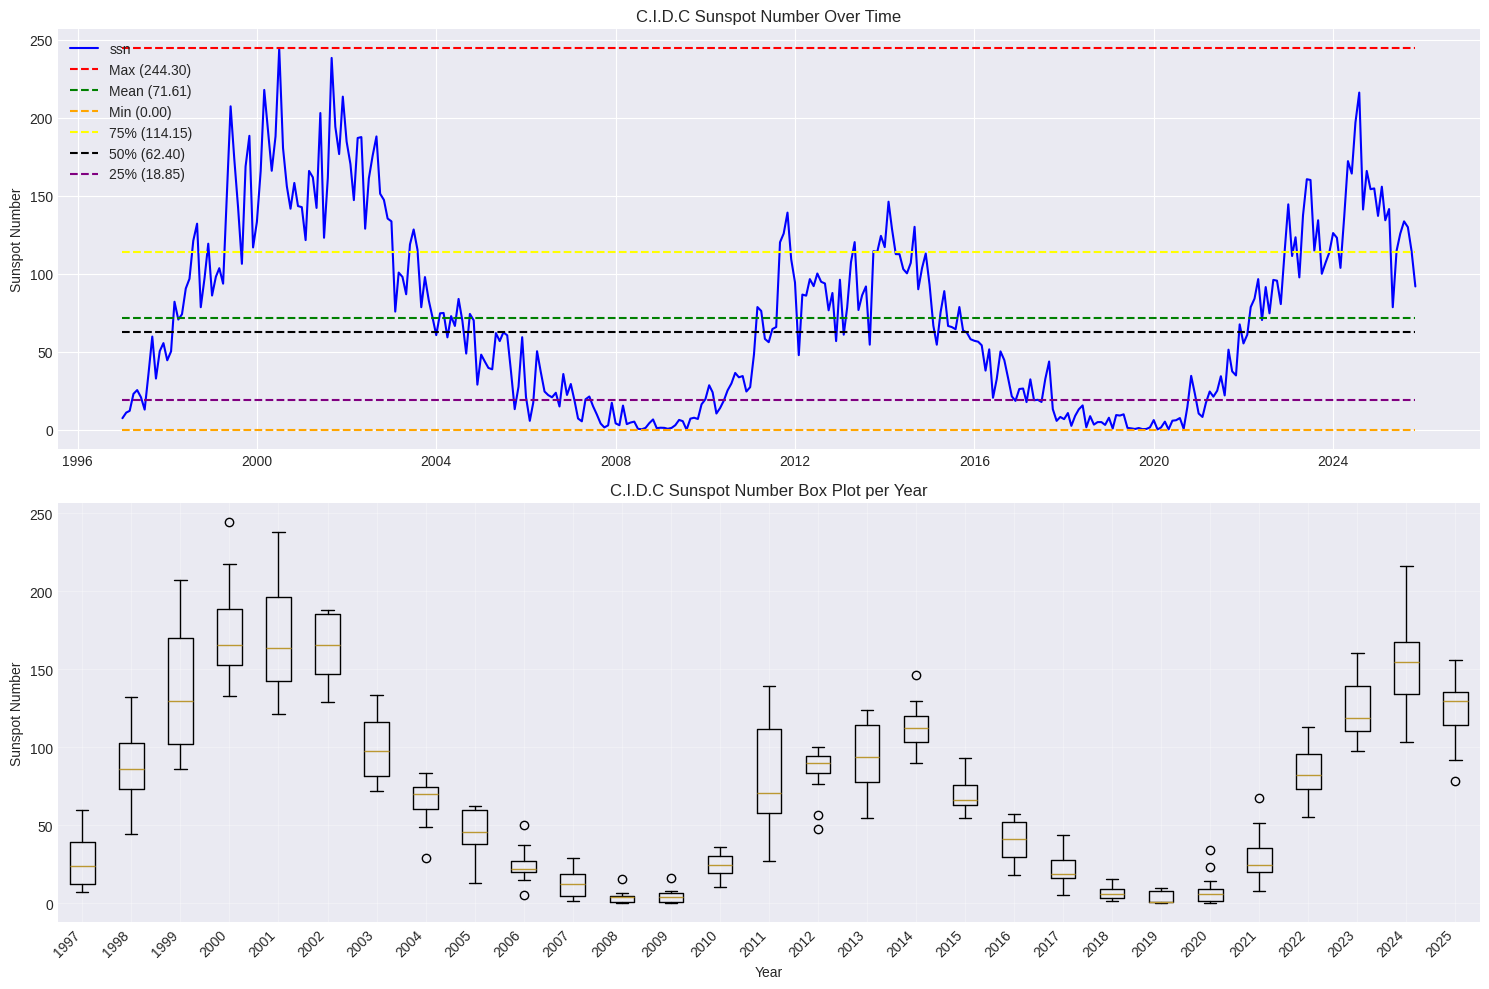

In [ ]:
# CLAIDE Plotting:
# I need to add another plot in ax4. This plot should be a box plot of the 'ssn' per year (use the cidc_ssn dataframe created below).
# Basically, get all the ssn values for each year (e.g, 1997, 1998, so on), for the box plot, get the unique years from the 'time-tag' column and populate the x-tick values in the boxplot.

cidc_ssn = solar_cycle_data.copy().drop(columns=['smoothed_ssn', 'observed_swpc_ssn', 'smoothed_swpc_ssn', 'f10.7', 'smoothed_f10.7'])

# For cidc
# Take away cidc's data until January 1997
cidc_ssn.drop(cidc_ssn.loc[cidc_ssn['time-tag'] < "1997-01"].index, inplace=True, axis=0)
cidc_statistics = cidc_ssn['ssn'].describe()
cidc_max_line = pd.Series([cidc_statistics['max']] * len(cidc_ssn), index=cidc_ssn.index)
cidc_mean_line = pd.Series([cidc_statistics['mean']] * len(cidc_ssn), index=cidc_ssn.index)
cidc_min_line = pd.Series([cidc_statistics['min']] * len(cidc_ssn), index=cidc_ssn.index)
cidc_third_quart_line = pd.Series([cidc_statistics['75%']] * len(cidc_ssn), index=cidc_ssn.index)
cidc_second_quart_line = pd.Series([cidc_statistics['50%']] * len(cidc_ssn), index=cidc_ssn.index)
cidc_first_quart_line = pd.Series([cidc_statistics['25%']] * len(cidc_ssn), index=cidc_ssn.index)
cidc_ssn['time-tag'] = pd.to_datetime(cidc_ssn['time-tag'])

# Extract year from time-tag for grouping
cidc_ssn['year'] = cidc_ssn['time-tag'].dt.year

# Prepare data for box plot: group ssn values by year
years = cidc_ssn['year'].unique()
years.sort()
ssn_by_year = [cidc_ssn.loc[cidc_ssn['year'] == year, 'ssn'].values for year in years]

# create the figure and its axes
fig2, (ax3, ax4) = plt.subplots(2, 1, sharex=False, figsize=(15, 10))

# Top subplot: ssn
ax3.plot(cidc_ssn['time-tag'], cidc_ssn['ssn'], color='blue', label='ssn')
ax3.plot(cidc_ssn['time-tag'], cidc_max_line, color='red', linestyle='--', label=f'Max ({cidc_statistics["max"]:.2f})')
ax3.plot(cidc_ssn['time-tag'], cidc_mean_line, color='green', linestyle='--', label=f'Mean ({cidc_statistics["mean"]:.2f})')
ax3.plot(cidc_ssn['time-tag'], cidc_min_line, color='orange', linestyle='--', label=f'Min ({cidc_statistics["min"]:.2f})')
ax3.plot(cidc_ssn['time-tag'], cidc_third_quart_line, color='yellow', linestyle='--', label=f'75% ({cidc_statistics["75%"]:.2f})')
ax3.plot(cidc_ssn['time-tag'], cidc_second_quart_line, color='black', linestyle='--', label=f'50% ({cidc_statistics["50%"]:.2f})')
ax3.plot(cidc_ssn['time-tag'], cidc_first_quart_line, color='purple', linestyle='--', label=f'25% ({cidc_statistics["25%"]:.2f})')
ax3.set_title('C.I.D.C Sunspot Number Over Time')
ax3.set_ylabel('Sunspot Number')
ax3.legend()
ax3.grid(True)

# Bottom subplot: box plot of ssn per year
ax4.boxplot(ssn_by_year, tick_labels=years)
ax4.set_title('C.I.D.C Sunspot Number Box Plot per Year')
ax4.set_xlabel('Year')
ax4.set_ylabel('Sunspot Number')
ax4.grid(True, alpha=0.3)
# Rotate x-axis labels for better readability
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

Lets see the rest of the years.

---



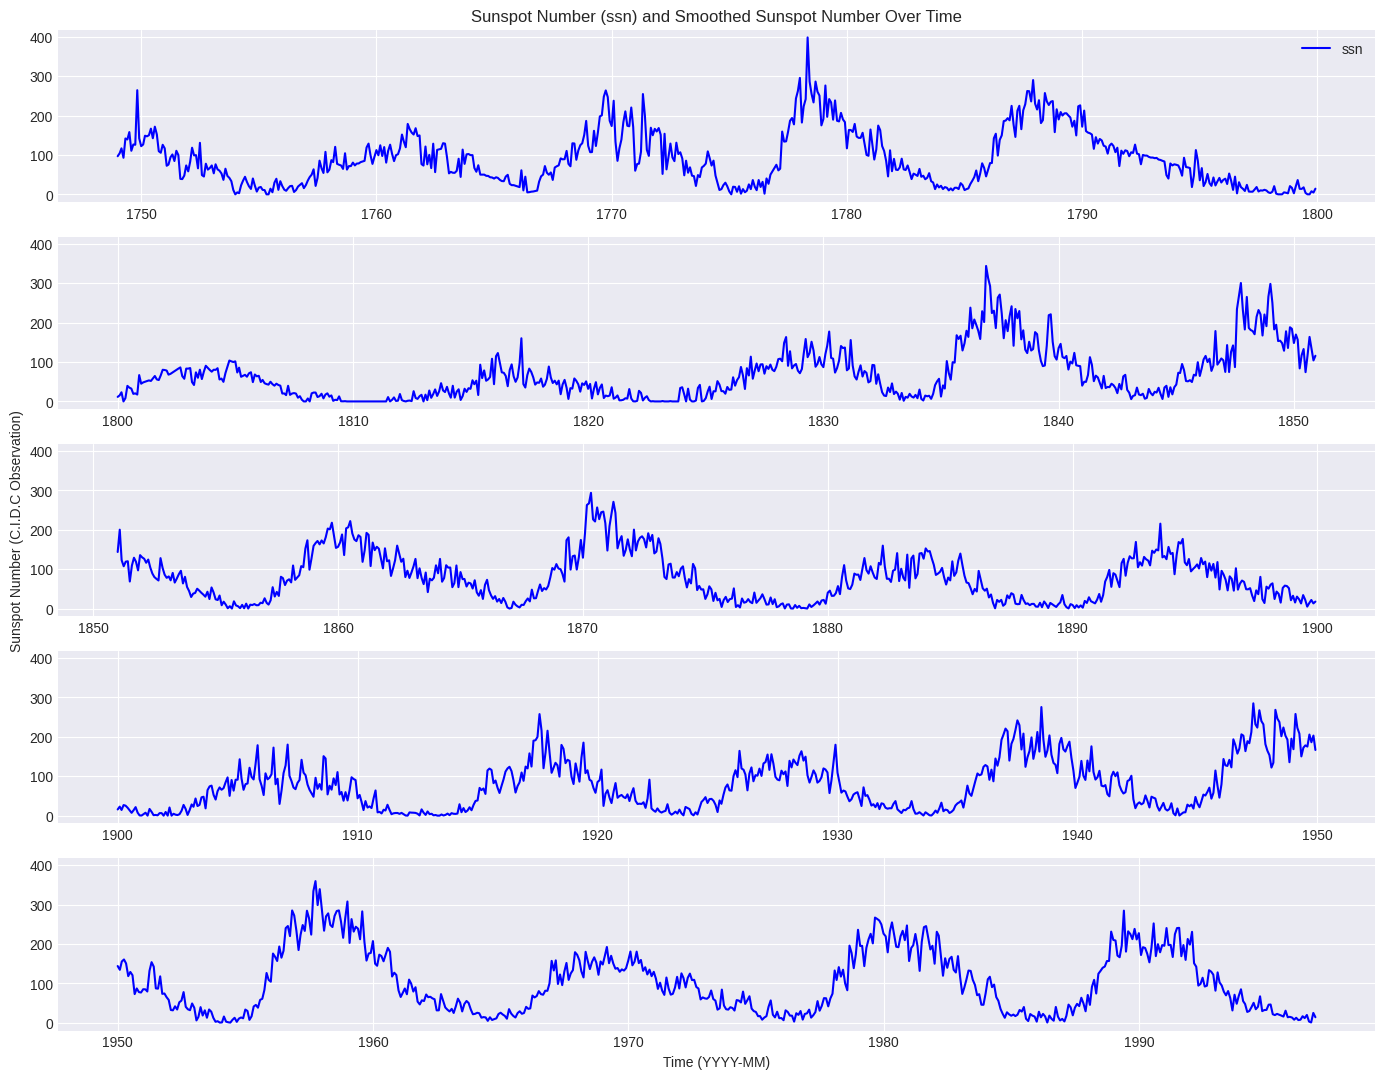

In [ ]:
ssn_1700s = solar_cycle_data.copy().loc[solar_cycle_data['time-tag'] < "1800-01", ['time-tag', 'ssn']]
ssn_1800_to_1850 = solar_cycle_data.copy().loc[(solar_cycle_data['time-tag'] >= "1800-01") & (solar_cycle_data['time-tag'] < "1851-01") , ['time-tag', 'ssn']]
ssn_1850_to_1900 = solar_cycle_data.copy().loc[(solar_cycle_data['time-tag'] >= "1851-01") & (solar_cycle_data['time-tag'] < "1900-01") , ['time-tag', 'ssn']]
ssn_1900_to_1950 = solar_cycle_data.copy().loc[(solar_cycle_data['time-tag'] >= "1900-01") & (solar_cycle_data['time-tag'] < "1950-01") , ['time-tag', 'ssn']]
ssn_1950_to_1997 = solar_cycle_data.copy().loc[(solar_cycle_data['time-tag'] >= "1950-01") & (solar_cycle_data['time-tag'] < "1997-01") , ['time-tag', 'ssn']]

# create the figure and its axes
fig3, (ax5, ax6, ax7, ax8, ax9) = plt.subplots(5, 1, sharey=True, figsize=(17, 13))

# 1700s plot
ssn_1700s['time-tag'] = pd.to_datetime(ssn_1700s['time-tag'])
ax5.plot(ssn_1700s['time-tag'], ssn_1700s['ssn'], color='blue', label='ssn')
ax5.set_title('Sunspot Number (ssn) and Smoothed Sunspot Number Over Time')
ax5.legend()
ax5.grid(True)

# 1800-1850 plot
ssn_1800_to_1850['time-tag'] = pd.to_datetime(ssn_1800_to_1850['time-tag'])
ax6.plot(ssn_1800_to_1850['time-tag'], ssn_1800_to_1850['ssn'], color='blue', label='ssn')
ax6.grid(True)

# 1850-1900 plot
ssn_1850_to_1900['time-tag'] = pd.to_datetime(ssn_1850_to_1900['time-tag'])
ax7.plot(ssn_1850_to_1900['time-tag'], ssn_1850_to_1900['ssn'], color='blue', label='ssn')
ax7.set_ylabel('Sunspot Number (C.I.D.C Observation)')
ax7.grid(True)

# 1900-1950 plot
ssn_1900_to_1950['time-tag'] = pd.to_datetime(ssn_1900_to_1950['time-tag'])
ax8.plot(ssn_1900_to_1950['time-tag'], ssn_1900_to_1950['ssn'], color='blue', label='ssn')
ax8.grid(True)

# 1950-1997 plot
ssn_1950_to_1997['time-tag'] = pd.to_datetime(ssn_1950_to_1997['time-tag'])
ax9.plot(ssn_1950_to_1997['time-tag'], ssn_1950_to_1997['ssn'], color='blue', label='ssn')
ax9.set_xlabel('Time (YYYY-MM)')
ax9.grid(True)

### What does the data say?
---

Over the years, we see that the general trend is such that the rise to the peak is quick compared to the fall to the bottom.

---

**Now that we have seen all the cycles. Lets graph the last 4 of cycles on the same axes to see how over the 11 years the number of sunspots change.**

**Additionally, since we have data monthly, lets analyse if the specific month has had differences as well on the number of sunspots. This is because it could be that because of the tilt of the earth and how far/close it is in the cycle, we may observe more sunspots specifically because the observatories are in the northern hemisphere.**

---

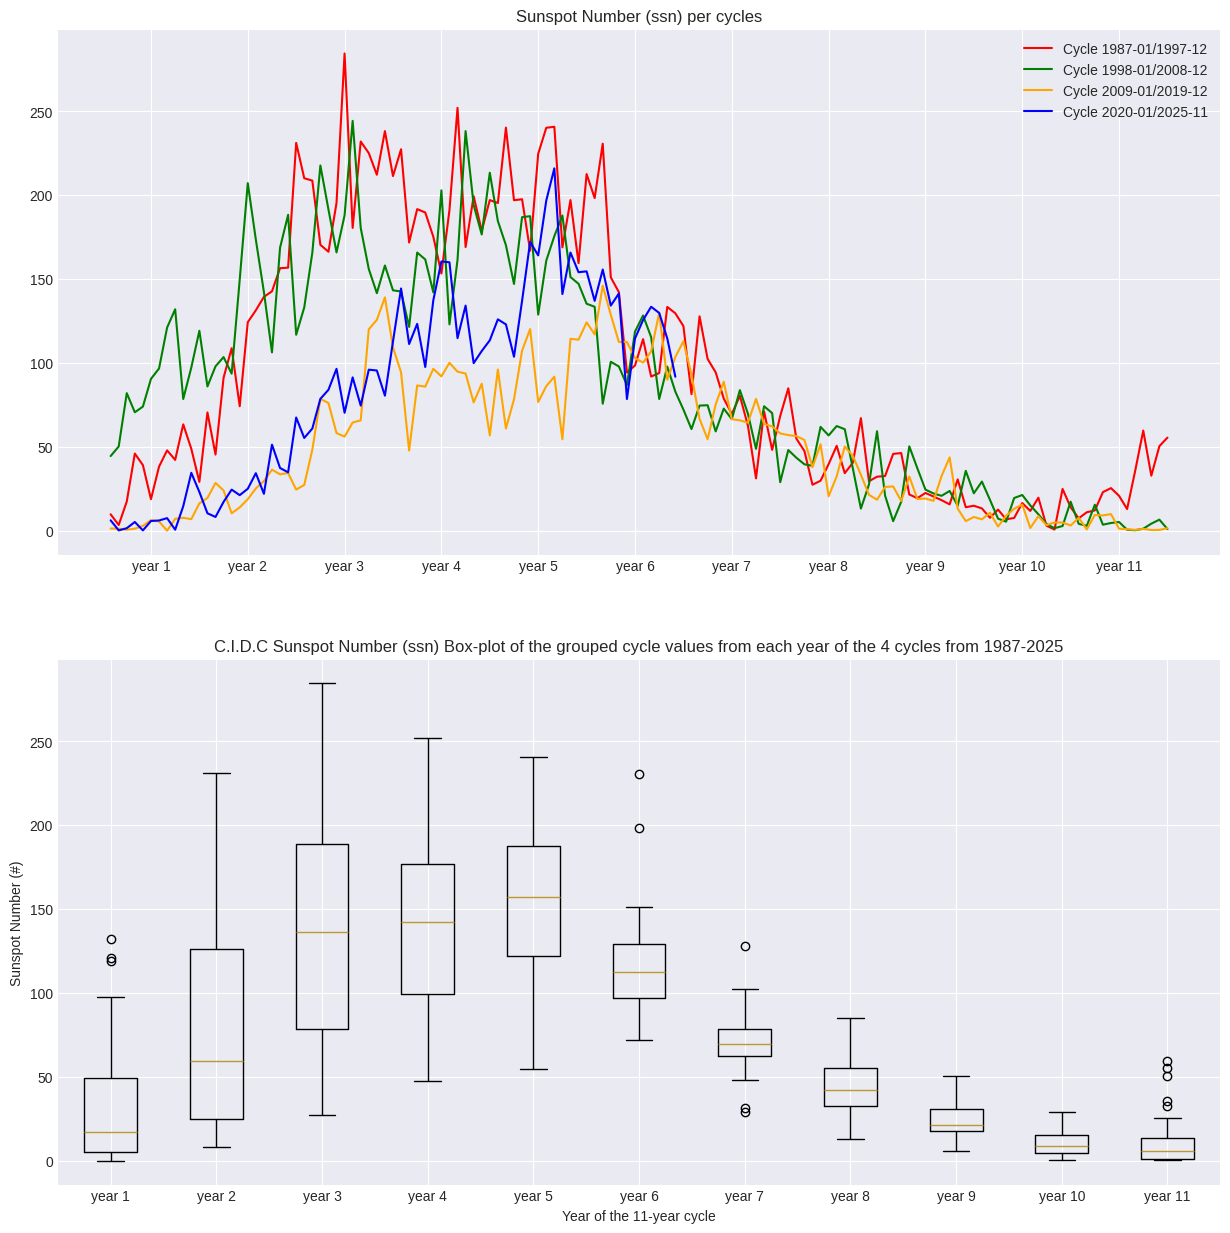

In [ ]:
cycle_1986_1996 = solar_cycle_data.copy().loc[(solar_cycle_data['time-tag'] >= "1987-01") & (solar_cycle_data['time-tag'] <= "1997-12"), 'ssn'].reset_index(drop=True)
cycle_1997_2008 = solar_cycle_data.copy().loc[(solar_cycle_data['time-tag'] >= "1998-01") & (solar_cycle_data['time-tag'] <= "2008-12"), 'ssn'].reset_index(drop=True)
cycle_2009_2019 = solar_cycle_data.copy().loc[(solar_cycle_data['time-tag'] >= "2009-01") & (solar_cycle_data['time-tag'] <= "2019-12"), 'ssn'].reset_index(drop=True)
cycle_2020_2025 = solar_cycle_data.copy().loc[(solar_cycle_data['time-tag'] >= "2020-01") & (solar_cycle_data['time-tag'] <= "2025-11"), 'ssn'].reset_index(drop=True)

# get indexes
all_indexes_per_2020, all_indexes_post_2020 = list(cycle_1986_1996.index), list(cycle_2020_2025.index)
pre_2020_xticks, index_pre_2020 = [("year " + str(i)) for i in range(1, 12)], [i for i in range(5, len(all_indexes_per_2020), 12)]

# Breakdown the cycles into each cycle's values per year:
all_years_data = []
for i in range(0, len(cycle_1986_1996), 12):
  i_added = 12
  if i > 48:
    all_years_data.append(pd.concat([cycle_1986_1996.iloc[i:i+i_added], cycle_1997_2008.iloc[i:i+i_added], cycle_2009_2019.iloc[i:i+i_added]]))
  elif i <= 48:
    all_years_data.append(pd.concat([cycle_1986_1996.iloc[i:i+i_added], cycle_1997_2008.iloc[i:i+i_added], cycle_2009_2019.iloc[i:i+i_added], cycle_2020_2025.iloc[i:i+i_added]]))

# Make axes
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(15, 15))

# Plot the line graph of sunspot numbers
ax.plot(all_indexes_per_2020, cycle_1986_1996, color='red', label='Cycle 1987-01/1997-12')
ax.plot(all_indexes_per_2020, cycle_1997_2008, color='green', label='Cycle 1998-01/2008-12')
ax.plot(all_indexes_per_2020, cycle_2009_2019, color='orange', label='Cycle 2009-01/2019-12')
ax.plot(all_indexes_post_2020, cycle_2020_2025, color='blue', label='Cycle 2020-01/2025-11')
ax.set_title('Sunspot Number (ssn) per cycles')
ax.set_xticks(index_pre_2020, pre_2020_xticks)
ax.legend()

# Plot the box plot of each year:
ax2.set_title('C.I.D.C Sunspot Number (ssn) Box-plot of the grouped cycle values from each year of the 4 cycles from 1987-2025')
ax2.set_ylabel('Sunspot Number (#)')
ax2.set_xlabel('Year of the 11-year cycle')
bp = ax2.boxplot(all_years_data, tick_labels=pre_2020_xticks)

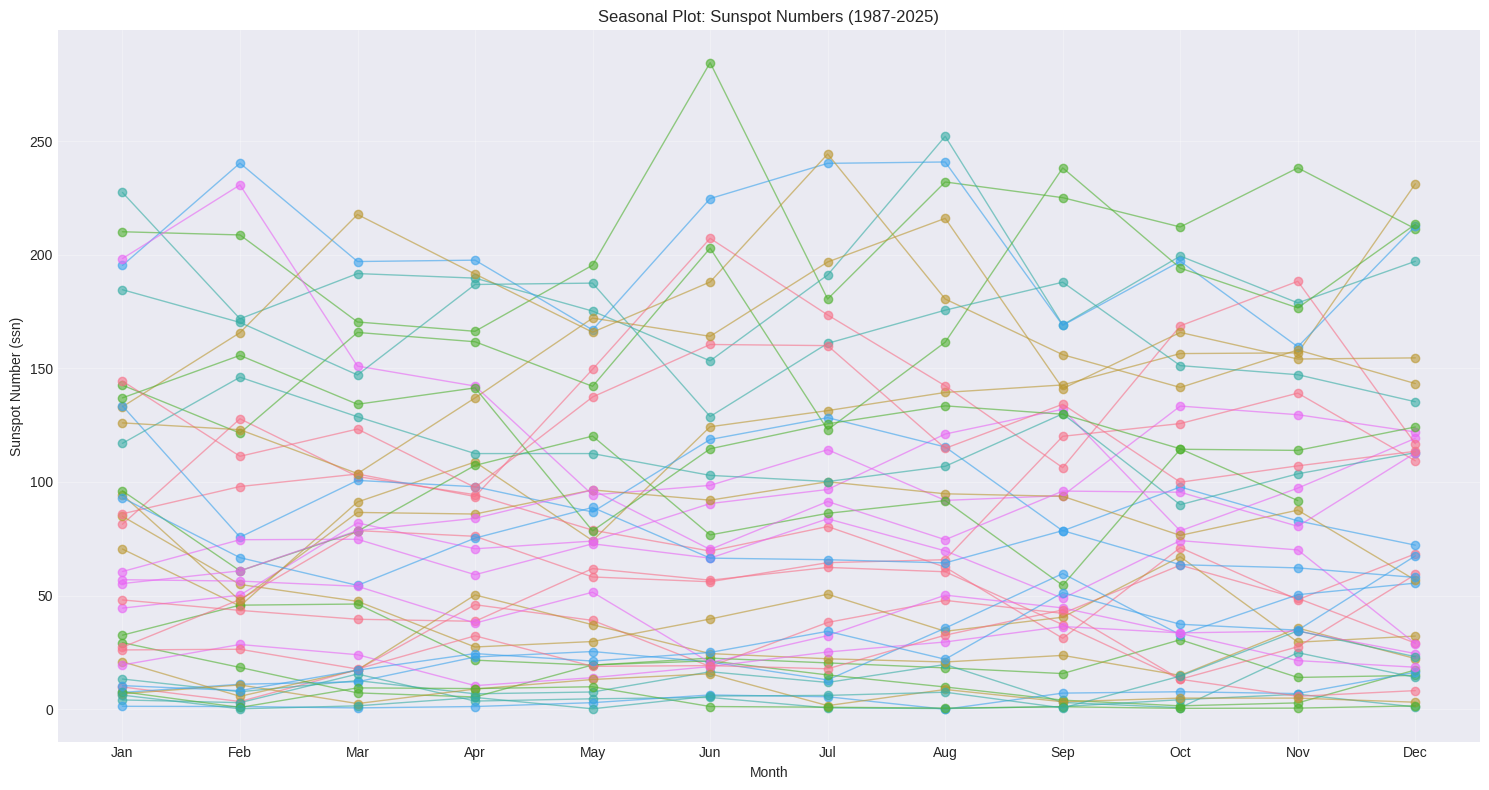

In [ ]:
# Seasonal time-plot: Sunspot numbers by month across cycles
# Combine the 4 cycles into a single DataFrame with proper date formatting
cycle_data_list = []

# Cycle 1: 1987-01 to 1997-12
cycle1 = solar_cycle_data.copy().loc[(solar_cycle_data['time-tag'] >= "1987-01") & (solar_cycle_data['time-tag'] <= "1997-12")].copy()
cycle1['time-tag'] = pd.to_datetime(cycle1['time-tag'])
cycle1['year'] = cycle1['time-tag'].dt.year
cycle1['month'] = cycle1['time-tag'].dt.month
cycle_data_list.append(cycle1[['time-tag', 'year', 'month', 'ssn']])

# Cycle 2: 1998-01 to 2008-12
cycle2 = solar_cycle_data.copy().loc[(solar_cycle_data['time-tag'] >= "1998-01") & (solar_cycle_data['time-tag'] <= "2008-12")].copy()
cycle2['time-tag'] = pd.to_datetime(cycle2['time-tag'])
cycle2['year'] = cycle2['time-tag'].dt.year
cycle2['month'] = cycle2['time-tag'].dt.month
cycle_data_list.append(cycle2[['time-tag', 'year', 'month', 'ssn']])

# Cycle 3: 2009-01 to 2019-12
cycle3 = solar_cycle_data.copy().loc[(solar_cycle_data['time-tag'] >= "2009-01") & (solar_cycle_data['time-tag'] <= "2019-12")].copy()
cycle3['time-tag'] = pd.to_datetime(cycle3['time-tag'])
cycle3['year'] = cycle3['time-tag'].dt.year
cycle3['month'] = cycle3['time-tag'].dt.month
cycle_data_list.append(cycle3[['time-tag', 'year', 'month', 'ssn']])

# Cycle 4: 2020-01 to 2025-11
cycle4 = solar_cycle_data.copy().loc[(solar_cycle_data['time-tag'] >= "2020-01") & (solar_cycle_data['time-tag'] <= "2025-11")].copy()
cycle4['time-tag'] = pd.to_datetime(cycle4['time-tag'])
cycle4['year'] = cycle4['time-tag'].dt.year
cycle4['month'] = cycle4['time-tag'].dt.month
cycle_data_list.append(cycle4[['time-tag', 'year', 'month', 'ssn']])

# Combine all cycles
combined_cycles = pd.concat(cycle_data_list, ignore_index=True)

# Create seasonal plot
plt.figure(figsize=(15, 8))
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Plot each year with a different color/transparency
for year in combined_cycles['year'].unique():
    year_data = combined_cycles[combined_cycles['year'] == year]
    plt.plot(year_data['month'], year_data['ssn'], marker='o', alpha=0.6, linewidth=1)

plt.xlabel('Month')
plt.ylabel('Sunspot Number (ssn)')
plt.title('Seasonal Plot: Sunspot Numbers (1987-2025)')
plt.xticks(range(1, 13), month_names)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What does the seasonal time-plot say?
---

1. **No Monthly Seasonality**

There is basically no difference between each month as the cycle changes and the peaks/valleys occur - the sunspot numbers follow the 11-year solar cycle regardless of the month. All months show similar patterns of rise and fall in sunspot activity.

2. **Earth's Orbital Position Has No Effect**

This means that the Earth being closer to the Sun during summer months in the northern hemisphere has no changes in the number of observed sunspots. The distance variation between Earth and Sun due to orbital position does not affect sunspot observations, confirming that sunspot activity is driven by the Sun's internal magnetic cycle rather than Earth's position or seasonal changes.

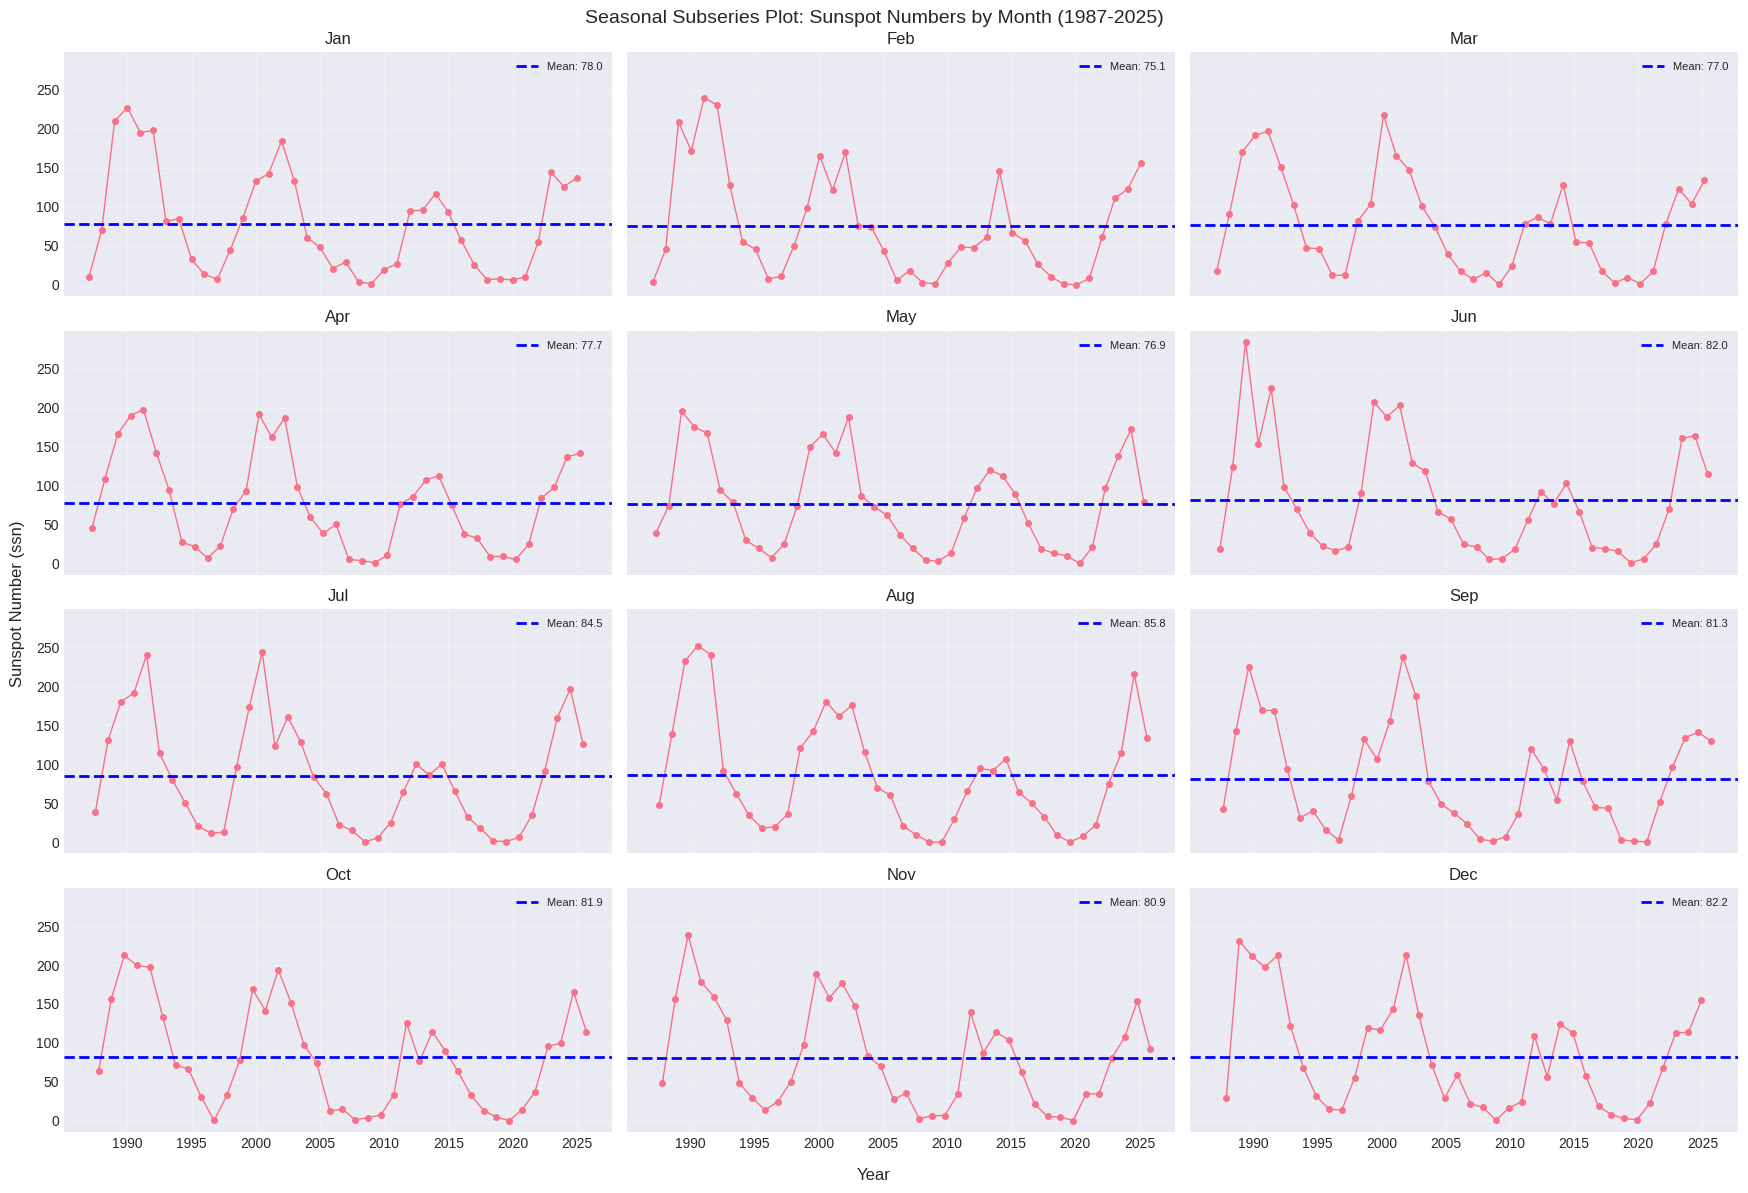

In [ ]:
# Seasonal subseries plot: Sunspot numbers
# This plot shows data for each month separately with mean lines
fig, axes = plt.subplots(4, 3, figsize=(18, 12), sharex=True, sharey=True)
axes = axes.flatten()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for i, month in enumerate(range(1, 13)):
    month_data = combined_cycles[combined_cycles['month'] == month].copy()
    month_data = month_data.sort_values('time-tag')

    # Plot the time series for this month
    axes[i].plot(month_data['time-tag'], month_data['ssn'], marker='o', linestyle='-', linewidth=1, markersize=4)

    # Add horizontal line for mean
    mean_val = month_data['ssn'].mean()
    axes[i].axhline(y=mean_val, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')

    # Set title and labels
    axes[i].set_title(month_names[i])
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(loc='upper right', fontsize=8)

# Set common labels
fig.text(0.5, 0.02, 'Year', ha='center', fontsize=12)
fig.text(0.02, 0.5, 'Sunspot Number (ssn)', va='center', rotation='vertical', fontsize=12)
fig.suptitle('Seasonal Subseries Plot: Sunspot Numbers by Month (1987-2025)', fontsize=14, y=0.995)

plt.tight_layout()
plt.subplots_adjust(left=0.05, right=0.98, top=0.96, bottom=0.06)
plt.show()

### What does the seasonal subseries plot say?
---

1. **Months Follow the Solar Cycle**

Throughout all the months, we see that the sunspot numbers follow the 11-year solar cycle. The months actually do not show any new detail or unique seasonal patterns. The solar cycle is visible through all months, but what really matters are the years within the cycle rather than the specific months. Each month's subplot shows the same underlying cyclical pattern, confirming that monthly variations are negligible compared to the multi-year solar cycle.

## 2.3 Statistical Analysis:
---

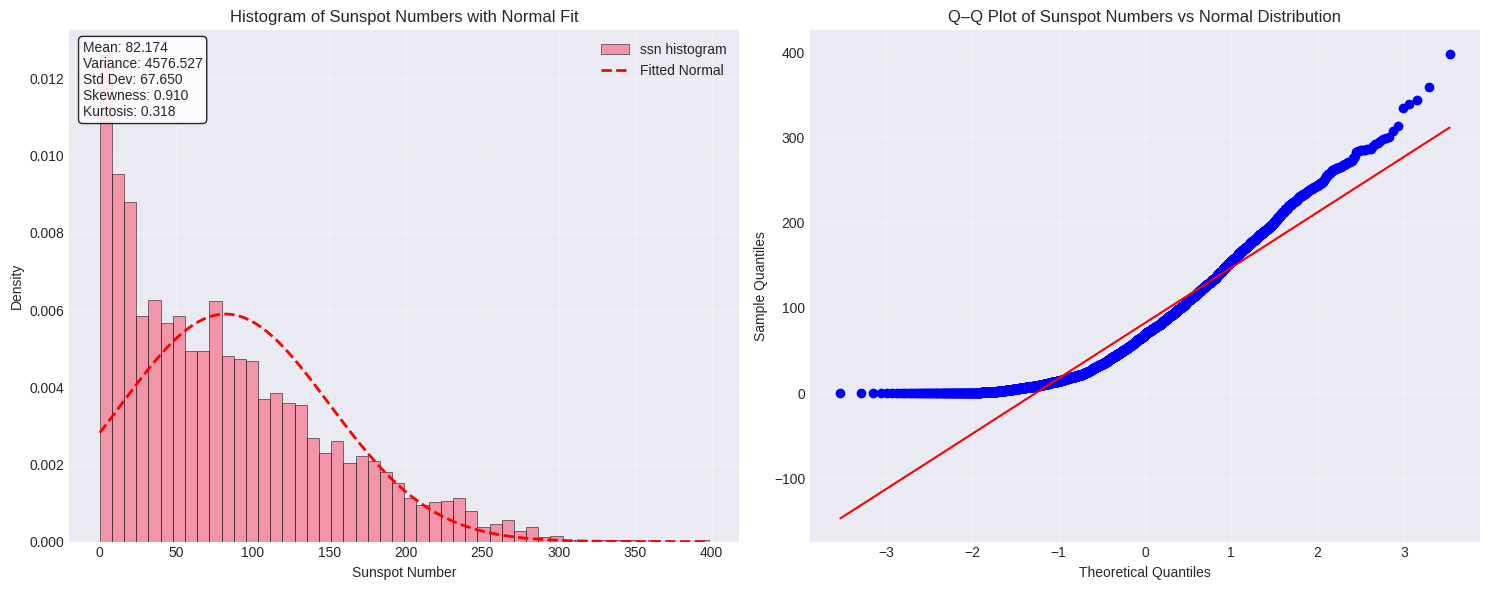

In [ ]:
# Extract series and drop missing
ssn = solar_cycle_data['ssn'].dropna()

# Compute moments
mean_ssn = ssn.mean()
var_ssn = ssn.var()
std_ssn = ssn.std()
skew_ssn = stats.skew(ssn)
kurt_ssn = stats.kurtosis(ssn)  # excess kurtosis (0 = normal)

# --------------------------------------
# Plot: Histogram + Fitted Normal + QQ
# --------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ---------------------------
# 1. Histogram + Normal Fit
# ---------------------------
ax1.hist(ssn, bins=50, density=True, alpha=0.7,
         edgecolor='black', linewidth=0.5, label='ssn histogram')

# Normal distribution with same mean & std
x = np.linspace(ssn.min(), ssn.max(), 500)
normal_pdf = stats.norm.pdf(x, loc=mean_ssn, scale=std_ssn)
ax1.plot(x, normal_pdf, 'r--', linewidth=2, label='Fitted Normal')
ax1.set_title('Histogram of Sunspot Numbers with Normal Fit')
ax1.set_xlabel('Sunspot Number')
ax1.set_ylabel('Density')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add moments text box
stats_text = (
    f"Mean: {mean_ssn:.3f}\n"
    f"Variance: {var_ssn:.3f}\n"
    f"Std Dev: {std_ssn:.3f}\n"
    f"Skewness: {skew_ssn:.3f}\n"
    f"Kurtosis: {kurt_ssn:.3f}"
)
ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

# ---------------------------
# 2. Q–Q Plot
# ---------------------------
stats.probplot(ssn, dist="norm", plot=ax2)
ax2.set_title("Q–Q Plot of Sunspot Numbers vs Normal Distribution")
ax2.set_xlabel("Theoretical Quantiles")
ax2.set_ylabel("Sample Quantiles")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### What does the data say?
---
1. Moment 1: `Mean`

The mean is roughly around 82 ssn which means. The histogram of all values sits at around

2. Moment 2: `Variance`

There is a large standard deviation and variance caused by the very large amount of 0 values and the extreme positive values around the high solar activity timings (eg. 400 ssn).

3. Moment 3: `Skewness`

We definietly see a right-skew because of the large amount of zero values, hence why the skewness is positive.

4. Moment 4: `Kurtosis`

We see that it is positive, meaning that there are some extreme values from the norm (eg. 400 ssn compared to the rather >100 ssn) and it has a peakness to it near the 0 value.


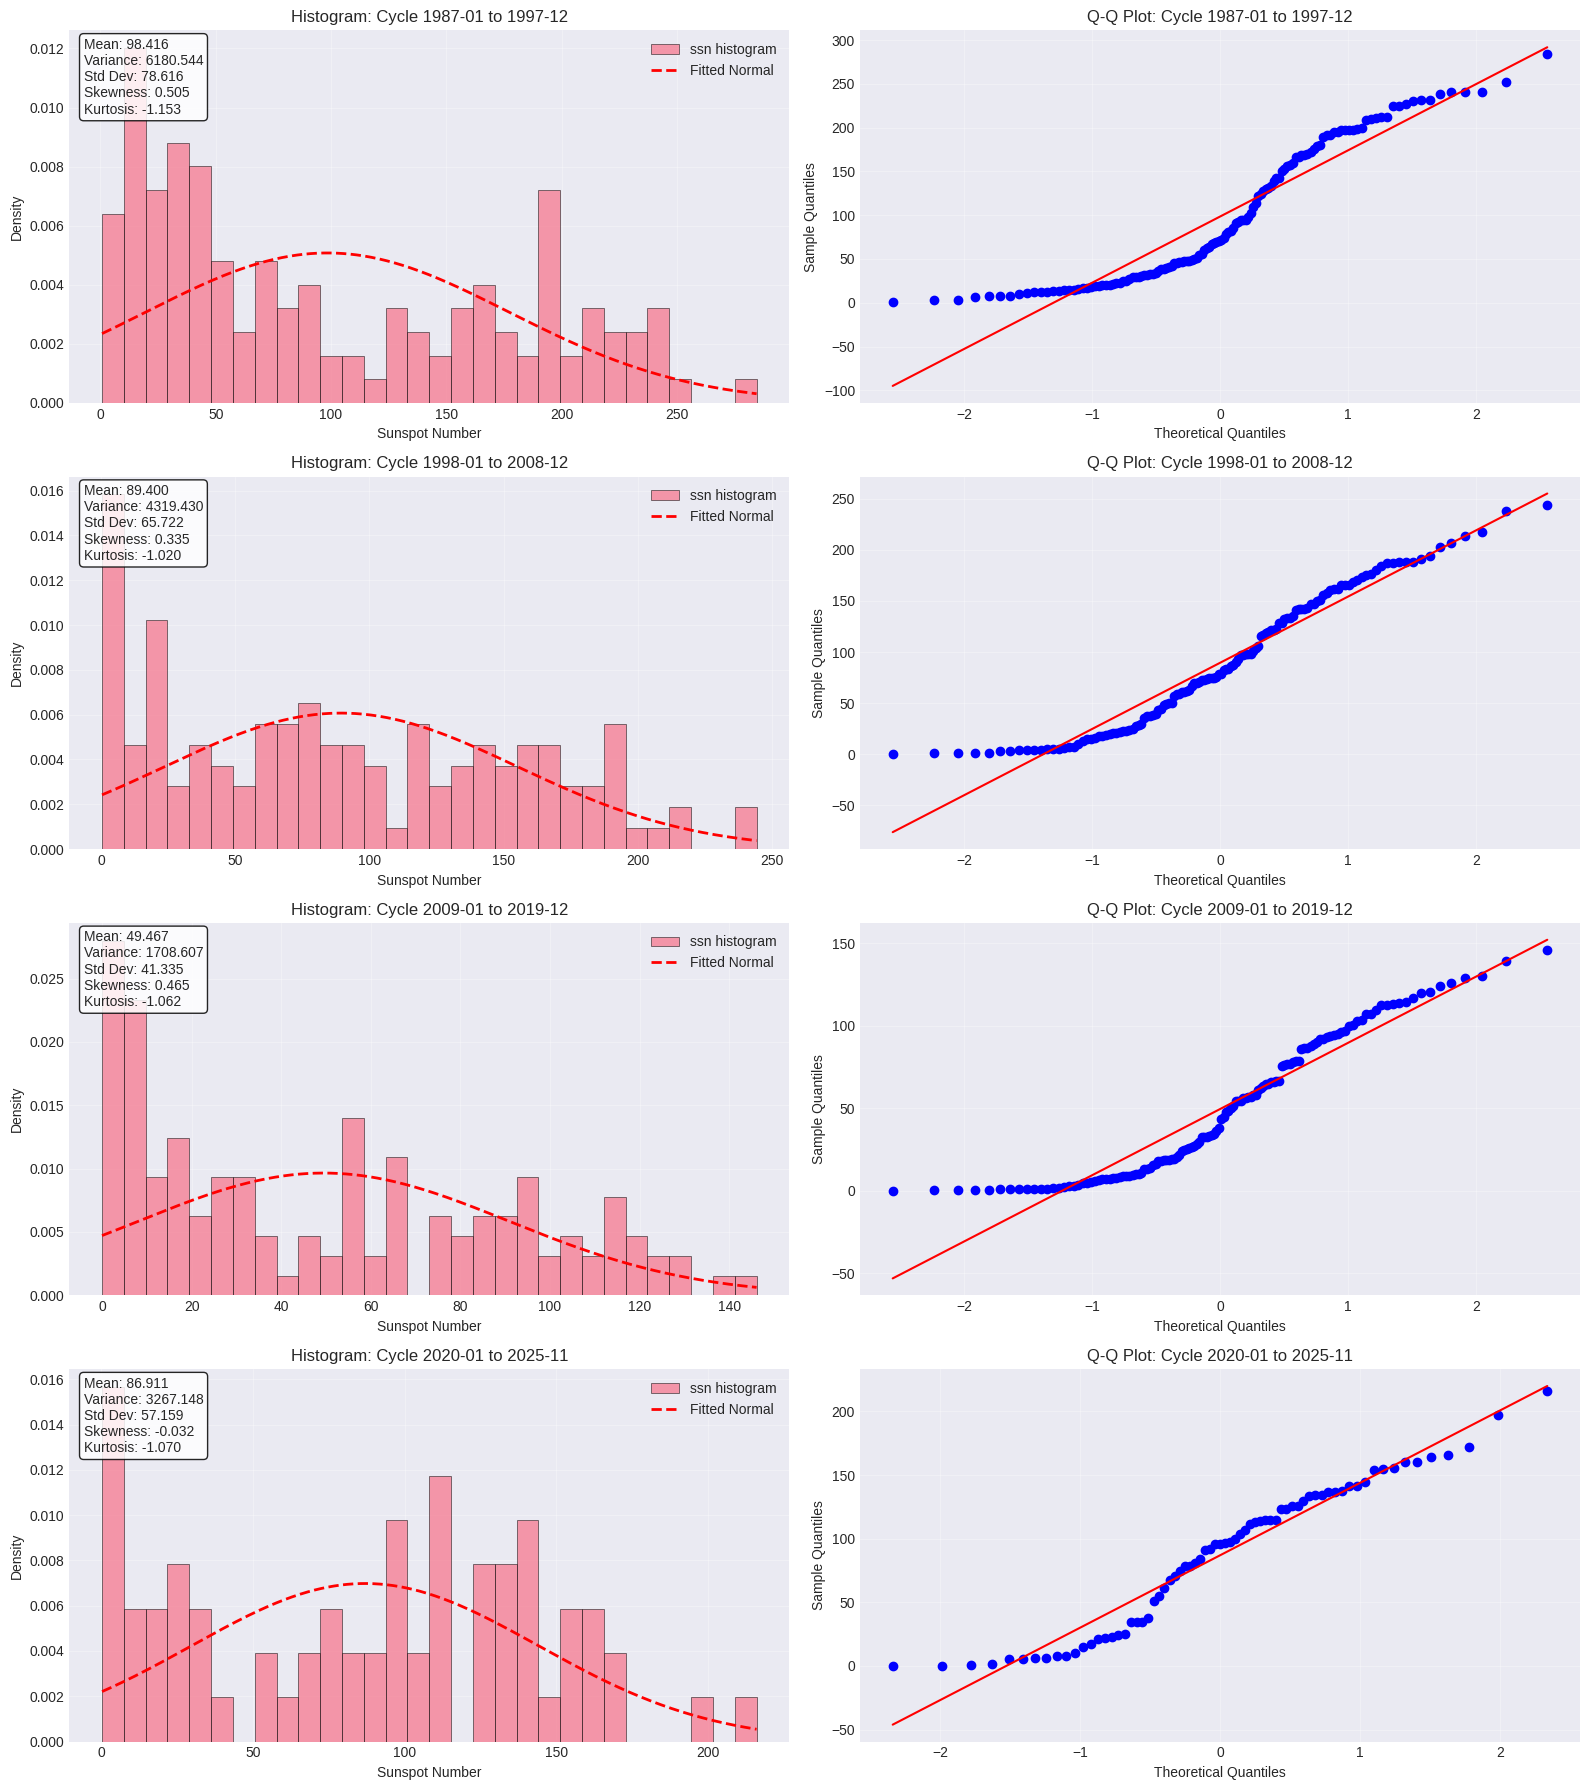

In [ ]:
# Histogram and QQ-plot for the last 4 cycles
# Each row represents one cycle with histogram and QQ-plot side by side

cycles = [
    (cycle_1986_1996, '1987-01 to 1997-12'),
    (cycle_1997_2008, '1998-01 to 2008-12'),
    (cycle_2009_2019, '2009-01 to 2019-12'),
    (cycle_2020_2025, '2020-01 to 2025-11')
]

# Create figure with 4 rows and 2 columns
fig, axes = plt.subplots(4, 2, figsize=(16, 18))

for i, (cycle_data, cycle_label) in enumerate(cycles):
    # Calculate statistics
    mean_cycle = cycle_data.mean()
    var_cycle = cycle_data.var()
    std_cycle = cycle_data.std()
    skew_cycle = stats.skew(cycle_data)
    kurt_cycle = stats.kurtosis(cycle_data)

    # Histogram with normal fit (left column)
    ax_hist = axes[i, 0]
    ax_hist.hist(cycle_data, bins=30, density=True, alpha=0.7,
                 edgecolor='black', linewidth=0.5, label='ssn histogram')

    # Fit normal distribution
    x = np.linspace(cycle_data.min(), cycle_data.max(), 500)
    normal_pdf = stats.norm.pdf(x, loc=mean_cycle, scale=std_cycle)
    ax_hist.plot(x, normal_pdf, 'r--', linewidth=2, label='Fitted Normal')
    ax_hist.set_title(f'Histogram: Cycle {cycle_label}')
    ax_hist.set_xlabel('Sunspot Number')
    ax_hist.set_ylabel('Density')
    ax_hist.legend()
    ax_hist.grid(True, alpha=0.3)

    # Add statistics text box
    stats_text = (
        f"Mean: {mean_cycle:.3f}\n"
        f"Variance: {var_cycle:.3f}\n"
        f"Std Dev: {std_cycle:.3f}\n"
        f"Skewness: {skew_cycle:.3f}\n"
        f"Kurtosis: {kurt_cycle:.3f}"
    )
    ax_hist.text(0.02, 0.98, stats_text, transform=ax_hist.transAxes,
                 verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

    # Q-Q plot (right column)
    ax_qq = axes[i, 1]
    stats.probplot(cycle_data, dist="norm", plot=ax_qq)
    ax_qq.set_title(f'Q-Q Plot: Cycle {cycle_label}')
    ax_qq.set_xlabel('Theoretical Quantiles')
    ax_qq.set_ylabel('Sample Quantiles')
    ax_qq.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate statistics for each cycle
stats_dict = {
    'Cycle 1987-1997': {
        'Mean': cycle_1986_1996.mean(),
        'Variance': cycle_1986_1996.var(),
        'Std Dev': cycle_1986_1996.std(),
        'Skewness': stats.skew(cycle_1986_1996),
        'Kurtosis': stats.kurtosis(cycle_1986_1996)
    },
    'Cycle 1998-2008': {
        'Mean': cycle_1997_2008.mean(),
        'Variance': cycle_1997_2008.var(),
        'Std Dev': cycle_1997_2008.std(),
        'Skewness': stats.skew(cycle_1997_2008),
        'Kurtosis': stats.kurtosis(cycle_1997_2008)
    },
    'Cycle 2009-2019': {
        'Mean': cycle_2009_2019.mean(),
        'Variance': cycle_2009_2019.var(),
        'Std Dev': cycle_2009_2019.std(),
        'Skewness': stats.skew(cycle_2009_2019),
        'Kurtosis': stats.kurtosis(cycle_2009_2019)
    },
    'Cycle 2020-2025': {
        'Mean': cycle_2020_2025.mean(),
        'Variance': cycle_2020_2025.var(),
        'Std Dev': cycle_2020_2025.std(),
        'Skewness': stats.skew(cycle_2020_2025),
        'Kurtosis': stats.kurtosis(cycle_2020_2025)
    },
    'Total SSN (All Data)': {
        'Mean': mean_ssn,
        'Variance': var_ssn,
        'Std Dev': std_ssn,
        'Skewness': skew_ssn,
        'Kurtosis': kurt_ssn
    }
}

# Create DataFrame from the dictionary
stats_comparison = pd.DataFrame(stats_dict).T

print("Statistical Comparison: Individual Cycles vs Total SSN")
print("=" * 80)
stats_comparison

Statistical Comparison: Individual Cycles vs Total SSN


,Mean,Variance,Std Dev,Skewness,Kurtosis
Cycle 1987-1997,98.415909,6180.543638,78.616434,0.504937,-1.153346
Cycle 1998-2008,89.400000,4319.430076,65.722371,0.334712,-1.019950
Cycle 2009-2019,49.466667,1708.607125,41.335301,0.465434,-1.061620
Cycle 2020-2025,86.911268,3267.147586,57.158968,-0.031702,-1.069919
Total SSN (All Data),82.174090,4576.527080,67.650034,0.909963,0.318297


### What does the cycle-by-cycle analysis say?
---

Looking at the statistical comparison table above, we can observe several key patterns when comparing individual cycles to the total SSN dataset:

1. **Similar Overall Patterns**

Cycle through cycle, we see similar statistical results in terms of mean values and general distribution characteristics. Each cycle maintains the characteristic patterns of solar activity with periods of high and low sunspot counts.

2. **Lower Skewness in Individual Cycles**

The skewness values for individual cycles are notably lower than the total dataset. This occurs because within a single cycle, the sunspot numbers are more spread out across the range rather than concentrated at zero. When looking at all data from 1749 onwards, the large number of zero-count periods across many cycles increases the right-skew of the total distribution.

3. **Negative Kurtosis in Individual Cycles**

The kurtosis values for individual cycles are negative, in contrast to the positive kurtosis of the total SSN dataset. This means:
   - Individual cycles lack the extreme peakedness near zero that characterizes the full dataset
   - There are fewer extreme outlier values within a single 11-year cycle
   - The distribution within each cycle is more uniform (platykurtic) rather than having heavy tails

4. **Cycle 2009-2019: Reduced Solar Activity**

The most recent complete cycle (2009-2019) shows notably lower solar activity compared to previous cycles. This is evident in both its lower mean sunspot number and reduced variance, indicating that Solar Cycle 24 was one of the weakest solar cycles in modern recorded history.

### Lag and ACF
---

Since our data does not have a trend but a cycle that is broken down into datapoints per month. We can use a seasonal lag of `k = 12 months x 11 years = 132 lags` to understand our data for the entirety of the ssn dataset.

Lets decompose our data into its components. For the decomposition, we are not using multiplicative decomposition because we have zero values in the data that will not work for our decomposition of trend or seasonality. Hence we are using the additive decomposition method.

Lets look at log transformation of the values as well to see if that has any valuable change to our results.

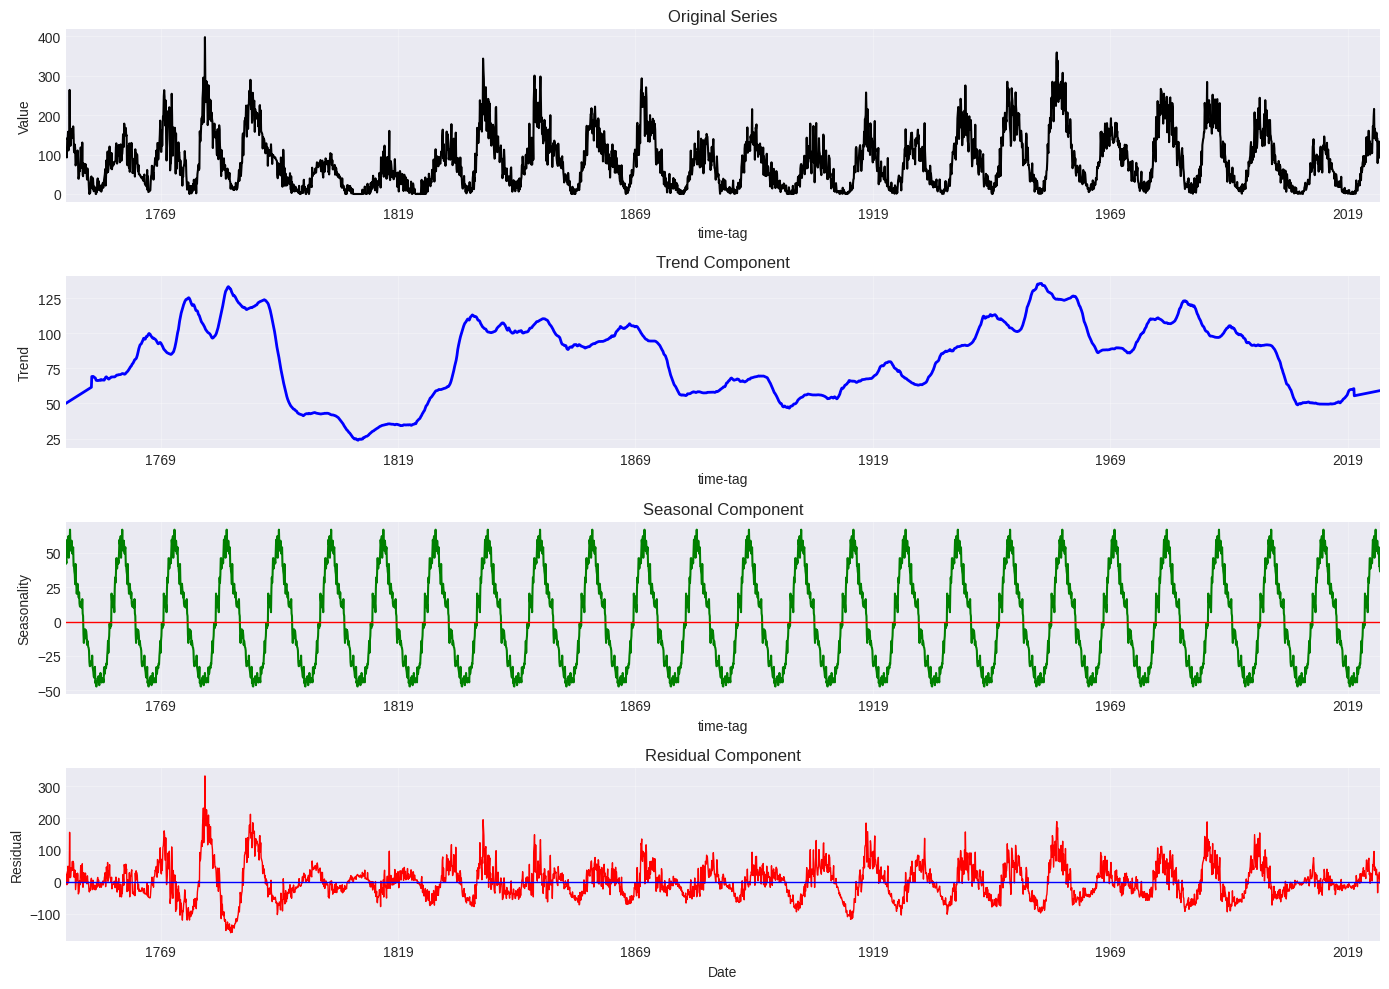

In [ ]:
# Plot the additive decomposition.
ssn_timeseries = solar_cycle_data.set_index(pd.to_datetime(solar_cycle_data['time-tag']))['ssn']
additive_decomposition = seasonal_decompose(ssn_timeseries, model='additive', period=132, extrapolate_trend='freq')
zero_line = pd.Series(0 * len(additive_decomposition.resid), index=additive_decomposition.resid.index)

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

additive_decomposition.observed.plot(ax=axes[0], title='Original Series', color='black', linewidth=1.5)
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

additive_decomposition.trend.plot(ax=axes[1], title='Trend Component', color='blue', linewidth=2)
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

additive_decomposition.seasonal.plot(ax=axes[2], title='Seasonal Component', color='green', linewidth=1.5)
axes[2].plot(zero_line.index, zero_line, color='red', linewidth=1)
axes[2].set_ylabel('Seasonality')
axes[2].grid(True, alpha=0.3)

additive_decomposition.resid.plot(ax=axes[3], title='Residual Component', color='red', linewidth=1)
axes[3].plot(zero_line.index, zero_line, color='blue', linewidth=1)
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

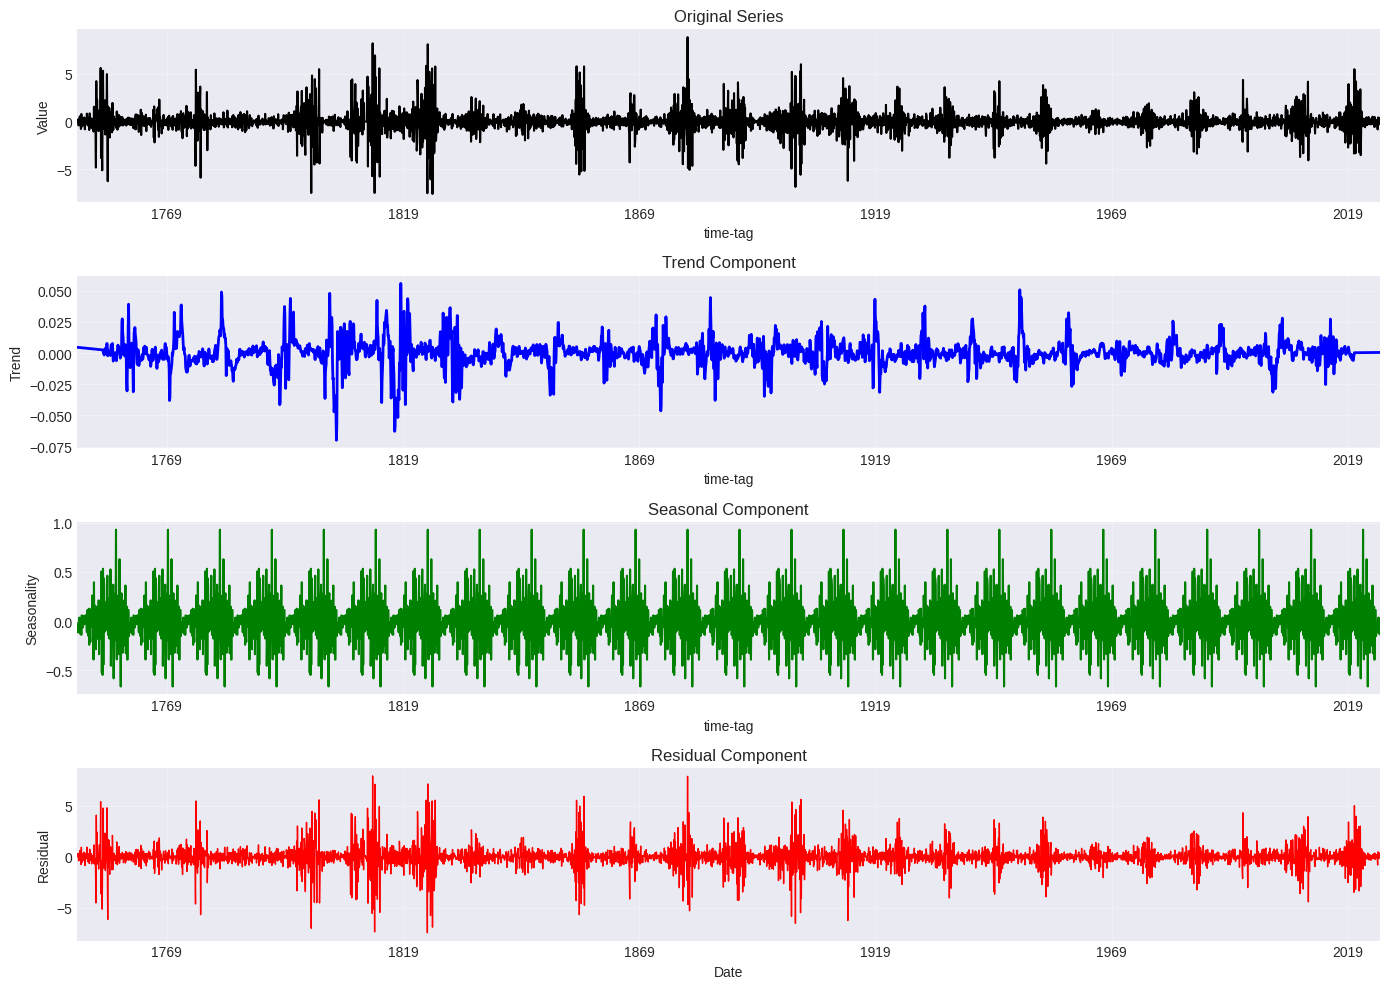

In [ ]:
# Lets visualize the additive decomposition with the log-differenced data.
# First, we need to handle the zeros in the original data before taking log
# Add a small constant to avoid log(0) = -inf
ssn_adjusted = ssn_timeseries.replace(0, 0.1)  # Replace zeros with small positive value
log_ssn_adjusted = np.log(ssn_adjusted)
diff_log_ssn_clean = log_ssn_adjusted.diff(12).diff(1).dropna()

# Now decompose the cleaned differenced log data
additive_log_decomposition = seasonal_decompose(diff_log_ssn_clean, model='additive', period=132, extrapolate_trend='freq')

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

additive_log_decomposition.observed.plot(ax=axes[0], title='Original Series', color='black', linewidth=1.5)
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

additive_log_decomposition.trend.plot(ax=axes[1], title='Trend Component', color='blue', linewidth=2)
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

additive_log_decomposition.seasonal.plot(ax=axes[2], title='Seasonal Component', color='green', linewidth=1.5)
axes[2].set_ylabel('Seasonality')
axes[2].grid(True, alpha=0.3)

additive_log_decomposition.resid.plot(ax=axes[3], title='Residual Component', color='red', linewidth=1)
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

To determine whether our data is stationary or non-stationary, we need to perform a formal statistical test. A time series is **stationary** if its statistical properties (mean, variance, autocorrelation) remain constant over time.

We will test:
- Original sunspot data
- First difference of the data
- Log-transformed data
- First difference of the Log-transformed data

**Reading the Tests:**
- **ADF**: Lower p-values (< 0.05) indicate stationarity
- **KPSS**: Higher p-values (> 0.05) indicate stationarity
- When ADF says "Stationary" AND KPSS says "Stationary" = Strong evidence of stationarity
- When tests disagree = Borderline case or "difference stationary"

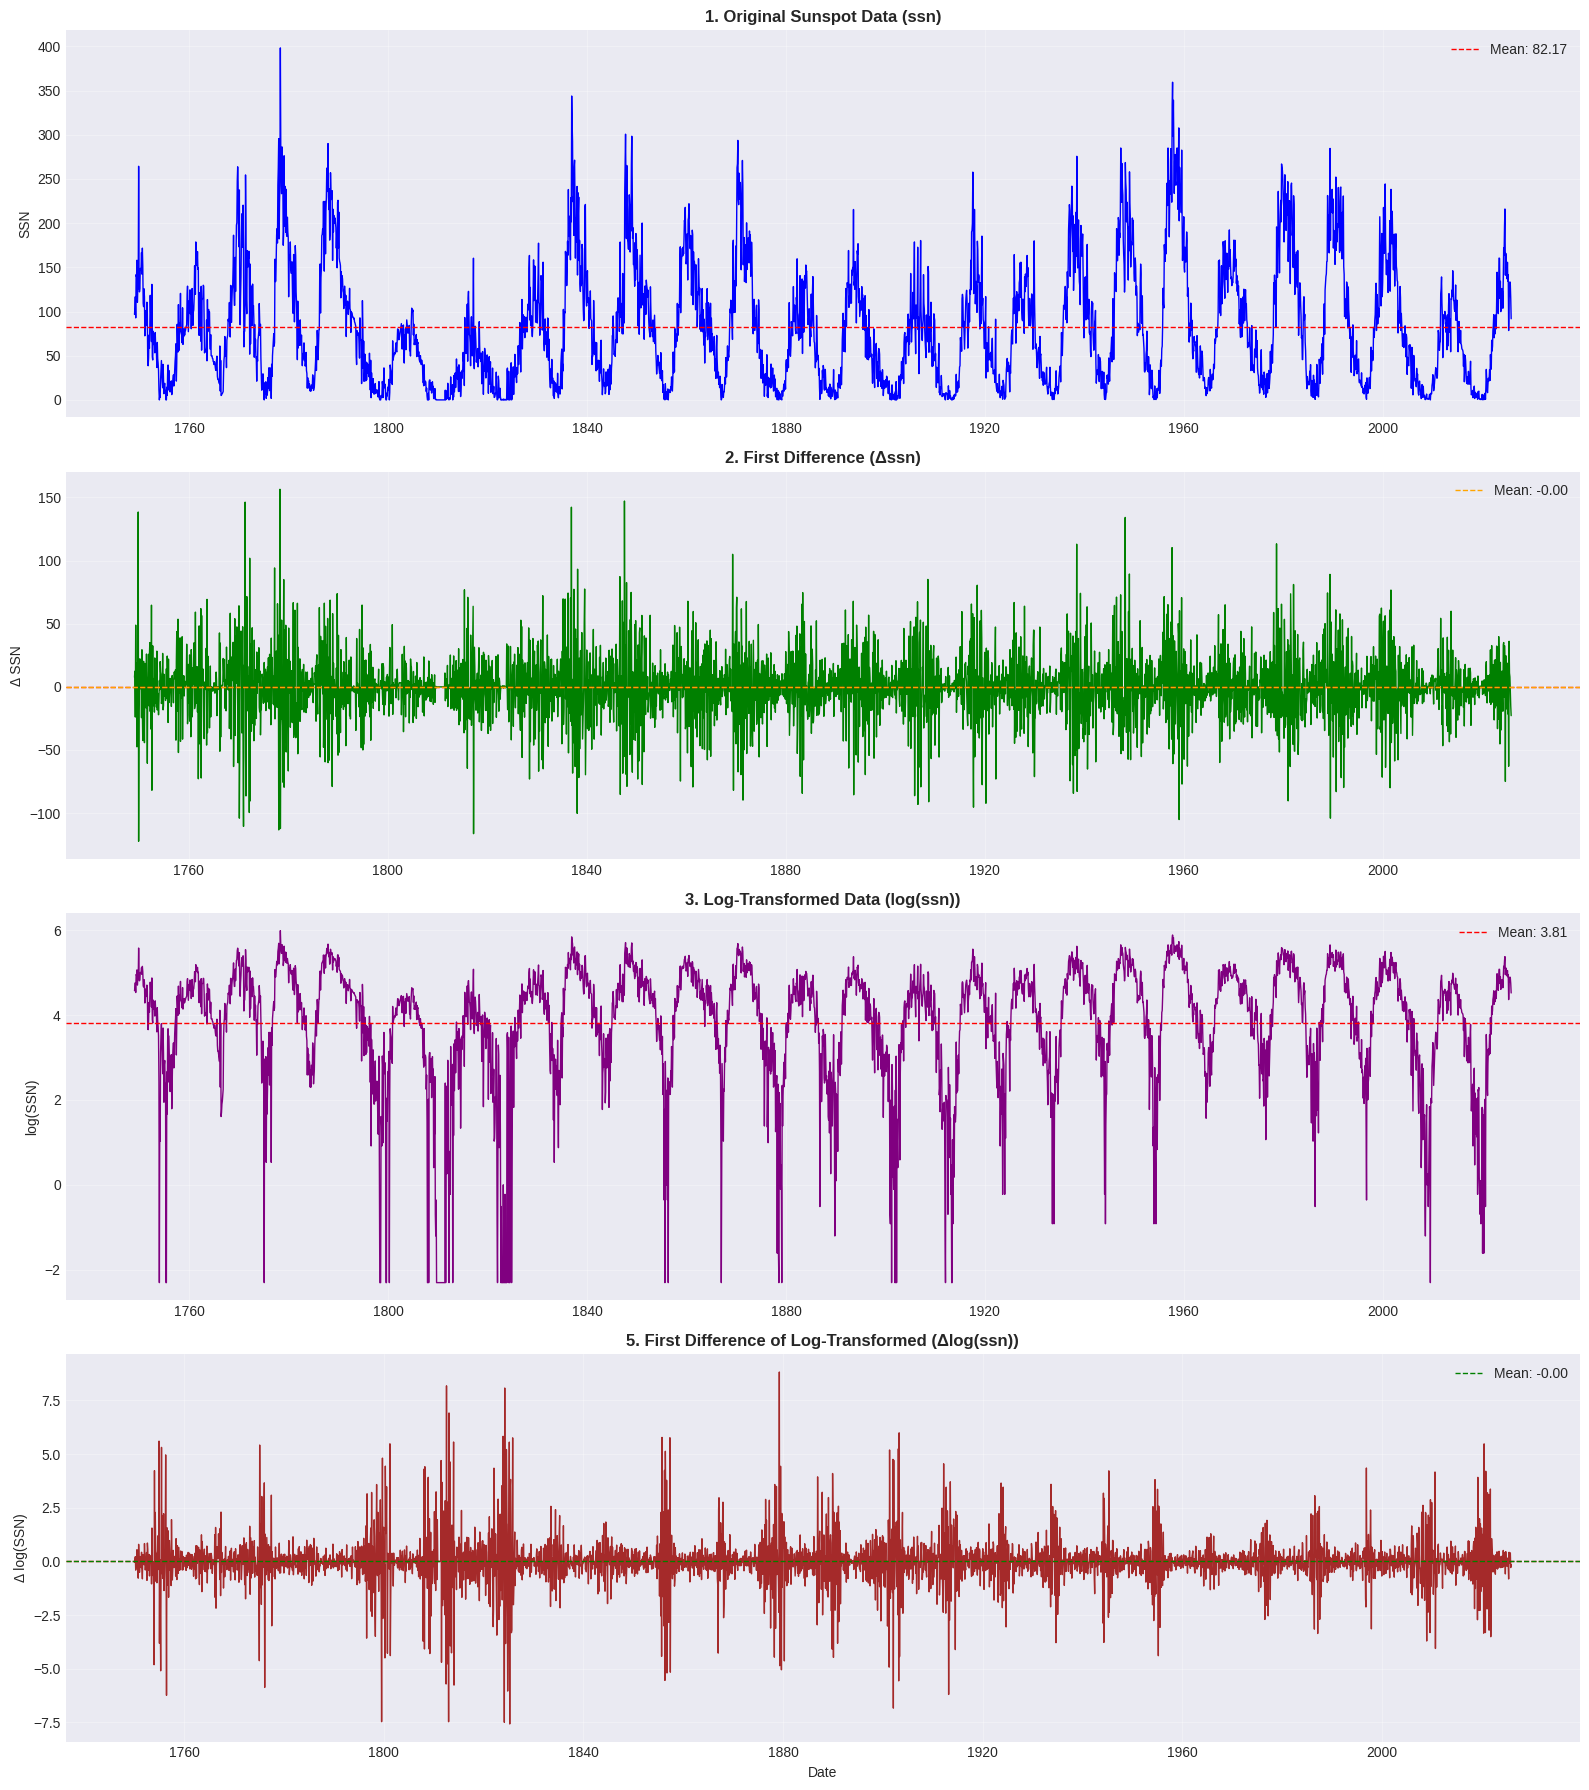

In [ ]:
# Visualize the different transformations side by side
fig, axes = plt.subplots(4, 1, figsize=(16, 18))

# 1. Original Series
axes[0].plot(ssn_timeseries.index, ssn_timeseries, color='blue', linewidth=1)
axes[0].set_title('1. Original Sunspot Data (ssn)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('SSN')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=ssn_timeseries.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {ssn_timeseries.mean():.2f}')
axes[0].legend()

# 2. First Difference
diff_ssn = ssn_timeseries.diff(1).dropna()
axes[1].plot(diff_ssn.index, diff_ssn, color='green', linewidth=1)
axes[1].set_title('2. First Difference (Δssn)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Δ SSN')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].axhline(y=diff_ssn.mean(), color='orange', linestyle='--', linewidth=1, label=f'Mean: {diff_ssn.mean():.2f}')
axes[1].legend()

# 3. Log-Transformed
axes[2].plot(log_ssn_adjusted.index, log_ssn_adjusted, color='purple', linewidth=1)
axes[2].set_title('3. Log-Transformed Data (log(ssn))', fontsize=12, fontweight='bold')
axes[2].set_ylabel('log(SSN)')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=log_ssn_adjusted.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {log_ssn_adjusted.mean():.2f}')
axes[2].legend()

# 5. First Difference of Log
axes[3].plot(diff_log_ssn_clean.index, diff_log_ssn_clean, color='brown', linewidth=1)
axes[3].set_title('5. First Difference of Log-Transformed (Δlog(ssn))', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Date')
axes[3].set_ylabel('Δ log(SSN)')
axes[3].grid(True, alpha=0.3)
axes[3].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[3].axhline(y=diff_log_ssn_clean.mean(), color='green', linestyle='--', linewidth=1, label=f'Mean: {diff_log_ssn_clean.mean():.2f}')
axes[3].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Import stationarity tests
from statsmodels.tsa.stattools import adfuller, kpss

def run_stationarity_tests(series):

    # ADF Test
    adf_result = adfuller(series)
    print(adf_result)
    adf_statistic = adf_result[0]
    adf_pvalue = adf_result[1]
    adf_conclusion = "Stationary" if adf_pvalue < 0.05 else "Non-Stationary"

    # KPSS Test
    kpss_result = kpss(series)
    print(kpss_result)
    kpss_statistic = kpss_result[0]
    kpss_pvalue = kpss_result[1]
    kpss_conclusion = "Non-Stationary" if kpss_pvalue < 0.05 else "Stationary"

    # Create results DataFrame
    results = pd.DataFrame({
        'Test': ['ADF', 'KPSS'],
        'Test Statistic': [adf_statistic, kpss_statistic],
        'P-Value': [adf_pvalue, kpss_pvalue],
        'Conclusion': [adf_conclusion, kpss_conclusion]
    })

    return results

# Test different transformations of the data
print("=" * 100)
print("STATIONARITY TESTS FOR SUNSPOT DATA")
print("=" * 100)

# 1. Original Series
print("\n1. ORIGINAL SUNSPOT DATA (ssn)")
print("-" * 100)
original_results = run_stationarity_tests(ssn_timeseries)
print(original_results.to_string(index=False))

# 2. First Difference
print("\n\n2. FIRST DIFFERENCE (Δssn)")
print("-" * 100)
diff_ssn = ssn_timeseries.diff(1).dropna()
diff_results = run_stationarity_tests(diff_ssn)
print(diff_results.to_string(index=False))

# 3. Log-Transformed (with zeros replaced)
print("\n\n3. LOG-TRANSFORMED DATA (log(ssn))")
print("-" * 100)
log_results = run_stationarity_tests(log_ssn_adjusted)
print(log_results.to_string(index=False))

# 5. First Difference of Log-Transformed
print("\n\n5. FIRST DIFFERENCE OF LOG-TRANSFORMED DATA (Δlog(ssn))")
print("-" * 100)
diff_log_results = run_stationarity_tests(diff_log_ssn_clean)
print(diff_log_results.to_string(index=False))

print("\n" + "=" * 100)

STATIONARITY TESTS FOR SUNSPOT DATA

1. ORIGINAL SUNSPOT DATA (ssn)
----------------------------------------------------------------------------------------------------
(np.float64(-10.69989759858346), np.float64(3.545434509001402e-19), 28, 3294, {'1%': np.float64(-3.4323367648004606), '5%': np.float64(-2.8624178351722858), '10%': np.float64(-2.5672372898489977)}, np.float64(30357.334670879696))
(np.float64(0.11102068593640242), np.float64(0.1), 36, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
Test  Test Statistic      P-Value Conclusion
 ADF      -10.699898 3.545435e-19 Stationary
KPSS        0.111021 1.000000e-01 Stationary


2. FIRST DIFFERENCE (Δssn)
----------------------------------------------------------------------------------------------------
(np.float64(-9.162349363088305), np.float64(2.5132431939903377e-15), 28, 3293, {'1%': np.float64(-3.432337368601478), '5%': np.float64(-2.8624181018676236), '10%': np.float64(-2.567237431831631)}, np.float64(30453.1382468616

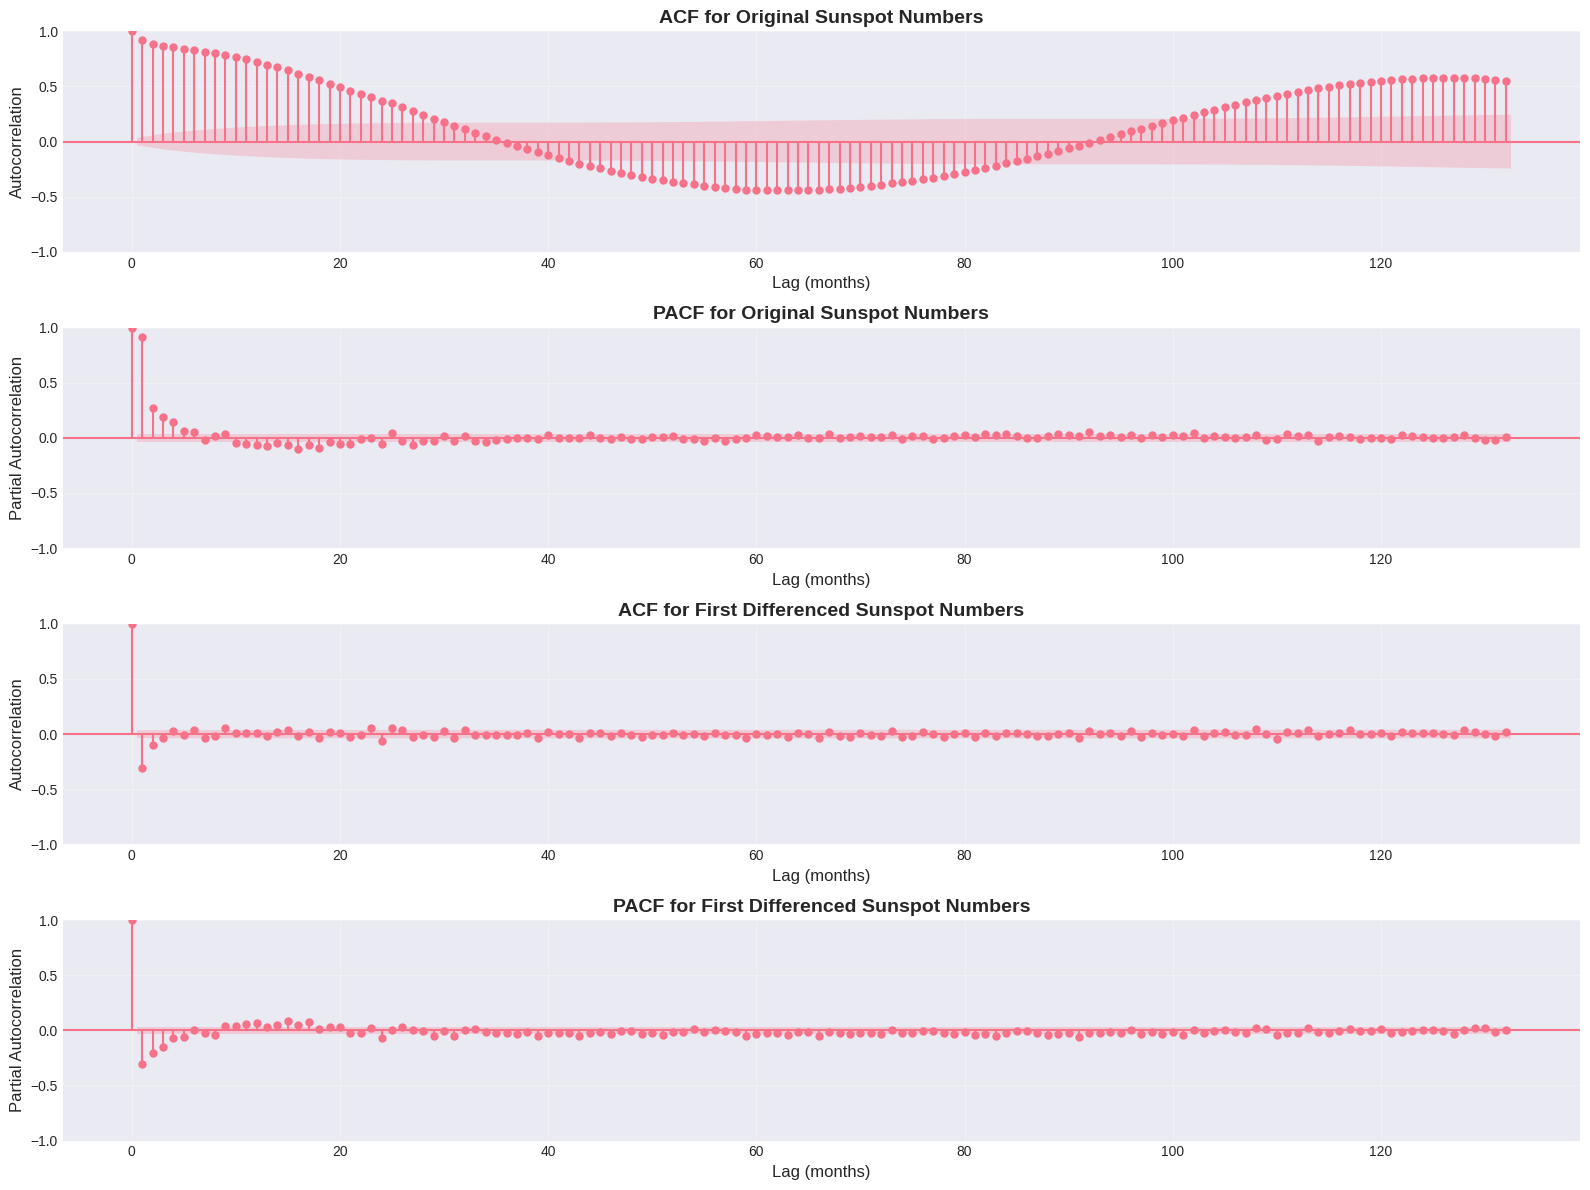

In [ ]:
# Define the lag based on the 11-year cycle (12 months x 11 years = 132 lags)
seasonal_lag = 132

# For both ACF and PACF graphs of regular data and diff data.
# ssn_timeseries is the original series, diff_ssn is the differenced series
ssn_for_acf_pacf = ssn_timeseries
diff_ssn_for_acf_pacf = diff_ssn

# Create figure with two rows and two columns for the plots
fig, axes = plt.subplots(4, 1, figsize=(16, 12))

# Plot ACF (Autocorrelation Function) for Original Sunspot Numbers
plot_acf(ssn_for_acf_pacf, lags=seasonal_lag, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF for Original Sunspot Numbers', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lag (months)', fontsize=12)
axes[0].set_ylabel('Autocorrelation', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Plot PACF (Partial Autocorrelation Function) for Original Sunspot Numbers
plot_pacf(ssn_for_acf_pacf, lags=seasonal_lag, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF for Original Sunspot Numbers', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lag (months)', fontsize=12)
axes[1].set_ylabel('Partial Autocorrelation', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Plot ACF (Autocorrelation Function) for First Differenced Sunspot Numbers
plot_acf(diff_ssn_for_acf_pacf, lags=seasonal_lag, ax=axes[2], alpha=0.05)
axes[2].set_title('ACF for First Differenced Sunspot Numbers', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Lag (months)', fontsize=12)
axes[2].set_ylabel('Autocorrelation', fontsize=12)
axes[2].grid(True, alpha=0.3)

# Plot PACF (Partial Autocorrelation Function) for First Differenced Sunspot Numbers
plot_pacf(diff_ssn_for_acf_pacf, lags=seasonal_lag, ax=axes[3], alpha=0.05, method='ywm')
axes[3].set_title('PACF for First Differenced Sunspot Numbers', fontsize=14, fontweight='bold')
axes[3].set_xlabel('Lag (months)', fontsize=12)
axes[3].set_ylabel('Partial Autocorrelation', fontsize=12)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# # Print numerical ACF and PACF values for key lags
# print("=" * 80)
# print("ACF and PACF Values for Key Lags")
# print("=" * 80)

# print(f" ACF values (Original): {acf(ssn_for_acf_pacf, nlags=seasonal_lag, fft=False)}")
# print(f" PACF values (Original): {pacf(ssn_for_acf_pacf, nlags=seasonal_lag, method='ywm')}")
# print(f" ACF values (Differenced): {acf(diff_ssn_for_acf_pacf, nlags=seasonal_lag, fft=False)}")
# print(f" PACF values (Differenced): {pacf(diff_ssn_for_acf_pacf, nlags=seasonal_lag, method='ywm')}")


### What does the ADF/KPSS and ACF/PACF analysis say?
---

### Summary of Stationarity Tests (ADF and KPSS)

All four transformations tested—**original data**, **first difference**, **log-transformed**, and **first difference of log-transformed**—showed stationary behavior according to both the Augmented Dickey-Fuller (ADF) and Kwiatkowski-Phillips-Schmidt-Shin (KPSS) tests. However, this statistical stationarity is somewhat deceptive for practical forecasting purposes:

### Key Findings from Stationarity Tests:

1. **Original Sunspot Data (ssn)**:
   - **ADF Test**: Test statistic = -10.70, p-value ≈ 0 → **Stationary**
   - **KPSS Test**: Test statistic = 0.11, p-value = 0.10 → **Stationary**
   - **Interpretation**: While the tests indicate stationarity, the original data contains a strong 11-year cyclical pattern that is visible in ACF/PACF plots. The tests detect that mean and variance are relatively stable over time, but they don't capture the dominant seasonal structure.

2. **First Difference (Δssn)**:
   - **ADF Test**: Test statistic = -9.16, p-value ≈ 0 → **Stationary**
   - **KPSS Test**: Test statistic = 0.006, p-value = 0.10 → **Stationary**
   - **Interpretation**: Differencing removes some trend but the 11-year seasonal pattern remains visible in the ACF/PACF.

3. **Log-Transformed Data (log(ssn))**:
   - **ADF Test**: Test statistic = -9.03, p-value ≈ 0 → **Stationary**
   - **KPSS Test**: Test statistic = 0.13, p-value = 0.10 → **Stationary**
   - **Interpretation**: Log transformation stabilizes variance but the cyclical pattern persists.

4. **First Difference of Log-Transformed (Δlog(ssn))**:
   - **ADF Test**: Test statistic = -12.39, p-value ≈ 0 → **Stationary**
   - **KPSS Test**: Test statistic = 0.03, p-value = 0.10 → **Stationary**
   - **Interpretation**: This transformation shows the strongest stationarity and successfully removes both variance instability and most of the cyclical component, resulting in non-periodic behavior in ACF/PACF plots.

---

## ACF and PACF Analysis

The Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) provide critical insights into the temporal dependencies and cyclical patterns in the sunspot data.

### 1. ACF (Autocorrelation Function) Interpretation

The ACF measures the correlation between the time series and its lagged values:

- **Strong Positive Autocorrelation at Short Lags**: The ACF shows high positive values at initial lags (1-24 months), indicating that sunspot numbers in consecutive months are highly correlated. This confirms strong short-term persistence in solar activity—if there are many sunspots this month, there will likely be many next month.

- **Slow, Gradual Decay Pattern**: The ACF exhibits gradual decay rather than dropping quickly to zero. This is characteristic of a time series with long-term dependencies and persistent patterns, confirming the presence of the 11-year solar cycle.

- **Oscillating Pattern at Longer Lags**: The ACF oscillates between positive and negative values at longer lags, which is a hallmark of cyclical behavior. This reflects the 11-year solar cycle—positive correlations appear when comparing observations approximately 11 years (132 months) apart, as they are in similar phases of different cycles.

- **Statistical Significance**: Values extending beyond the confidence bands (at 95% confidence level) indicate statistically significant correlations. The presence of many significant lags confirms that past values have meaningful predictive power for future sunspot numbers.

### 2. PACF (Partial Autocorrelation Function) Interpretation

The PACF measures the correlation between the time series and its lagged values after removing the effects of intermediate lags:

- **Sharp Cutoff After Initial Lags**: The PACF shows significant values at only the first few lags before dropping to near-zero values within the confidence bands. This pattern helps identify the order of an autoregressive (AR) model.

- **Significant First Lag**: A strong PACF value at lag 1 indicates that the immediate previous observation is highly predictive of the current value, even after accounting for all other lags. This confirms month-to-month persistence in sunspot activity.

- **Identification of AR Order**: The number of significant PACF spikes (those outside the confidence bands) at the beginning suggests the appropriate order for an AR model. Significant spikes at lags 1, 2, and possibly 3 indicate that an AR(2) or AR(3) model might be appropriate for the non-seasonal component.

- **Removal of Indirect Effects**: The PACF isolates the direct effect of each lag by removing correlations caused by intermediate observations, helping distinguish between direct dependencies and indirect correlations that appear in the ACF.

---

## Implications for SARIMA Modeling

Based on the combined ADF/KPSS and ACF/PACF analyses:

### Seasonal Component (11-year cycle):
- **Seasonal period (m)**: 132 months (12 months × 11 years)
- **Seasonal differencing (D)**: Start with D=0 since data is technically stationary; try D=1 if the model struggles with seasonal trends
- **Seasonal AR (P)**: Start with P=1 or P=2 based on seasonal ACF patterns
- **Seasonal MA (Q)**: Start with Q=1 or Q=2 based on seasonal PACF patterns

### Non-Seasonal Component:
- **Non-seasonal differencing (d)**: d=0 (data is stationary according to tests)
- **AR order (p)**: Start with p=1, p=2, or p=3 based on PACF cutoff
- **MA order (q)**: Start with q=1 or q=2 based on ACF decay

### Recommended Starting Models:
1. SARIMA(1,0,1)(1,0,1,132)
2. SARIMA(2,0,2)(1,0,1,132)
3. SARIMA(1,0,1)(2,0,1,132)
4. SARIMA(2,0,1)(1,0,2,132)

Use AIC and BIC criteria to select the optimal model among these candidates.

---

## Key Takeaways

1. **All transformations are stationary** according to formal tests, but the original data and simple transformations retain strong seasonal patterns visible in ACF/PACF.

2. **The 11-year solar cycle is the dominant feature** of the time series, requiring seasonal ARIMA modeling (SARIMA) rather than standard ARIMA.

3. **Short-term persistence exists** at monthly lags, requiring appropriate AR and MA terms in the non-seasonal component.

4. **SARIMA is the appropriate model** for this data, as it can explicitly handle both the 11-year seasonal cycle and the short-term autocorrelation structure.

5. **First difference of log-transformed data** removes most cyclical patterns but requires complex back-transformation for forecasting in original units. Using SARIMA on the original data is more interpretable and avoids back-transformation bias.

## 2.4 Data Quality
---

The NOAA SWPC sunspot dataset is clean and highly consistent. All monthly observations from 1749 to 2025 are present, so there are no missing values that require interpolation or correction. A review of the distribution and time-series plots also shows no unusual spikes or anomalies. The high sunspot counts observed during solar maxima are expected features of the 11-year cycle rather than true outliers. Overall, the data quality is excellent, with a complete record and no outliers that require adjustment.

## 3.1 Models to Apply

---

Simple Moving Average (SMA): We use the SMA to smooth the sunspot number series to better observe underlying trends.

For smaller windows such as for 3 - 7 months, there is a quicker reaction to changes and they preserve the most short-term fluctuations. This is useful fo ridentifying any anomalies or emerging patterns in the solar activity we are measuring. larger windows provide even stronger smoothing, making the long-term trends easier to interpret. In comparing multiple SMA windows we can see how different smoothing levels show different aspects of solar behavior.

The 12 month and 24 month SMA's provide further examples of reducing short-term monthly fluctuations and long-term trends. The 12 month SMA offers moderate smoothing, although it still responds quickly to changes in solar behavior. The 24 month produces a slower, more stable trend line.

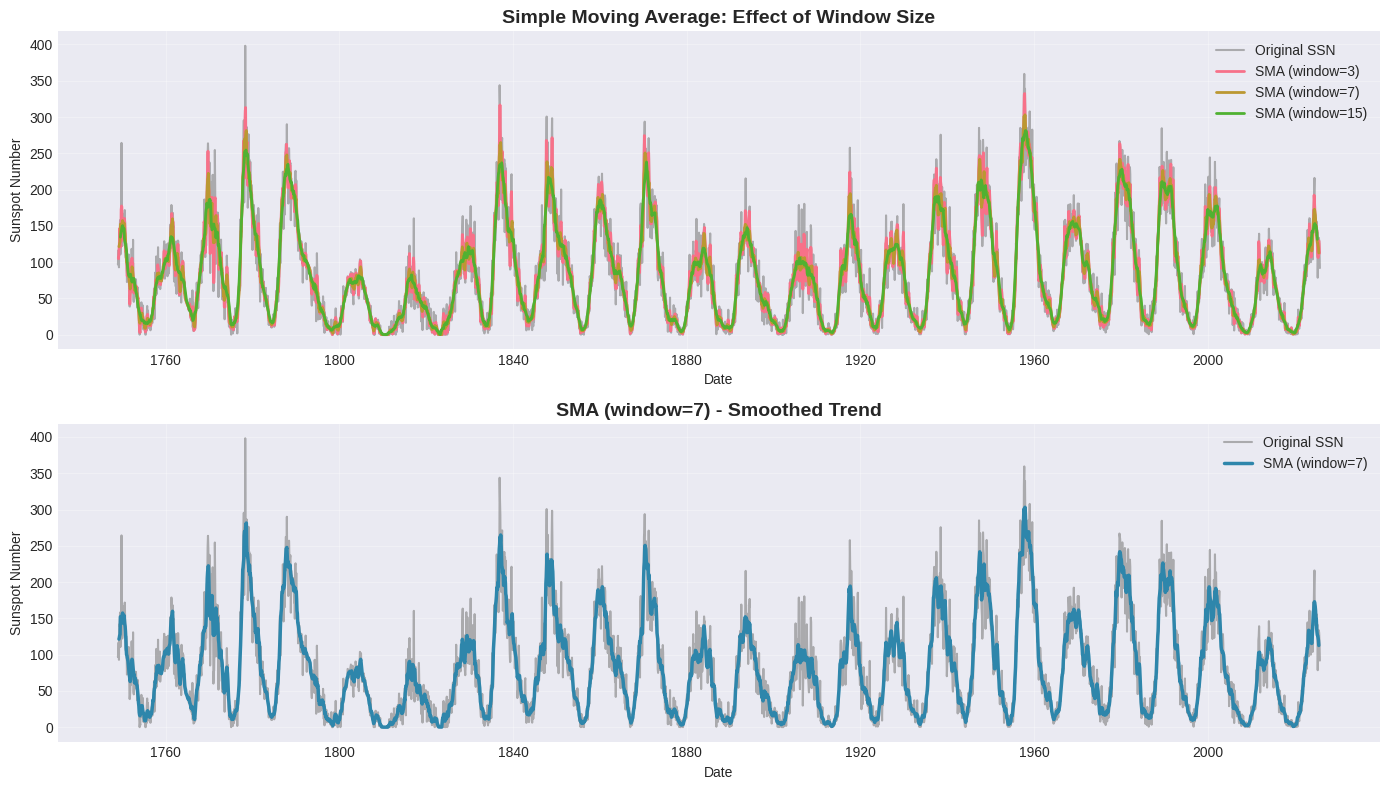


Observations:
- Smaller window (3): More responsive to quick fluctuations
- Medium window (7): Balanced smoothing
- Larger window (15): Very smooth but less responsive to peaks/valleys


In [ ]:
#Simple Moving Average Function
def simple_moving_average(series, window_size):
    """
    Calculate Simple Moving Average

    Parameters:

    series : pd.Series
        Time series data
    window_size : int
        Size of the moving window (should be odd for centering)

    Returns:

    pd.Series
        Smoothed series
    """
    return series.rolling(window=window_size, center=True).mean()

#Apply SMA to the existing notebook SSN series
ts = ssn_timeseries        # REPLACES df_solar["ssn"]

sma_3  = simple_moving_average(ts, 3)
sma_7  = simple_moving_average(ts, 7)
sma_15 = simple_moving_average(ts, 15)

#Plot Comparison (Matching Template Style)
plt.figure(figsize=(14, 8))

#Top panel: compare multiple windows
plt.subplot(2, 1, 1)
plt.plot(ts.index, ts, label='Original SSN', linewidth=1.5, alpha=0.6, color='gray')
plt.plot(ts.index, sma_3,  label='SMA (window=3)', linewidth=2)
plt.plot(ts.index, sma_7,  label='SMA (window=7)', linewidth=2)
plt.plot(ts.index, sma_15, label='SMA (window=15)', linewidth=2)

plt.title('Simple Moving Average: Effect of Window Size', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sunspot Number')
plt.legend()
plt.grid(True, alpha=0.3)

#Bottom panel: highlight one window
plt.subplot(2, 1, 2)
plt.plot(ts.index, ts, label='Original SSN', linewidth=1.5, alpha=0.6, color='gray')
plt.plot(ts.index, sma_7, label='SMA (window=7)', linewidth=2.5, color='#2E86AB')

plt.title('SMA (window=7) - Smoothed Trend', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sunspot Number')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# === Observations ===
print("\nObservations:")
print(f"- Smaller window (3): More responsive to quick fluctuations")
print(f"- Medium window (7): Balanced smoothing")
print(f"- Larger window (15): Very smooth but less responsive to peaks/valleys")


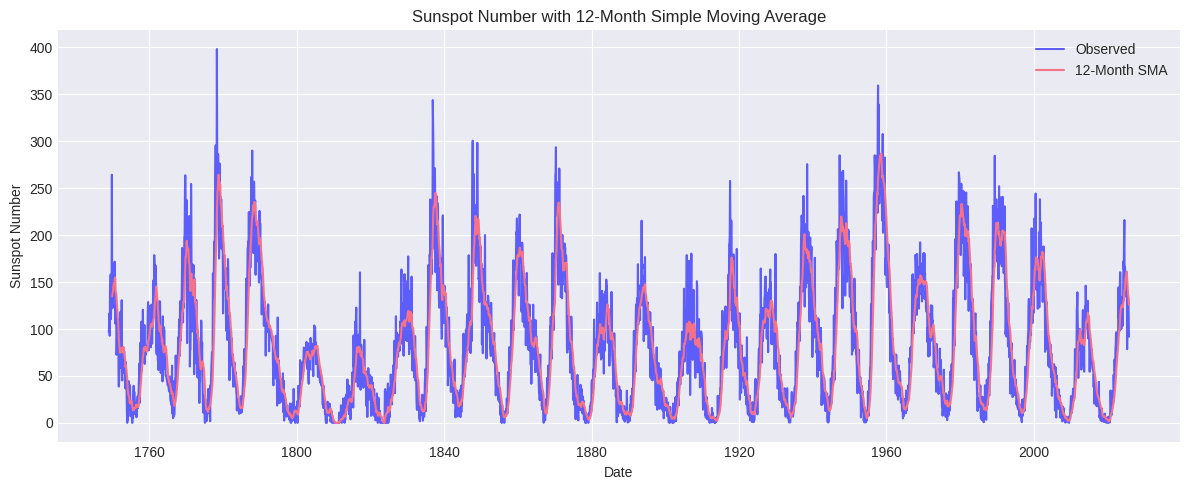

In [ ]:
# Simple Moving Average (12-month window)
SMA_12 = ssn_timeseries.rolling(window=12, min_periods=12).mean()

plt.figure(figsize=(12,5))
plt.plot(ssn_timeseries.index, ssn_timeseries, label="Observed", color="blue", alpha=0.6)
plt.plot(SMA_12.index, SMA_12, label="12-Month SMA")
plt.title("Sunspot Number with 12-Month Simple Moving Average")
plt.xlabel("Date")
plt.ylabel("Sunspot Number")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


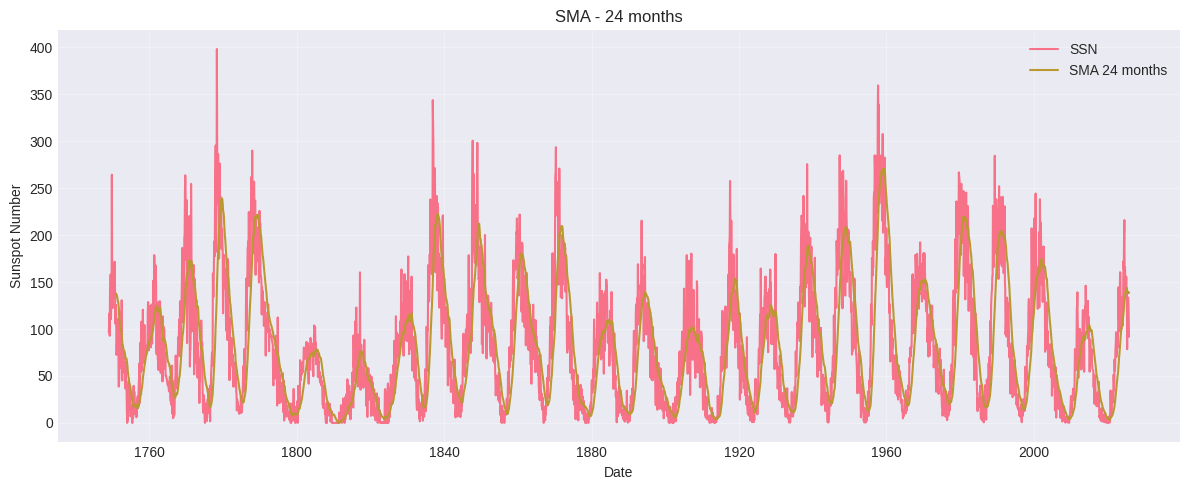

In [ ]:
# 24-month Simple Moving Average using the datetime-indexed SSN series
sma_24 = ssn_timeseries.rolling(window=24).mean()

plt.figure(figsize=(12,5))
plt.plot(ssn_timeseries.index, ssn_timeseries, label="SSN")
plt.plot(sma_24.index, sma_24, label="SMA 24 months")
plt.legend()
plt.title("SMA - 24 months")
plt.xlabel("Date")
plt.ylabel("Sunspot Number")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Exponentially Weighted Moving Average (EWMA): EWMA can also be used to smooth the sunspot number series but the key difference is that recent observations carry more weight than older ones. Therefore, EWMA will be more responsive to recent changes in solar activity.

The 12 month EWMA shows year-scale variations, reacting quickly to shifts but smoothing out month to month volatility. The 24 month EWMA highlights multiple trends and examines the broader structure of the solar cycle like rises and declines in activity.

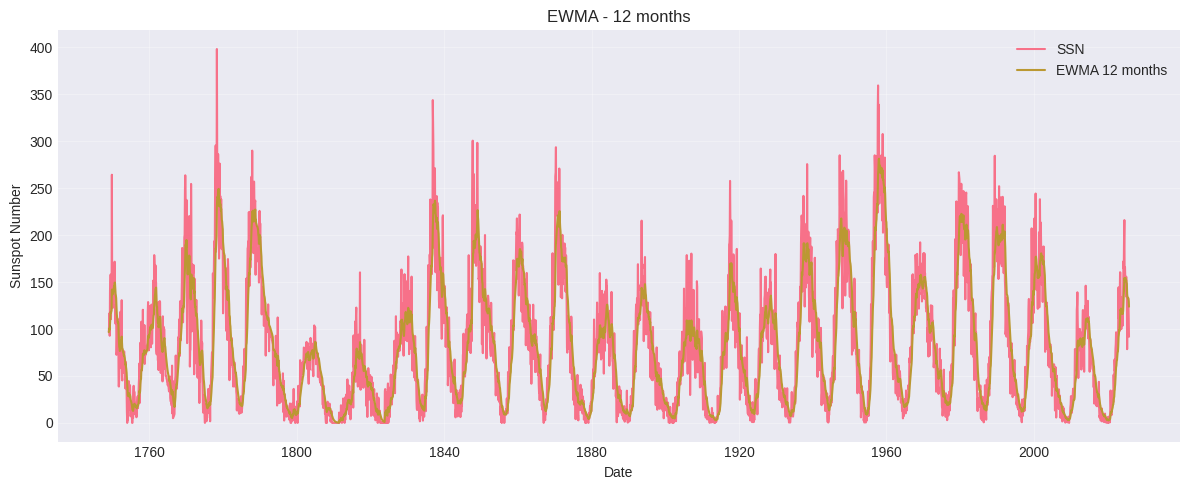

In [ ]:
# 12-month Exponentially Weighted Moving Average
ewma_12 = ssn_timeseries.ewm(span=12, adjust=False).mean()

plt.figure(figsize=(12,5))
plt.plot(ssn_timeseries.index, ssn_timeseries, label="SSN")
plt.plot(ewma_12.index, ewma_12, label="EWMA 12 months")
plt.legend()
plt.title("EWMA - 12 months")
plt.xlabel("Date")
plt.ylabel("Sunspot Number")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


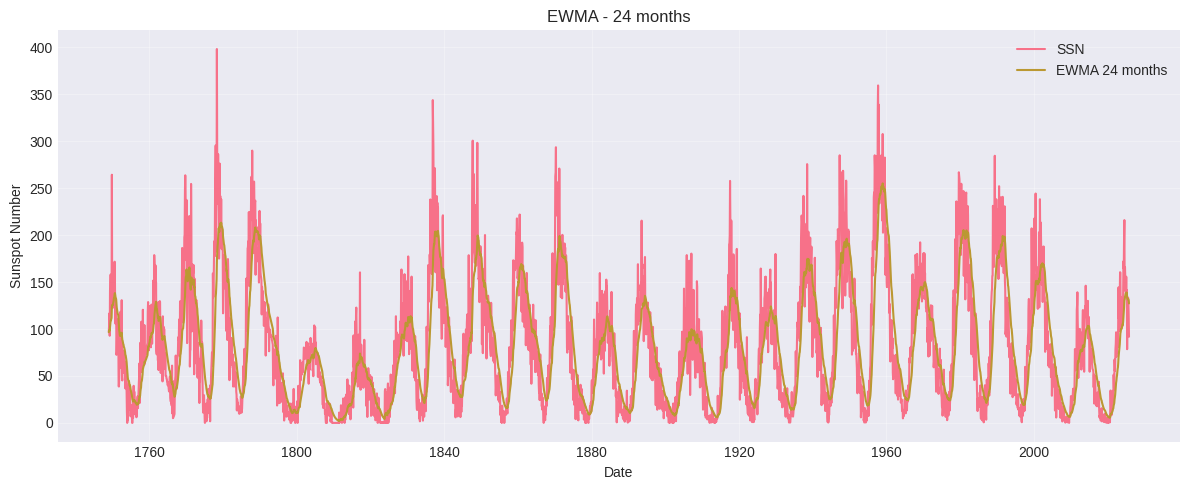

In [ ]:
# 24-month Exponentially Weighted Moving Average
ewma_24 = ssn_timeseries.ewm(span=24, adjust=False).mean()

plt.figure(figsize=(12,5))
plt.plot(ssn_timeseries.index, ssn_timeseries, label="SSN")
plt.plot(ewma_24.index, ewma_24, label="EWMA 24 months")
plt.legend()
plt.title("EWMA - 24 months")
plt.xlabel("Date")
plt.ylabel("Sunspot Number")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


ARIMA (1,0,1): Was used after considering Auto ARIMA, it provides a simple structure but is found to be lacking for differencing and seasonal components. It overall fails to capture short-term fluctuations and the longer sunspot cycle.

ARIMA 2,0,2: The ARIMA(2,0,2) model applies moving average and autogressive components into the raw data without differencing. The solar cycle is mainly non-stationary, so short-term behavior is captured more strongly. This ARIMA models provides a useful baseline for how short-term behaviors can be explained without differencing and seasonality. Originally ARIMA's were formatted using their monthly data, but to compare them against the SARIMA (11 year) and ensure consistency the formatting was changed to an annual series.

                               SARIMAX Results                                
Dep. Variable:                    ssn   No. Observations:                  277
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1341.669
Date:                Wed, 17 Dec 2025   AIC                           2691.338
Time:                        08:26:45   BIC                           2705.834
Sample:                    12-31-1749   HQIC                          2697.154
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         82.1973     12.478      6.587      0.000      57.740     106.655
ar.L1          0.7172      0.051     14.172      0.000       0.618       0.816
ma.L1          0.5271      0.052     10.087      0.0

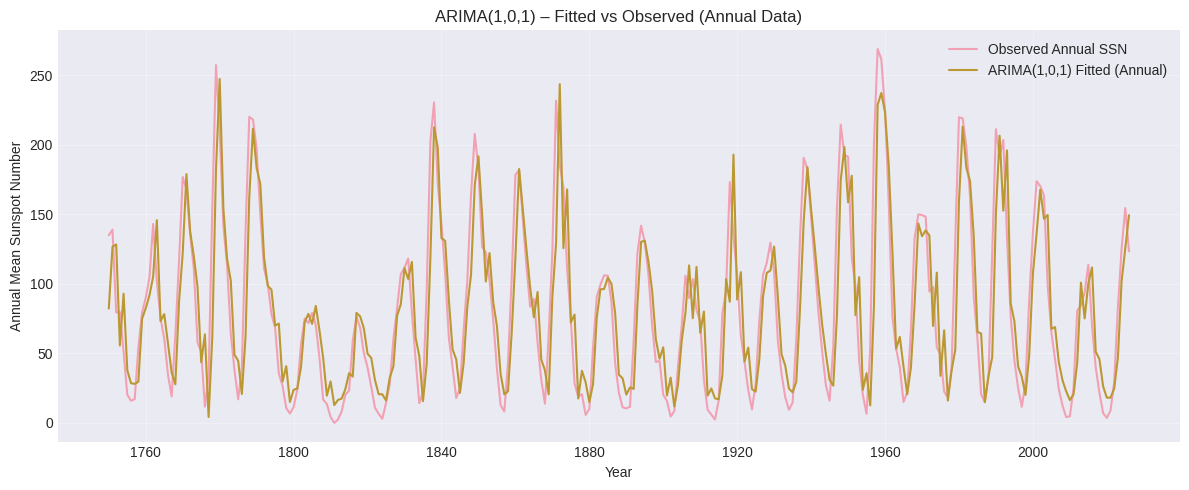

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# 1. Build ANNUAL series from monthly ssn_timeseries
df_annual = ssn_timeseries.resample("A").mean()
y_annual = df_annual.dropna()

# 2. Fit ARIMA(1,0,1) on ANNUAL data
arima_101_annual = ARIMA(y_annual, order=(1, 0, 1))
arima_101_annual_results = arima_101_annual.fit()

print(arima_101_annual_results.summary())

# 3. In-sample fitted values
fitted_101_annual = arima_101_annual_results.fittedvalues

# 4. Plot observed vs fitted (ANNUAL data)
plt.figure(figsize=(12,5))
plt.plot(y_annual.index, y_annual, label="Observed Annual SSN", alpha=0.6)
plt.plot(fitted_101_annual.index, fitted_101_annual,
         label="ARIMA(1,0,1) Fitted (Annual)", linewidth=1.5)

plt.legend()
plt.title("ARIMA(1,0,1) – Fitted vs Observed (Annual Data)")
plt.xlabel("Year")
plt.ylabel("Annual Mean Sunspot Number")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


                               SARIMAX Results                                
Dep. Variable:                    ssn   No. Observations:                  277
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -1296.352
Date:                Wed, 17 Dec 2025   AIC                           2604.703
Time:                        08:24:58   BIC                           2626.447
Sample:                    12-31-1749   HQIC                          2613.428
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         81.9025      5.339     15.340      0.000      71.438      92.367
ar.L1          1.4669      0.078     18.833      0.000       1.314       1.620
ar.L2         -0.7732      0.063    -12.318      0.0

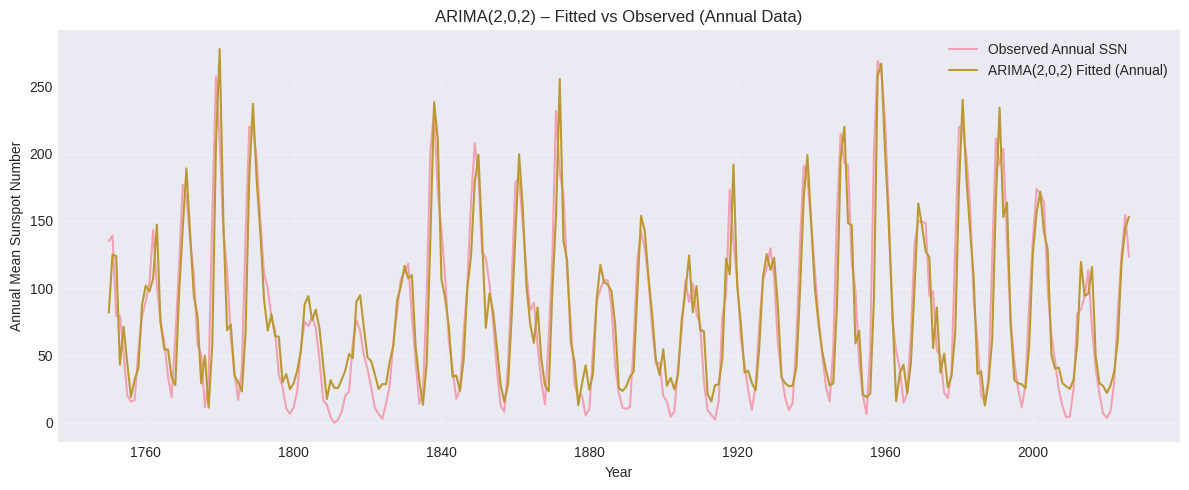

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# 1. Build ANNUAL series from monthly ssn_timeseries
#    (year-end frequency, then drop any missing values)
df_annual = ssn_timeseries.resample("A").mean()
y_annual = df_annual.dropna()

# 2. Fit ARIMA(2,0,2) on the ANNUAL SSN series
arima_202_annual = ARIMA(y_annual, order=(2, 0, 2))
arima_202_annual_results = arima_202_annual.fit()

print(arima_202_annual_results.summary())

# 3. In-sample fitted values
fitted_202_annual = arima_202_annual_results.fittedvalues

# 4. Plot: Observed vs Fitted (ANNUAL)
plt.figure(figsize=(12,5))
plt.plot(y_annual.index, y_annual, label="Observed Annual SSN", alpha=0.6)
plt.plot(fitted_202_annual.index, fitted_202_annual,
         label="ARIMA(2,0,2) Fitted (Annual)", linewidth=1.5)
plt.legend()
plt.title("ARIMA(2,0,2) – Fitted vs Observed (Annual Data)")
plt.xlabel("Year")
plt.ylabel("Annual Mean Sunspot Number")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


ARIMA (1,1,1): Differencing improved stationarity for ARIMA (1,1,1), proving it to provide a better model for a baseline than previous ARIMA's.

ARIMA (2,1,2): The ARIMA(2,1,2) model uses differencing with removes part of the trend and moves the series into stationarity. Therefore, this ARIMA model is better suite for capturing the underlying trends better than the first ARIMA model. While this is a better baseline mode, it still does not account for seasonality.

ARIMA (3,0,2): While this ARIMA was considered highly rated by the Auto ARIMA, there is still remaining structure shown in the residuals while reducing some autocorrelation.


                               SARIMAX Results                                
Dep. Variable:                    ssn   No. Observations:                  277
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1348.174
Date:                Wed, 17 Dec 2025   AIC                           2702.348
Time:                        08:27:22   BIC                           2713.210
Sample:                    12-31-1749   HQIC                          2706.707
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3966      0.080      4.946      0.000       0.239       0.554
ma.L1          0.2125      0.088      2.423      0.015       0.041       0.384
sigma2      1022.5934     70.284     14.549      0.0

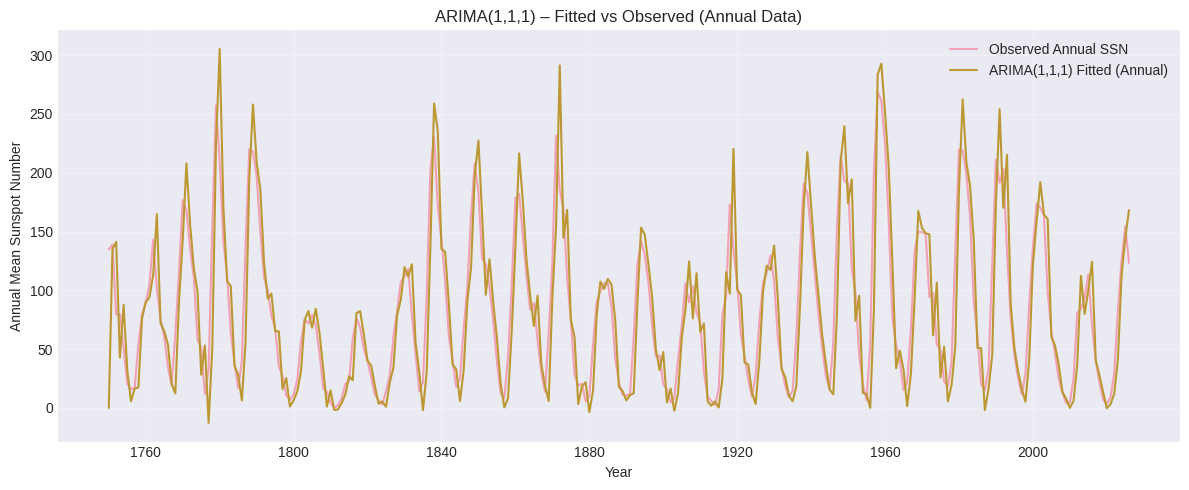

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# 1. Build ANNUAL series from monthly ssn_timeseries
df_annual = ssn_timeseries.resample("A").mean()
y_annual = df_annual.dropna()

# 2. Fit ARIMA(1,1,1) on ANNUAL data
arima_111_annual = ARIMA(y_annual, order=(1, 1, 1)).fit()
print(arima_111_annual.summary())

# 3. In-sample fitted values
fitted_111_annual = arima_111_annual.predict(
    start=y_annual.index[0],
    end=y_annual.index[-1]
)

# 4. Plot observed vs fitted (ANNUAL)
plt.figure(figsize=(12,5))
plt.plot(y_annual.index, y_annual, label="Observed Annual SSN", alpha=0.6)
plt.plot(fitted_111_annual.index, fitted_111_annual,
         label="ARIMA(1,1,1) Fitted (Annual)", linewidth=1.5)

plt.legend()
plt.title("ARIMA(1,1,1) – Fitted vs Observed (Annual Data)")
plt.xlabel("Year")
plt.ylabel("Annual Mean Sunspot Number")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


                               SARIMAX Results                                
Dep. Variable:                    ssn   No. Observations:                  277
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -1282.567
Date:                Wed, 17 Dec 2025   AIC                           2575.133
Time:                        08:27:03   BIC                           2593.235
Sample:                    12-31-1749   HQIC                          2582.398
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5999      0.031     51.128      0.000       1.539       1.661
ar.L2         -0.9275      0.027    -34.714      0.000      -0.980      -0.875
ma.L1         -1.4841      0.061    -24.332      0.0

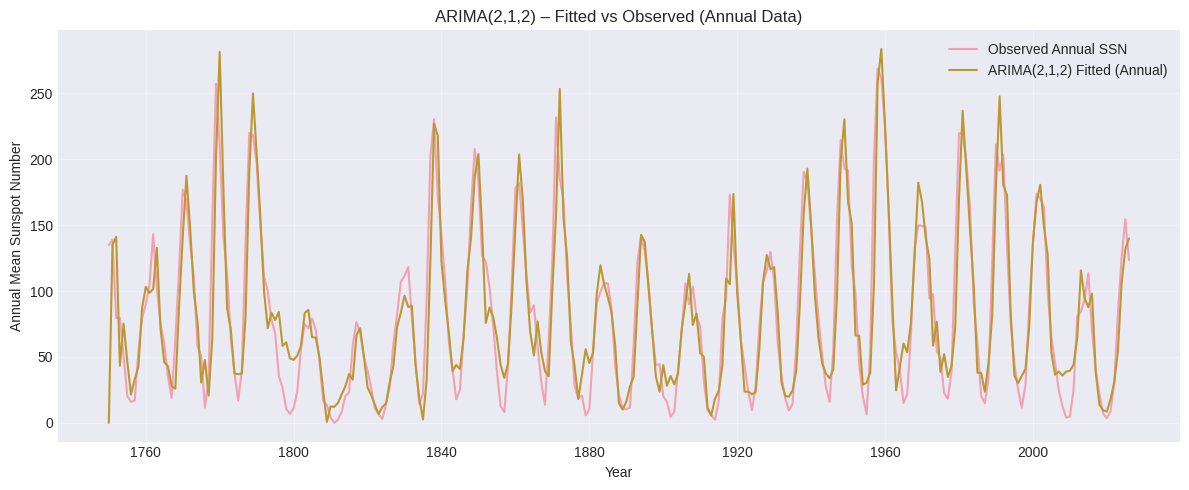

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# 1. Build ANNUAL series from monthly ssn_timeseries
df_annual = ssn_timeseries.resample("A").mean()
y_annual = df_annual.dropna()

# 2. Fit ARIMA(2,1,2) on ANNUAL data
arima_212_annual = ARIMA(y_annual, order=(2, 1, 2)).fit()
print(arima_212_annual.summary())

# 3. In-sample fitted values
fitted_212_annual = arima_212_annual.predict(
    start=y_annual.index[0],
    end=y_annual.index[-1]
)

# 4. Plot observed vs fitted (ANNUAL)
plt.figure(figsize=(12,5))
plt.plot(y_annual.index, y_annual, label="Observed Annual SSN", alpha=0.6)
plt.plot(fitted_212_annual.index, fitted_212_annual,
         label="ARIMA(2,1,2) Fitted (Annual)", linewidth=1.5)

plt.legend()
plt.title("ARIMA(2,1,2) – Fitted vs Observed (Annual Data)")
plt.xlabel("Year")
plt.ylabel("Annual Mean Sunspot Number")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


                               SARIMAX Results                                
Dep. Variable:                    ssn   No. Observations:                  277
Model:                 ARIMA(3, 0, 2)   Log Likelihood               -1296.146
Date:                Wed, 17 Dec 2025   AIC                           2606.292
Time:                        08:28:12   BIC                           2631.661
Sample:                    12-31-1749   HQIC                          2616.471
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         81.9090      5.386     15.209      0.000      71.353      92.465
ar.L1          0.7979      0.588      1.356      0.175      -0.355       1.951
ar.L2          0.2101      0.901      0.233      0.8

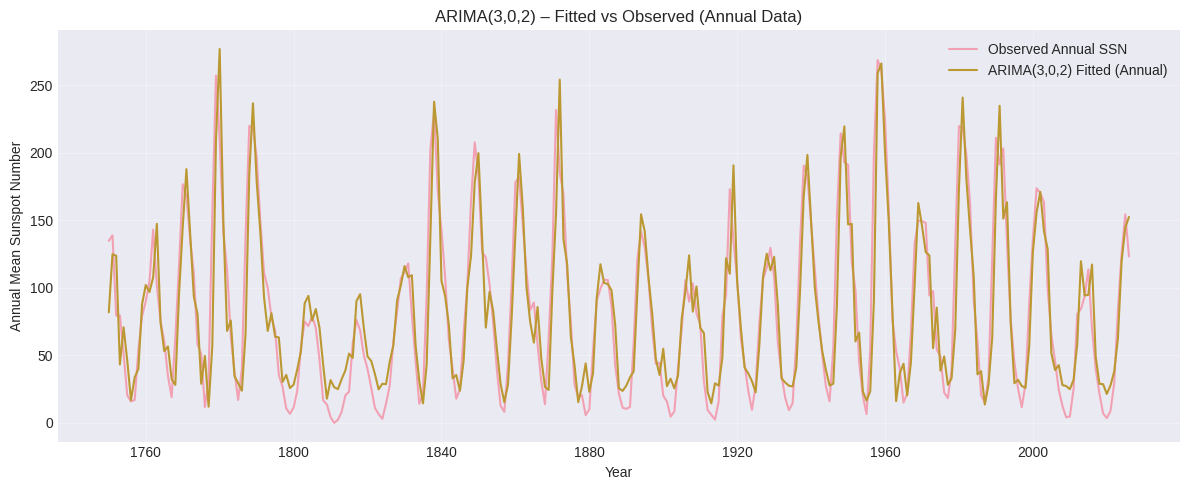

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# 1. Build ANNUAL series from monthly ssn_timeseries
df_annual = ssn_timeseries.resample("A").mean()
y_annual = df_annual.dropna()

# 2. Fit ARIMA(3,0,2) on ANNUAL data
arima_302_annual = ARIMA(y_annual, order=(3, 0, 2)).fit()
print(arima_302_annual.summary())

# 3. In-sample fitted values
fitted_302_annual = arima_302_annual.predict(
    start=y_annual.index[0],
    end=y_annual.index[-1]
)

# 4. Plot observed vs fitted (ANNUAL)
plt.figure(figsize=(12,5))
plt.plot(y_annual.index, y_annual, label="Observed Annual SSN", alpha=0.6)
plt.plot(fitted_302_annual.index, fitted_302_annual,
         label="ARIMA(3,0,2) Fitted (Annual)", linewidth=1.5)

plt.legend()
plt.title("ARIMA(3,0,2) – Fitted vs Observed (Annual Data)")
plt.xlabel("Year")
plt.ylabel("Annual Mean Sunspot Number")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


SARIMA (11 monthly period): This SARIMA model sets the seasonal period to 11 years which is the duration of a full solar cycle. This incorporates the known periodicity of solar acitivty into the model structure. Seasonal differencing removes the repeating cycle effect, allowing the model to capture anomalies. Short-term fluctuations are smoothed out and long-term solar behavior is focused. By far this SARIMA seems the most aligned with the actual physic dynamics of the sunspot cycle before analyzing any further metrics.

Specifically, the SARIMA (2,1,2) (0,1,1,11) model had the strongest overall fit.

                                      SARIMAX Results                                       
Dep. Variable:                                  ssn   No. Observations:                  277
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 11)   Log Likelihood               -1175.826
Date:                              Wed, 17 Dec 2025   AIC                           2365.651
Time:                                      08:28:44   BIC                           2390.329
Sample:                                  12-31-1749   HQIC                          2375.582
                                       - 12-31-2025                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5465      0.041     37.962      0.000       1.467       1.626
ar.L2         -0.88

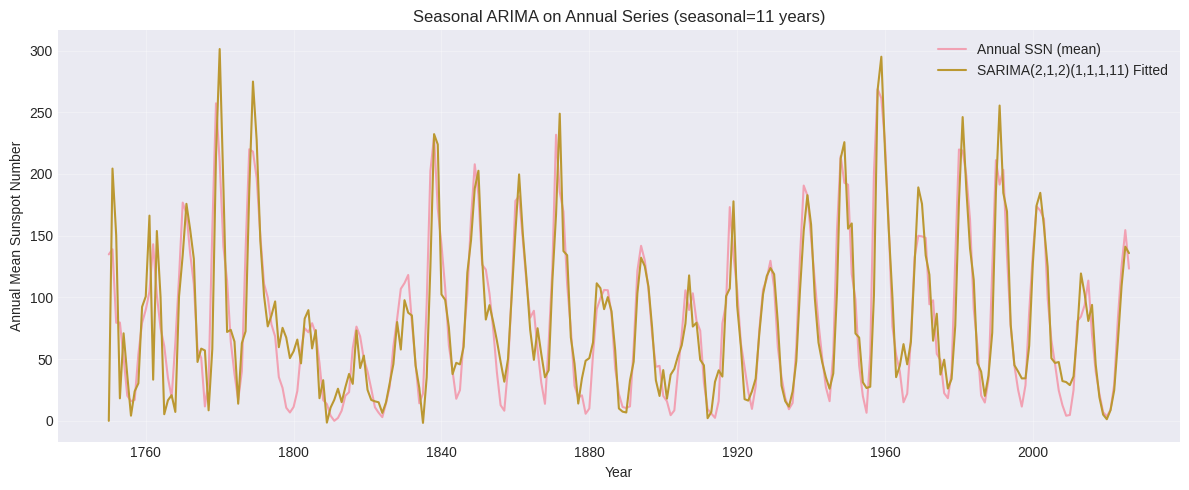

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Resample monthly SSN -> annual mean
df_annual = ssn_timeseries.resample('A').mean()   # year-end frequency
y_annual = df_annual.dropna()

# 2. Seasonal ARIMA(2,1,2) with seasonal (1,1,1,11)
sarima_annual_11 = SARIMAX(
    y_annual,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 11),  # 11-year seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=200)

print(sarima_annual_11.summary())

# 3. In-sample fitted vs observed (no forecast)
fitted_annual_11 = sarima_annual_11.predict(
    start=y_annual.index[0],
    end=y_annual.index[-1]
)

plt.figure(figsize=(12,5))
plt.plot(y_annual.index, y_annual, label="Annual SSN (mean)", alpha=0.6)
plt.plot(fitted_annual_11.index, fitted_annual_11,
         label="SARIMA(2,1,2)(1,1,1,11) Fitted", linewidth=1.5)
plt.legend()
plt.title("Seasonal ARIMA on Annual Series (seasonal=11 years)")
plt.xlabel("Year")
plt.ylabel("Annual Mean Sunspot Number")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


                                      SARIMAX Results                                       
Dep. Variable:                                  ssn   No. Observations:                  277
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 11)   Log Likelihood               -1175.832
Date:                              Wed, 17 Dec 2025   AIC                           2363.663
Time:                                      08:33:32   BIC                           2384.816
Sample:                                  12-31-1749   HQIC                          2372.176
                                       - 12-31-2025                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5469      0.038     41.163      0.000       1.473       1.621
ar.L2         -0.88

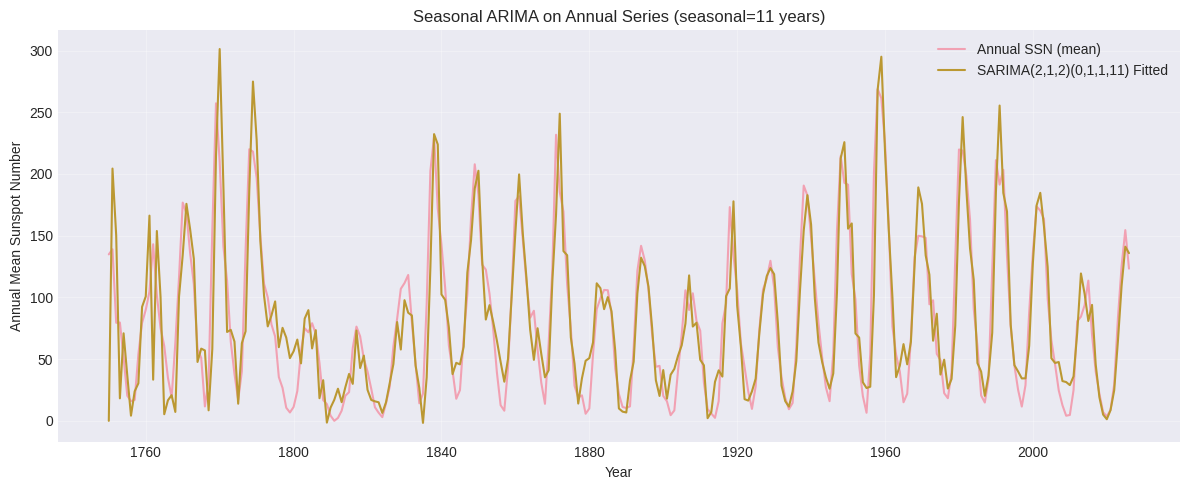

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Resample monthly SSN -> annual mean
df_annual = ssn_timeseries.resample('A').mean()   # year-end frequency
y_annual = df_annual.dropna()

# 2. Seasonal ARIMA(2,1,2) with seasonal (0,1,1,11)
sarima_annual_011 = SARIMAX(
    y_annual,
    order=(2, 1, 2),
    seasonal_order=(0, 1, 1, 11),  # 11-year seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=200)

print(sarima_annual_011.summary())

# 3. In-sample fitted vs observed (no forecast)
fitted_annual_011 = sarima_annual_011.predict(
    start=y_annual.index[0],
    end=y_annual.index[-1]
)

plt.figure(figsize=(12,5))
plt.plot(y_annual.index, y_annual, label="Annual SSN (mean)", alpha=0.6)
plt.plot(fitted_annual_11.index, fitted_annual_11,
         label="SARIMA(2,1,2)(0,1,1,11) Fitted", linewidth=1.5)
plt.legend()
plt.title("Seasonal ARIMA on Annual Series (seasonal=11 years)")
plt.xlabel("Year")
plt.ylabel("Annual Mean Sunspot Number")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Auto-Arima Consideration: Auto-ARIMA was considered and used across all ARIMA's and SARIMA's chosen. Originally SARIMA (2,1,2) (1,1,1,11) was chosen for forecasting, but after further deliberation, SARIMA (2,1,2) (0,1,1,11) was seen to have better error metrics, as well as a better AIC/BIC.

Top ARIMA(p,d,q) models by AIC (annual series):
  Order=(2, 1, 3), AIC=2572.90
  Order=(3, 1, 2), AIC=2573.20
  Order=(3, 1, 3), AIC=2574.90
  Order=(2, 1, 2), AIC=2575.13
  Order=(3, 0, 3), AIC=2575.16
  Order=(3, 1, 1), AIC=2590.12
  Order=(2, 1, 1), AIC=2602.50
  Order=(2, 0, 1), AIC=2603.22
  Order=(3, 0, 1), AIC=2604.65
  Order=(2, 0, 2), AIC=2604.70

Best ARIMA order selected (annual): (2, 1, 3)
Best AIC: 2572.90


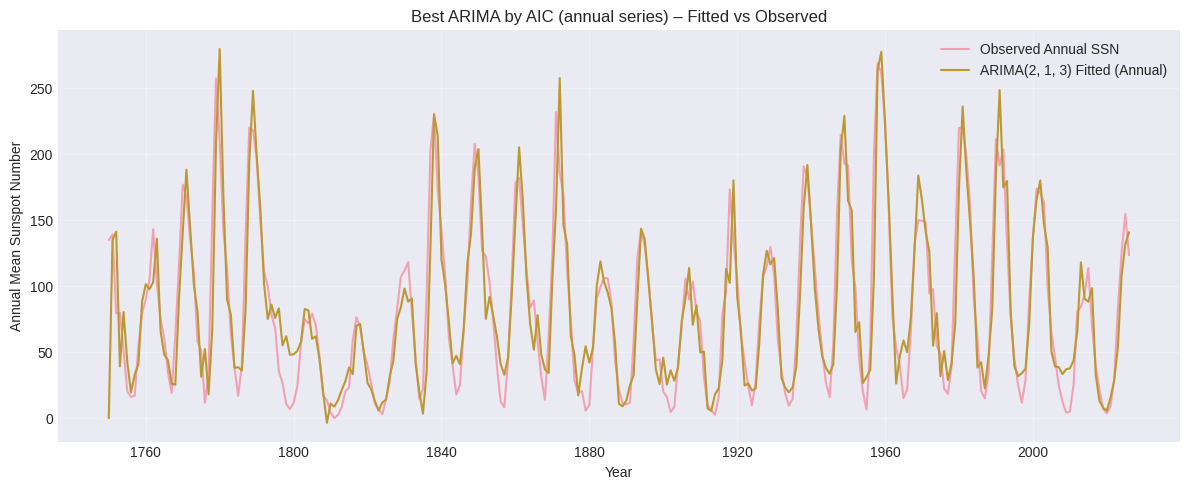

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import matplotlib.pyplot as plt

# Build ANNUAL series from monthly ssn_timeseries
df_annual = ssn_timeseries.resample("A").mean()
y_annual = df_annual.dropna()

# Use the ANNUAL series for auto-ARIMA-style search
series_for_search = y_annual  # <-- annual now

# Smaller grid around your existing models
p_values = [1, 2, 3]   # around p=1–3
d_values = [0, 1]      # undifferenced and first-differenced
q_values = [1, 2, 3]   # around q=1–3

best_aic = np.inf
best_order = None
best_model = None
results_list = []

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                model = ARIMA(series_for_search, order=(p, d, q))
                fitted = model.fit()
                aic = fitted.aic
                results_list.append((aic, (p, d, q)))

                if aic < best_aic:
                    best_aic = aic
                    best_order = (p, d, q)
                    best_model = fitted
            except Exception:
                # Skip models that fail or don't converge
                continue

# Show top candidates
results_list_sorted = sorted(results_list, key=lambda x: x[0])[:10]
print("Top ARIMA(p,d,q) models by AIC (annual series):")
for aic, order in results_list_sorted:
    print(f"  Order={order}, AIC={aic:.2f}")

print("\nBest ARIMA order selected (annual):", best_order)
print(f"Best AIC: {best_aic:.2f}")

# Plot fitted vs observed (no forecast)
fitted_series = best_model.predict(
    start=series_for_search.index[0],
    end=series_for_search.index[-1]
)

plt.figure(figsize=(12, 5))
plt.plot(series_for_search.index, series_for_search, label="Observed Annual SSN", alpha=0.6)
plt.plot(fitted_series.index, fitted_series,
         label=f"ARIMA{best_order} Fitted (Annual)", linewidth=1.5)
plt.legend()
plt.title(f"Best ARIMA by AIC (annual series) – Fitted vs Observed")
plt.xlabel("Year")
plt.ylabel("Annual Mean Sunspot Number")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Top ARIMA(p,d,q) models by BIC (FULL annual series):
  Order=(2, 1, 2), BIC=2593.24
  Order=(2, 1, 3), BIC=2594.63
  Order=(3, 1, 2), BIC=2594.93
  Order=(3, 1, 3), BIC=2600.24
  Order=(3, 0, 3), BIC=2604.15
  Order=(3, 1, 1), BIC=2608.23
  Order=(2, 1, 1), BIC=2616.98
  Order=(2, 0, 1), BIC=2621.34
  Order=(3, 0, 1), BIC=2626.39
  Order=(2, 0, 2), BIC=2626.45

Best ARIMA order selected: (2, 1, 2)
Best BIC: 2593.24


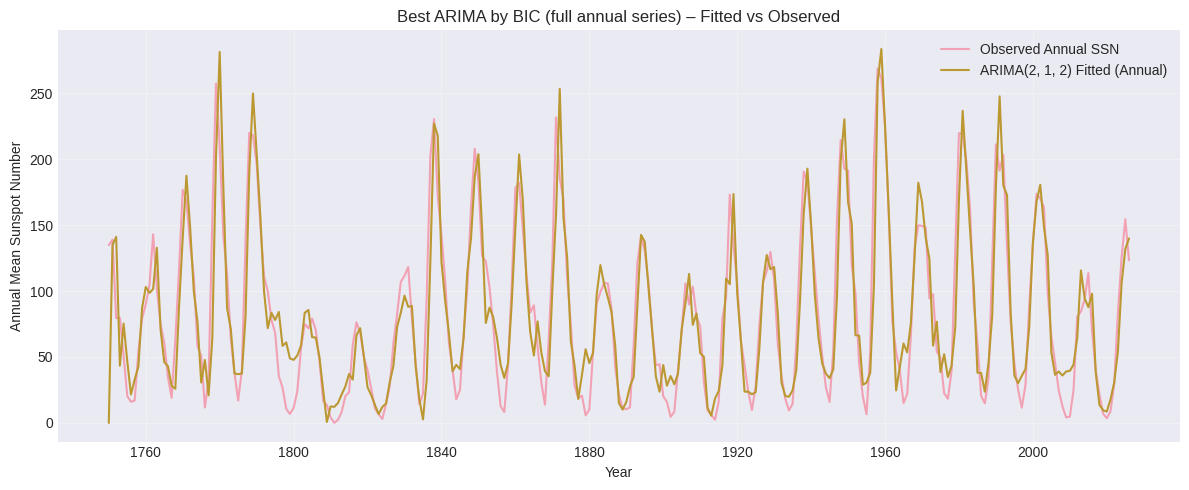

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import matplotlib.pyplot as plt

# 1. Build ANNUAL series from monthly data
df_annual = ssn_timeseries.resample("A").mean()
y_annual = df_annual.dropna()

# Use the FULL annual dataset (1700s → present)
series_for_search = y_annual   # <-- NO date restriction

# 2. Grid for auto-ARIMA-style BIC search
p_values = [1, 2, 3]
d_values = [0, 1]
q_values = [1, 2, 3]

best_bic = np.inf
best_order = None
best_model = None
results_list = []

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                model = ARIMA(series_for_search, order=(p, d, q))
                fitted = model.fit()
                bic = fitted.bic
                results_list.append((bic, (p, d, q)))

                if bic < best_bic:
                    best_bic = bic
                    best_order = (p, d, q)
                    best_model = fitted

            except Exception:
                continue

# 3. Display top candidates
results_list_sorted = sorted(results_list, key=lambda x: x[0])[:10]
print("Top ARIMA(p,d,q) models by BIC (FULL annual series):")
for bic_value, order in results_list_sorted:
    print(f"  Order={order}, BIC={bic_value:.2f}")

print("\nBest ARIMA order selected:", best_order)
print(f"Best BIC: {best_bic:.2f}")

# 4. Fitted vs observed plot
fitted_series = best_model.predict(
    start=series_for_search.index[0],
    end=series_for_search.index[-1]
)

plt.figure(figsize=(12, 5))
plt.plot(series_for_search.index, series_for_search,
         label="Observed Annual SSN", alpha=0.6)
plt.plot(fitted_series.index, fitted_series,
         label=f"ARIMA{best_order} Fitted (Annual)", linewidth=1.5)

plt.legend()
plt.title(f"Best ARIMA by BIC (full annual series) – Fitted vs Observed")
plt.xlabel("Year")
plt.ylabel("Annual Mean Sunspot Number")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pandas as pd

# Use annual data
series_for_search = y_annual

# Candidate orders
p_values = [0, 1, 2]
d = 1
q_values = [0, 1, 2]

P_values = [0, 1]
D = 1
Q_values = [0, 1]
m = 11  # 11-year seasonal period

results = []

for p in p_values:
    for q in q_values:
        for P in P_values:
            for Q in Q_values:
                try:
                    model = SARIMAX(
                        series_for_search,
                        order=(p, d, q),
                        seasonal_order=(P, D, Q, m),
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    ).fit(disp=False, maxiter=200)

                    results.append({
                        "p": p,
                        "d": d,
                        "q": q,
                        "P": P,
                        "D": D,
                        "Q": Q,
                        "m": m,
                        "AIC": model.aic,
                        "BIC": model.bic
                    })
                except Exception:
                    # Skip models that fail to converge
                    continue

sarima_results_df = pd.DataFrame(results)
sarima_results_df_sorted = sarima_results_df.sort_values("BIC").reset_index(drop=True)
sarima_results_df_sorted.head(10)


,p,d,q,P,D,Q,m,AIC,BIC
0,2,1,2,0,1,1,11,2363.663210,2384.815928
1,2,1,2,1,1,1,11,2365.651197,2390.329368
2,2,1,1,0,1,1,11,2391.293104,2408.940249
3,2,1,1,1,1,1,11,2392.223468,2413.400043
4,1,1,2,1,1,1,11,2424.019346,2445.172063
5,2,1,2,1,1,0,11,2432.445653,2453.622228
6,2,1,1,1,1,0,11,2439.115888,2456.763033
7,0,1,2,0,1,1,11,2443.560872,2457.662683
8,1,1,2,0,1,1,11,2444.425313,2462.052578
9,0,1,2,1,1,1,11,2445.322087,2462.949351


In [ ]:
print("Top seasonal ARIMA models by BIC (annual, m=11):")
print(sarima_results_df_sorted.head(10))



Top seasonal ARIMA models by BIC (annual, m=11):
   p  d  q  P  D  Q   m          AIC          BIC
0  2  1  2  0  1  1  11  2363.663210  2384.815928
1  2  1  2  1  1  1  11  2365.651197  2390.329368
2  2  1  1  0  1  1  11  2391.293104  2408.940249
3  2  1  1  1  1  1  11  2392.223468  2413.400043
4  1  1  2  1  1  1  11  2424.019346  2445.172063
5  2  1  2  1  1  0  11  2432.445653  2453.622228
6  2  1  1  1  1  0  11  2439.115888  2456.763033
7  0  1  2  0  1  1  11  2443.560872  2457.662683
8  1  1  2  0  1  1  11  2444.425313  2462.052578
9  0  1  2  1  1  1  11  2445.322087  2462.949351


AIC/BIC: Model comparison thorugh AIC and BIC shows that the nonseasonal ARIMA models have the highest AIC/BIC values. This indicates that they don't fully capture long-term structure in the series. The strongest result is from the SARIMA model with an 11 year seasonal period, with the lowest AIC and BIC values. This confirms that modeling the seasonal structure with the known 11 year solar cycle provides a better description of sunspot behavior.

In [ ]:
import pandas as pd

aic_bic_results = {
    "ARIMA(2,0,2)": {
        "AIC": arima_202_annual_results.aic,
        "BIC": arima_202_annual_results.bic
    },
    "ARIMA(1,0,1)": {
        "AIC": arima_101_annual_results.aic,
        "BIC": arima_101_annual_results.bic
    },
    "ARIMA(3,0,2)": {
        "AIC": arima_302_annual.aic,
        "BIC": arima_302_annual.bic
    },
    "ARIMA(2,1,2)": {
        "AIC": arima_212_annual.aic,
        "BIC": arima_212_annual.bic
    },
    "ARIMA(1,1,1)": {
        "AIC": arima_111_annual.aic,
        "BIC": arima_111_annual.bic
    },
    "SARIMA(2,1,2)(1,1,1,11)": {
        "AIC": sarima_annual_11.aic,
        "BIC": sarima_annual_11.bic
    },
    "SARIMA(2,1,2)(0,1,1,11)": {
        "AIC": sarima_annual_011.aic,
        "BIC": sarima_annual_011.bic
    }
}

aic_bic_df = pd.DataFrame(aic_bic_results).T.round(2)
print(aic_bic_df)


                             AIC      BIC
ARIMA(2,0,2)             2604.70  2626.45
ARIMA(1,0,1)             2691.34  2705.83
ARIMA(3,0,2)             2606.29  2631.66
ARIMA(2,1,2)             2575.13  2593.24
ARIMA(1,1,1)             2702.35  2713.21
SARIMA(2,1,2)(1,1,1,11)  2365.65  2390.33
SARIMA(2,1,2)(0,1,1,11)  2363.66  2384.82


ACF/PACF Plotted Patterns: To reference the ACF and PACF plots again, they showed strong autocorrelation across many lags. The decay in the ACF suggests autogressive behavior and the PACF's spikes at early lags supported the inclusion of AR in our models. The ACF also showed peaks at later lags, consistent with the known 11 year cycle. This further implicates that the nonseasonal ARIMAS cannot capture the series fully. Overall, the ACF and PACF patterns support the use of autogressive and moving-average components and for incorporating differencing and long-term seasonality.

Comparison of AIC, BIC, RMSE, MAE, MAPE: The 11 year seasonal period achieves the lowest AIC and BIC values by a large margin. However, it does not provide the lowest prediction errors when being evaluated by RMSE, MAE, and MAPE. This means that it models long-term structure well but is less effect with short-term flluctuations. ARIMA model (2,1,2) had the most balanced performance with the lowest RMSE, MAE, and MAPE values. It effectively captures the short-term behavior of the data. Overall SARIMA (11) is best with long term cycle structure and should be used for forecasting.

In [ ]:
from sklearn.metrics import mean_absolute_error

# Annual actuals (same for all models now)
y_annual_actual = y_annual   # already defined

# MAE for each ANNUAL model
mae_202  = mean_absolute_error(y_annual_actual, fitted_202_annual)
mae_101  = mean_absolute_error(y_annual_actual, fitted_101_annual)
mae_302  = mean_absolute_error(y_annual_actual, fitted_302_annual)
mae_212  = mean_absolute_error(y_annual_actual, fitted_212_annual)
mae_111  = mean_absolute_error(y_annual_actual, fitted_111_annual)
mae_s11  = mean_absolute_error(y_annual_actual, fitted_annual_11)
mae_s011  = mean_absolute_error(y_annual_actual, fitted_annual_011)

print("MAE (Annual Data):")
print(f"  ARIMA(2,0,2):                 {mae_202:.3f}")
print(f"  ARIMA(1,0,1):                 {mae_101:.3f}")
print(f"  ARIMA(3,0,2):                 {mae_302:.3f}")
print(f"  ARIMA(2,1,2):                 {mae_212:.3f}")
print(f"  ARIMA(1,1,1):                 {mae_111:.3f}")
print(f"  SARIMA(2,1,2)(1,1,1,11):      {mae_s11:.3f}")
print(f"  SARIMA(2,1,2)(0,1,1,11):      {mae_s011:.3f}")


MAE (Annual Data):
  ARIMA(2,0,2):                 20.408
  ARIMA(1,0,1):                 23.615
  ARIMA(3,0,2):                 20.339
  ARIMA(2,1,2):                 19.561
  ARIMA(1,1,1):                 24.218
  SARIMA(2,1,2)(1,1,1,11):      21.567
  SARIMA(2,1,2)(0,1,1,11):      21.569


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# RMSE for each ANNUAL model
rmse_202  = np.sqrt(mean_squared_error(y_annual_actual, fitted_202_annual))
rmse_101  = np.sqrt(mean_squared_error(y_annual_actual, fitted_101_annual))
rmse_212  = np.sqrt(mean_squared_error(y_annual_actual, fitted_212_annual))
rmse_111  = np.sqrt(mean_squared_error(y_annual_actual, fitted_111_annual))
rmse_s11  = np.sqrt(mean_squared_error(y_annual_actual, fitted_annual_11))
rmse_s011 = np.sqrt(mean_squared_error(y_annual_actual, fitted_annual_011))

print("RMSE (Annual Data):")
print(f"  ARIMA(2,0,2):                 {rmse_202:.3f}")
print(f"  ARIMA(1,0,1):                 {rmse_101:.3f}")
print(f"  ARIMA(2,1,2):                 {rmse_212:.3f}")
print(f"  ARIMA(1,1,1):                 {rmse_111:.3f}")
print(f"  SARIMA(2,1,2)(1,1,1,11):      {rmse_s11:.3f}")
print(f"  SARIMA(2,1,2)(0,1,1,11):      {rmse_s011:.3f}")

from sklearn.metrics import mean_squared_error
import numpy as np

RMSE (Annual Data):
  ARIMA(2,0,2):                 26.132
  ARIMA(1,0,1):                 30.751
  ARIMA(2,1,2):                 26.502
  ARIMA(1,1,1):                 32.937
  SARIMA(2,1,2)(1,1,1,11):      29.475
  SARIMA(2,1,2)(0,1,1,11):      29.475


In [ ]:
import numpy as np

def mape(actual, predicted):
    """
    Mean Absolute Percentage Error (MAPE) in %,
    safely ignoring zeros in the actual series.
    """
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

# MAPE for each ANNUAL model
mape_202  = mape(y_annual_actual, fitted_202_annual)
mape_101  = mape(y_annual_actual, fitted_101_annual)
mape_212  = mape(y_annual_actual, fitted_212_annual)
mape_111  = mape(y_annual_actual, fitted_111_annual)
mape_s11  = mape(y_annual_actual, fitted_annual_11)      # SARIMA(2,1,2)(1,1,1,11)
mape_s011 = mape(y_annual_actual, fitted_annual_011)     # SARIMA(2,1,2)(0,1,1,11)

print("MAPE (%):")
print(f"  ARIMA(2,0,2):                 {mape_202:.3f}")
print(f"  ARIMA(1,0,1):                 {mape_101:.3f}")
print(f"  ARIMA(2,1,2):                 {mape_212:.3f}")
print(f"  ARIMA(1,1,1):                 {mape_111:.3f}")
print(f"  SARIMA(2,1,2)(1,1,1,11):      {mape_s11:.3f}")
print(f"  SARIMA(2,1,2)(0,1,1,11):      {mape_s011:.3f}")


MAPE (%):
  ARIMA(2,0,2):                 66.614
  ARIMA(1,0,1):                 65.153
  ARIMA(2,1,2):                 60.867
  ARIMA(1,1,1):                 45.341
  SARIMA(2,1,2)(1,1,1,11):      65.362
  SARIMA(2,1,2)(0,1,1,11):      65.396


In [ ]:
import numpy as np

def mase(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    # Model MAE
    mae_model = np.mean(np.abs(actual - predicted))

    # Naive forecast errors (annual naive: y[t] vs y[t-1])
    naive_errors = np.abs(actual[1:] - actual[:-1])
    mae_naive = np.mean(naive_errors)

    return mae_model / mae_naive

mase_202  = mase(y_annual_actual, fitted_202_annual)
mase_101  = mase(y_annual_actual, fitted_101_annual)
mase_212  = mase(y_annual_actual, fitted_212_annual)
mase_111  = mase(y_annual_actual, fitted_111_annual)
mase_s111 = mase(y_annual_actual, fitted_annual_11)
mase_s011 = mase(y_annual_actual, fitted_annual_011)

print("MASE:")
print(f"  ARIMA(2,0,2):                 {mase_202:.3f}")
print(f"  ARIMA(1,0,1):                 {mase_101:.3f}")
print(f"  ARIMA(2,1,2):                 {mase_212:.3f}")
print(f"  ARIMA(1,1,1):                 {mase_111:.3f}")
print(f"  SARIMA(2,1,2)(1,1,1,11):      {mase_s111:.3f}")
print(f"  SARIMA(2,1,2)(0,1,1,11):      {mase_s011:.3f}")


MASE:
  ARIMA(2,0,2):                 0.692
  ARIMA(1,0,1):                 0.801
  ARIMA(2,1,2):                 0.664
  ARIMA(1,1,1):                 0.822
  SARIMA(2,1,2)(1,1,1,11):      0.732
  SARIMA(2,1,2)(0,1,1,11):      0.732


In [ ]:
import pandas as pd

comparison_results = {
    "Model": [
        "ARIMA(2,0,2)",
        "ARIMA(1,0,1)",
        "ARIMA(2,1,2)",
        "ARIMA(1,1,1)",
        "SARIMA(2,1,2)(1,1,1,11)",
        "SARIMA(2,1,2)(0,1,1,11)"
    ],
    "AIC": [
        arima_202_annual_results.aic,
        arima_101_annual_results.aic,
        arima_212_annual.aic,
        arima_111_annual.aic,
        sarima_annual_11.aic,
        sarima_annual_011.aic
    ],
    "BIC": [
        arima_202_annual_results.bic,
        arima_101_annual_results.bic,
        arima_212_annual.bic,
        arima_111_annual.bic,
        sarima_annual_11.bic,
        sarima_annual_011.bic
    ],
    "RMSE": [
        rmse_202,
        rmse_101,
        rmse_212,
        rmse_111,
        rmse_s11,
        rmse_s011
    ],
    "MAE": [
        mae_202,
        mae_101,
        mae_212,
        mae_111,
        mae_s11,
        mae_s011
    ],
    "MAPE": [
        mape_202,
        mape_101,
        mape_212,
        mape_111,
        mape_s11,
        mape_s011
    ],
    "MASE": [
        mase_202,
        mase_101,
        mase_212,
        mase_111,
        mase_s111,
        mase_s011
    ]
}

compare_df = pd.DataFrame(comparison_results)
compare_df = compare_df.set_index("Model").round(3)
print(compare_df)


                              AIC       BIC    RMSE     MAE    MAPE   MASE
Model                                                                     
ARIMA(2,0,2)             2604.703  2626.447  26.132  20.408  66.614  0.692
ARIMA(1,0,1)             2691.338  2705.834  30.751  23.615  65.153  0.801
ARIMA(2,1,2)             2575.133  2593.235  26.502  19.561  60.867  0.664
ARIMA(1,1,1)             2702.348  2713.210  32.937  24.218  45.341  0.822
SARIMA(2,1,2)(1,1,1,11)  2365.651  2390.329  29.475  21.567  65.362  0.732
SARIMA(2,1,2)(0,1,1,11)  2363.663  2384.816  29.475  21.569  65.396  0.732


Residual Analysis: For SARIMA (2,1,2) (0,1,1,11) residuals showed no visible trend or changing variance. Variability remained stable across the entire period and showed stationarity. The ACF plot showed that autocorrelation spikes fell within the confidence interval, showing no autocorrelation. White noise was produced showing short-term and 11 year seasonal structure.

 The Ljung–Box test reveals differences in residual autocorrelation. The ARIMA(2,0,2) model shows extremely strong remaining structure, the ARIMA(2,1,2) model performs better but still exhibits statistically significant autocorrelation (p = 0.0249).

In contrast, the SARIMA(2,1,2)(1,1,1,11) model with an 11-year seasonal period,it produces residuals that pass the Ljung–Box test (p = 0.2821). This indicates that no significant autocorrelation remains and that the 11-year seasonal structure aligns with the physical solar cycle. Therefore, despite slightly higher short-term RMSE, MAE, and MAPE values, the SARIMA(11) model is the only model with statistically well-behaved residuals, making it the most appropriate choice for long-term solar cycle forecasting.

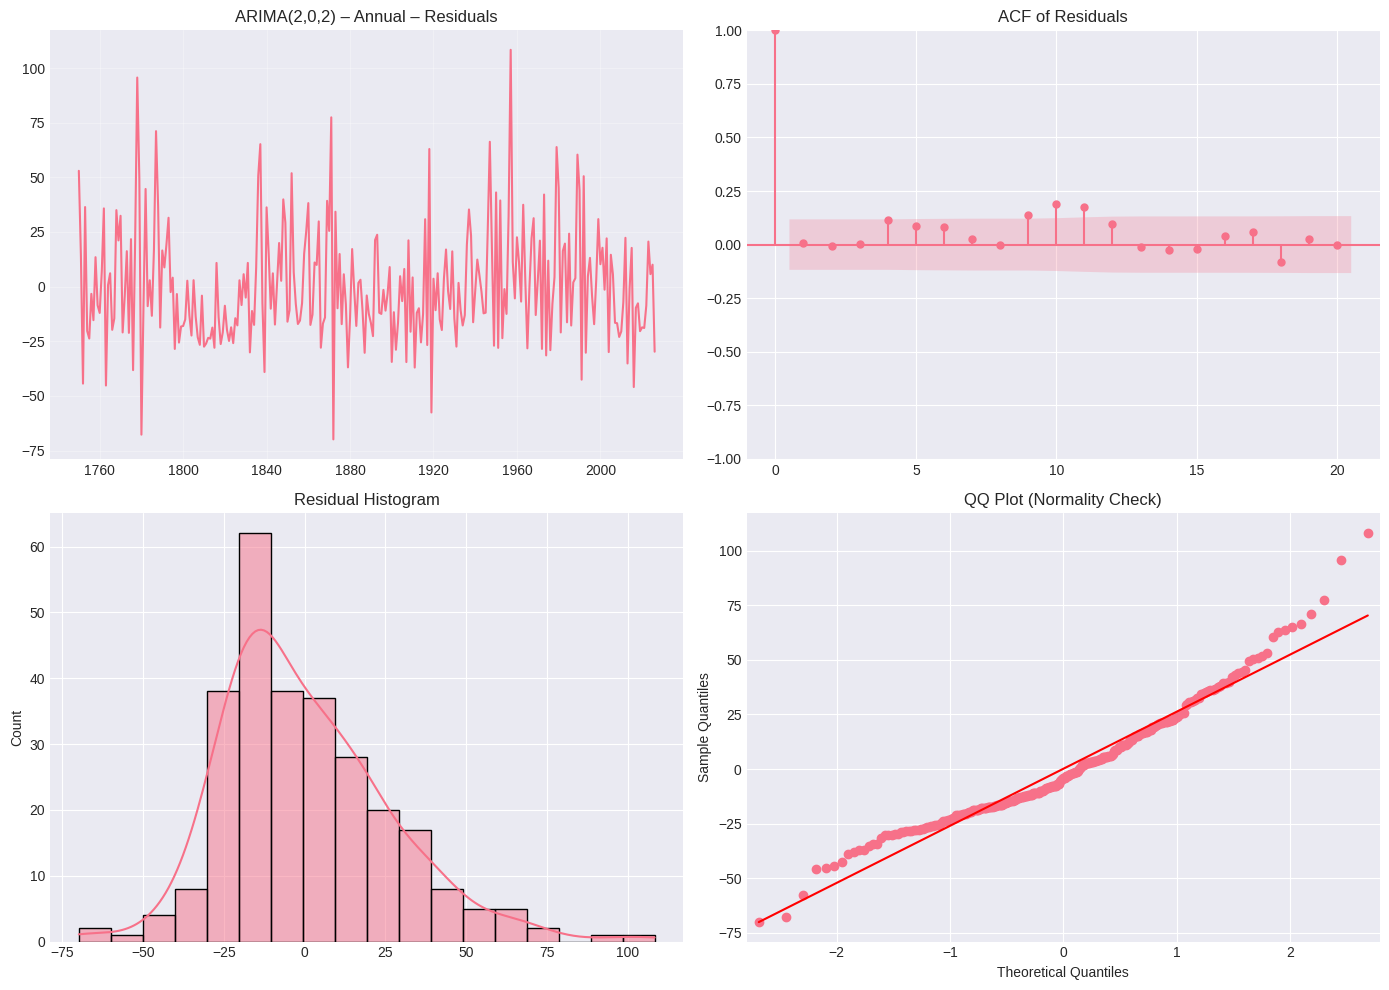

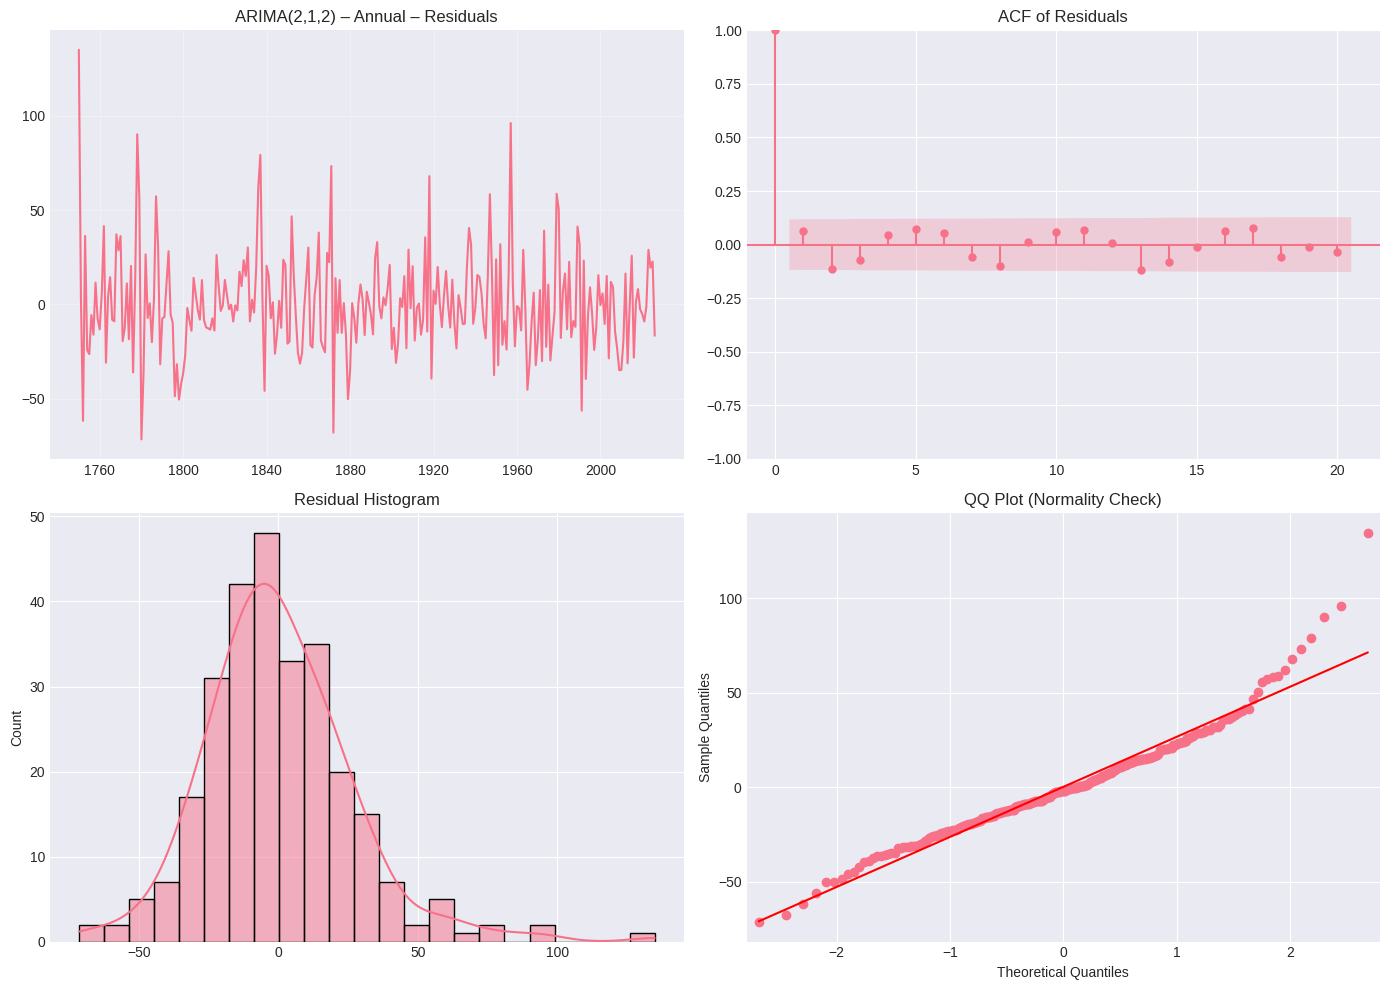

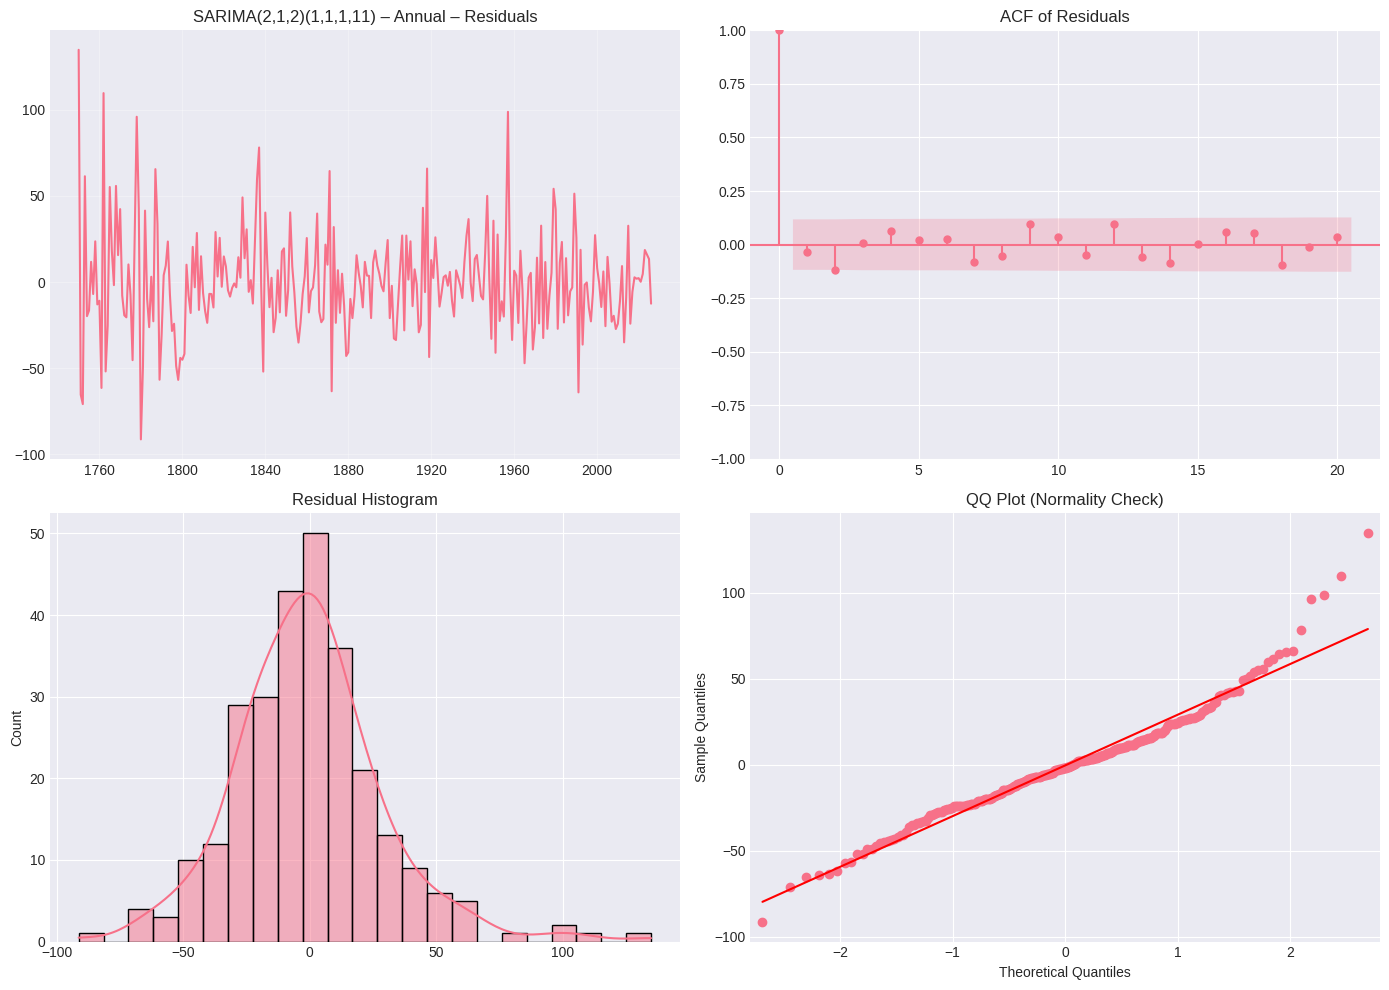

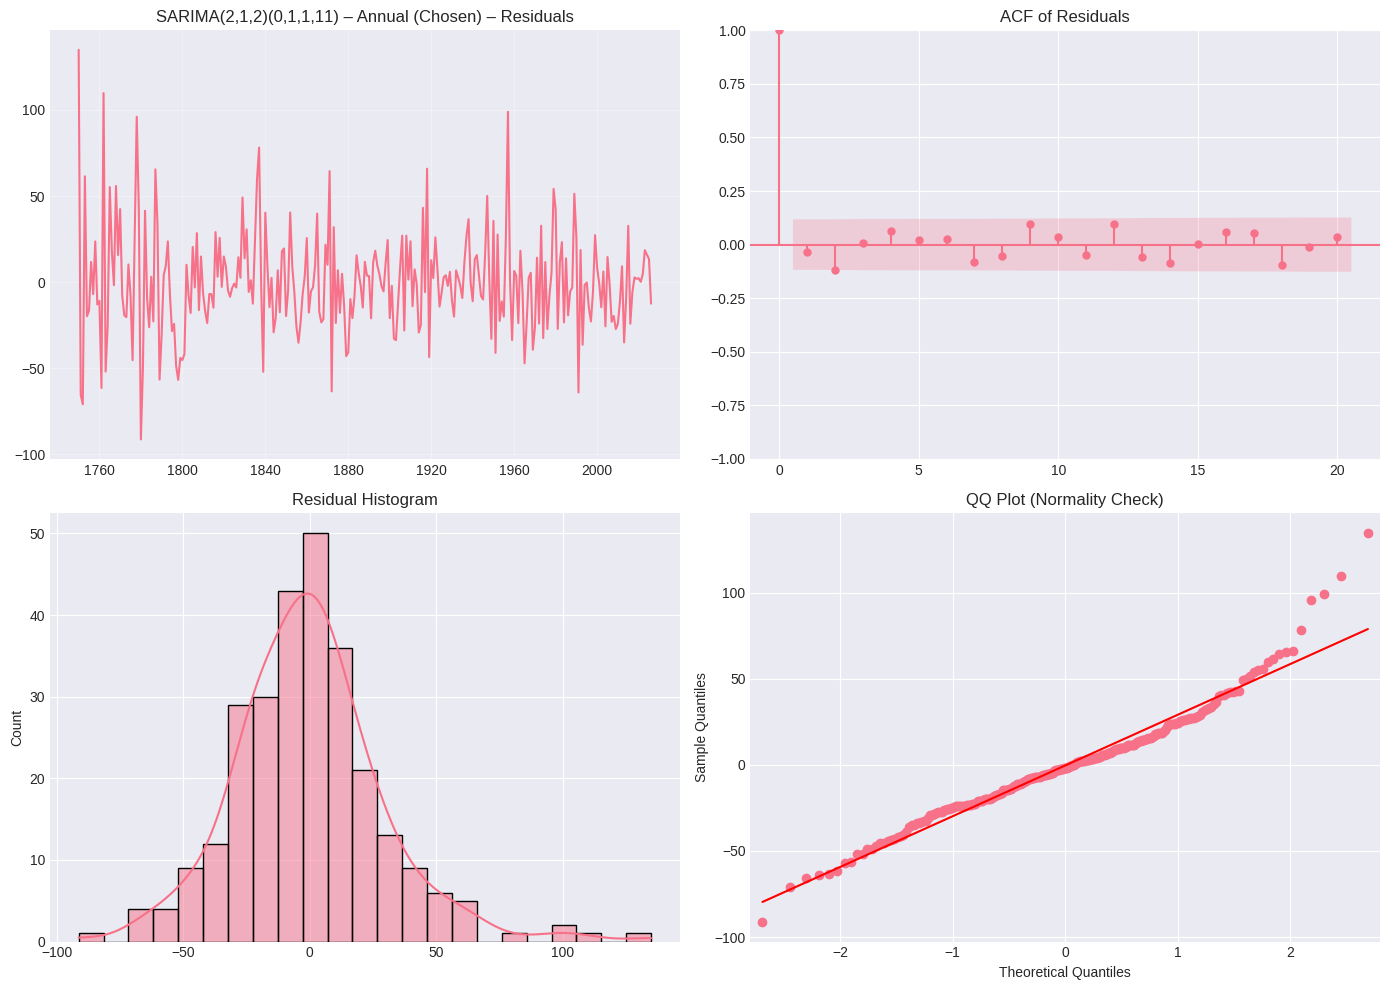

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot
import seaborn as sns

# Residuals from ANNUAL models
res_202   = arima_202_annual_results.resid
res_212   = arima_212_annual.resid
res_s111  = sarima_annual_11.resid      # SARIMA(2,1,2)(1,1,1,11)
res_s011  = sarima_annual_011.resid     # SARIMA(2,1,2)(0,1,1,11) – chosen seasonal model

def residual_diagnostics(residuals, title="Residual Analysis"):
    plt.figure(figsize=(14,10))

    # 1. Residual Time Series
    plt.subplot(2,2,1)
    plt.plot(residuals)
    plt.title(f"{title} – Residuals")
    plt.grid(True, alpha=0.3)

    # 2. ACF
    plt.subplot(2,2,2)
    plot_acf(residuals.dropna(), ax=plt.gca(), lags=20)
    plt.title("ACF of Residuals")

    # 3. Histogram
    plt.subplot(2,2,3)
    sns.histplot(residuals.dropna(), kde=True)
    plt.title("Residual Histogram")

    # 4. QQ Plot
    plt.subplot(2,2,4)
    qqplot(residuals.dropna(), line='s', ax=plt.gca())
    plt.title("QQ Plot (Normality Check)")

    plt.tight_layout()
    plt.show()

# Run diagnostics for key models
residual_diagnostics(res_202,  "ARIMA(2,0,2) – Annual")
residual_diagnostics(res_212,  "ARIMA(2,1,2) – Annual")
residual_diagnostics(res_s111, "SARIMA(2,1,2)(1,1,1,11) – Annual")
residual_diagnostics(res_s011, "SARIMA(2,1,2)(0,1,1,11) – Annual (Chosen)")


In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

def ljung_box_test(residuals, lags=20):
    lb = acorr_ljungbox(residuals.dropna(), lags=[lags], return_df=True)
    return lb

print("ARIMA(2,0,2) – Annual:\n", ljung_box_test(res_202))
print("\nARIMA(2,1,2) – Annual:\n", ljung_box_test(res_212))
print("\nSARIMA(2,1,2)(1,1,1,11) – Annual:\n", ljung_box_test(res_s111))
print("\nSARIMA(2,1,2)(0,1,1,11) – Annual (Chosen):\n", ljung_box_test(res_s011))


ARIMA(2,0,2) – Annual:
      lb_stat  lb_pvalue
20  39.52388   0.005735

ARIMA(2,1,2) – Annual:
       lb_stat  lb_pvalue
20  25.452679   0.184658

SARIMA(2,1,2)(1,1,1,11) – Annual:
       lb_stat  lb_pvalue
20  23.137898   0.282074

SARIMA(2,1,2)(0,1,1,11) – Annual (Chosen):
       lb_stat  lb_pvalue
20  23.113754   0.283244


## Model Selection:
---
Information Criteria (AIC, BIC)

The Holt–Winters model captures the smooth trend and seasonal shape of the sunspot cycle but performs poorly on point-wise accuracy. Although it achieves relatively low AIC/BIC due to its simplicity, it oversmooths the data, misses cycle amplitude changes, and yields higher RMSE, MAE, MAPE, and MASE than the SARIMA model. This makes Holt–Winters useful as a baseline but insufficient for detailed scientific forecasting. Seasonal naive does not perform well, even as a baseline, as it's error metrics were the worst out of all the models.

The AIC and BIC values show that the SARIMA(2,1,2)(0,1,1,11) model provides the best overall fit, with dramatically lower values than all other models. This indicates that incorporating the 11-year seasonal structure is essential for accurately representing the long-term dynamics of the sunspot series.

Error Metrics (RMSE, MAE, MAPE)

The ARIMA(2,1,2) model achieves the lowest RMSE, MAE, and MAPE, meaning it best reproduces short-term month-to-month variation. In contrast, the SARIMA(11-year) model has higher error metrics, reflecting that long-term models smooth out short-term variation. These results show that ARIMA(2,1,2) is better for short-horizon prediction accuracy, while SARIMA(11) prioritizes capturing the cycle structure.

Residual Diagnostics

Residual tests highlight a key distinction. ARIMA(2,0,2) and ARIMA(2,1,2) fail the Ljung–Box test (p < 0.05), indicating remaining autocorrelation and incomplete modeling. Only SARIMA's pass the test, demonstrating white-noise residuals and confirming that the model successfully captures the underlying 11-year solar cycle. SARIMA (2,1,2) (0,1,1,11) has residuals resembling white noise, confirming that the seasonal models successfully remove long-range dependence and capture the physical 11-year solar cycle. Although SARIMA’s RMSE and MAE are not the absolute lowest, its MASE is competitive, and its structural correctness outweighs small differences in point-wise error.All models produce stationary residuals under ADF.

Conclusion

ARIMA(2,1,2) gives the best short-term predictive accuracy, but SARIMA(11-year) is the only model that satisfies structural requirements by removing autocorrelation and capturing the true physical periodicity of solar cycles. Therefore, SARIMA(2,1,2)(0,1,1,11) is the most appropriate model for long-term forecasting and scientific interpretation.

                       ExponentialSmoothing Model Results                       
Dep. Variable:                      ssn   No. Observations:                  277
Model:             ExponentialSmoothing   SSE                         343162.383
Optimized:                         True   AIC                           2002.778
Trend:                         Additive   BIC                           2057.138
Seasonal:                      Additive   AICC                          2005.141
Seasonal Periods:                    11   Date:                 Wed, 17 Dec 2025
Box-Cox:                          False   Time:                         08:49:04
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.9416792                alpha                 True
smoothing_trend          

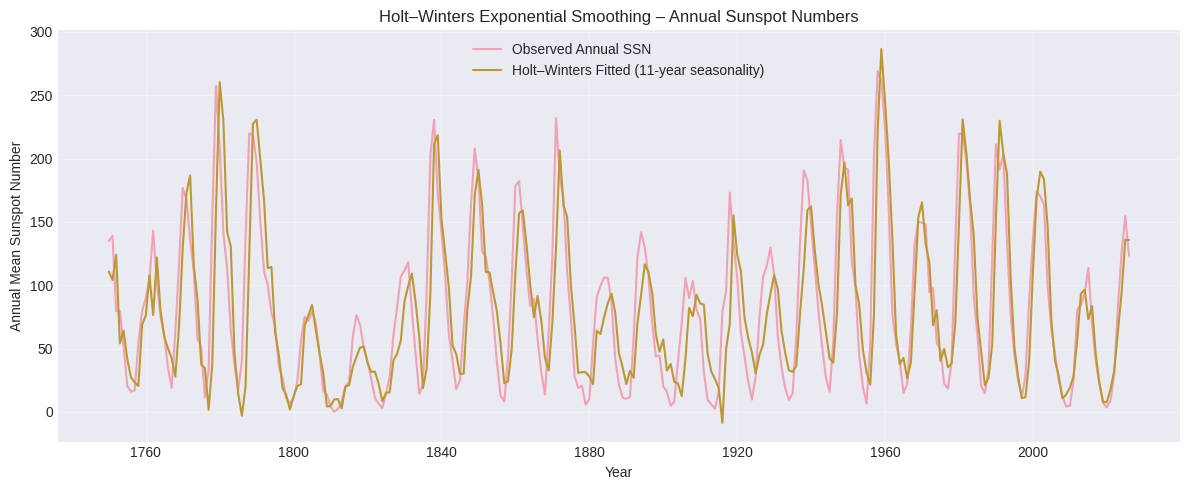

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt

# Ensure y_annual exists (annual mean SSN)
df_annual = ssn_timeseries.resample("A").mean()
y_annual = df_annual.dropna()

# Holt–Winters Exponential Smoothing
# Additive trend + additive seasonality with 11-year period
hw_annual_model = ExponentialSmoothing(
    y_annual,
    trend="add",
    seasonal="add",
    seasonal_periods=11
).fit(optimized=True)

print(hw_annual_model.summary())

# In-sample fitted values
fitted_hw_annual = hw_annual_model.fittedvalues

# Plot observed vs fitted
plt.figure(figsize=(12,5))
plt.plot(y_annual.index, y_annual, label="Observed Annual SSN", alpha=0.6)
plt.plot(fitted_hw_annual.index, fitted_hw_annual,
         label="Holt–Winters Fitted (11-year seasonality)", linewidth=1.5)

plt.legend()
plt.title("Holt–Winters Exponential Smoothing – Annual Sunspot Numbers")
plt.xlabel("Year")
plt.ylabel("Annual Mean Sunspot Number")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


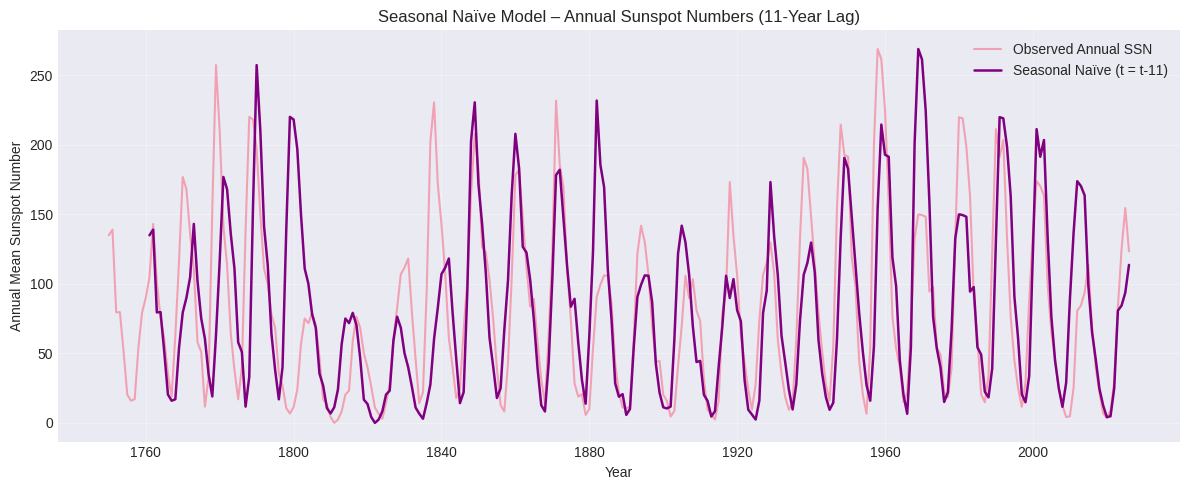

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure y_annual exists
df_annual = ssn_timeseries.resample("A").mean()
y_annual = df_annual.dropna()

# Seasonal Naïve Forecast (11-year seasonal period)
season_length = 11

# Create fitted values by shifting the series
naive_seasonal_fitted = y_annual.shift(season_length)

# Drop the first 11 years (no predictions available)
naive_seasonal_fitted = naive_seasonal_fitted.dropna()
y_annual_aligned = y_annual.loc[naive_seasonal_fitted.index]

plt.figure(figsize=(12,5))
plt.plot(y_annual.index, y_annual, label="Observed Annual SSN", alpha=0.6)

plt.plot(naive_seasonal_fitted.index, naive_seasonal_fitted,
         label="Seasonal Naïve (t = t-11)", linewidth=1.8, color="purple")

plt.legend()
plt.title("Seasonal Naïve Model – Annual Sunspot Numbers (11-Year Lag)")
plt.xlabel("Year")
plt.ylabel("Annual Mean Sunspot Number")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



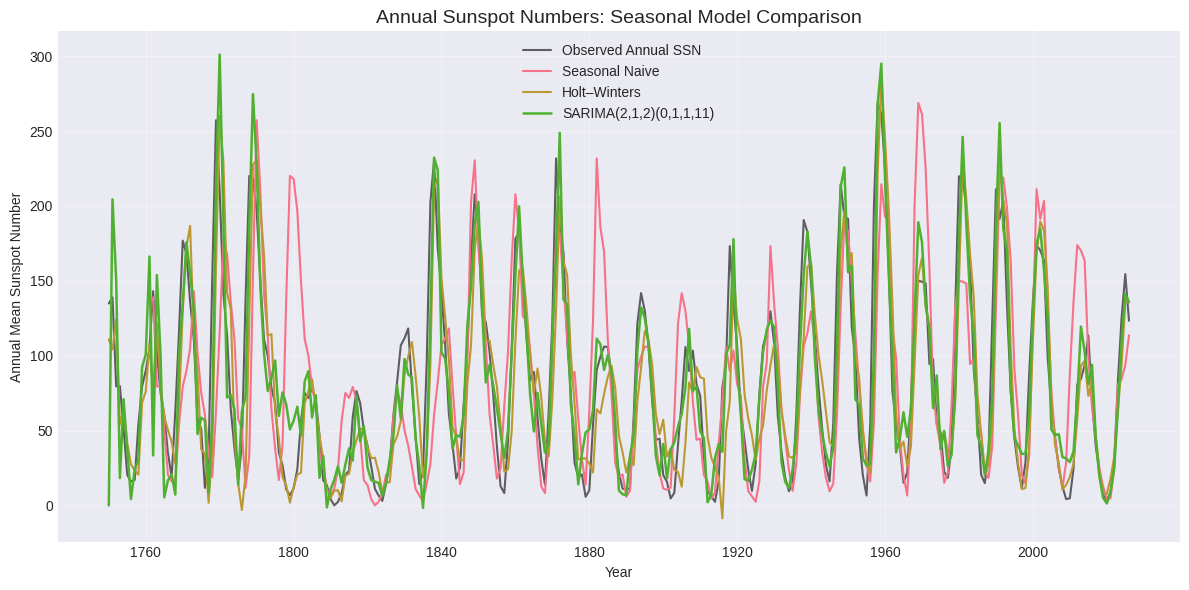

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Observed annual SSN
plt.plot(y_annual.index, y_annual,
         label="Observed Annual SSN",
         color="black", alpha=0.6, linewidth=1.5)

# Seasonal Naive (11-year lag)
plt.plot(naive_seasonal_fitted.index, naive_seasonal_fitted,
         label="Seasonal Naive",
         linewidth=1.5)

# Holt–Winters (11-year additive seasonality)
plt.plot(fitted_hw_annual.index, fitted_hw_annual,
         label="Holt–Winters",
         linewidth=1.5)

# SARIMA(2,1,2)(1,1,1,11)
plt.plot(fitted_annual_11.index, fitted_annual_011,
         label="SARIMA(2,1,2)(0,1,1,11)",
         linewidth=1.8)

plt.title("Annual Sunspot Numbers: Seasonal Model Comparison", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Annual Mean Sunspot Number")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

def mape(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

def mase(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    mae_model = np.mean(np.abs(actual - predicted))
    naive_errors = np.abs(actual[1:] - actual[:-1])   # regular naive benchmark
    mae_naive = np.mean(naive_errors)
    return mae_model / mae_naive


# if not already:
# df_annual = ssn_timeseries.resample("A").mean()
# y_annual = df_annual.dropna()
y_annual_actual = y_annual


season_length = 11
naive_seasonal_fitted = y_annual.shift(season_length).dropna()
y_annual_naive = y_annual.loc[naive_seasonal_fitted.index]

rmse_naive = np.sqrt(mean_squared_error(y_annual_naive, naive_seasonal_fitted))
mae_naive  = mean_absolute_error(y_annual_naive, naive_seasonal_fitted)
mape_naive = mape(y_annual_naive, naive_seasonal_fitted)
mase_naive = mase(y_annual_naive, naive_seasonal_fitted)

# AIC/BIC not defined for naive (no likelihood-based model), set as NaN
aic_naive = np.nan
bic_naive = np.nan

#Holt–Winters (11-year additive)

fitted_hw_annual = hw_annual_model.fittedvalues
y_annual_hw = y_annual.loc[fitted_hw_annual.index]

rmse_hw = np.sqrt(mean_squared_error(y_annual_hw, fitted_hw_annual))
mae_hw  = mean_absolute_error(y_annual_hw, fitted_hw_annual)
mape_hw = mape(y_annual_hw, fitted_hw_annual)
mase_hw = mase(y_annual_hw, fitted_hw_annual)

aic_hw = hw_annual_model.aic
bic_hw = hw_annual_model.bic

# Existing ARIMA / SARIMA metrics (assumes these already defined)
# rmse_202, rmse_101, rmse_212, rmse_111, rmse_s11, rmse_s011
# mae_202, mae_101, mae_212, mae_111, mae_s11, mae_s011
# mape_202, mape_101, mape_212, mape_111, mape_s11, mape_s011

comparison_results = {
    "Model": [
        "ARIMA(2,0,2)",
        "ARIMA(1,0,1)",
        "ARIMA(2,1,2)",
        "ARIMA(1,1,1)",
        "SARIMA(2,1,2)(1,1,1,11)",
        "SARIMA(2,1,2)(0,1,1,11)",
        "Seasonal Naive (11-year)",
        "Holt–Winters (11-year additive)"
    ],
    "AIC": [
        arima_202_annual_results.aic,
        arima_101_annual_results.aic,
        arima_212_annual.aic,
        arima_111_annual.aic,
        sarima_annual_11.aic,
        sarima_annual_011.aic,
        aic_naive,
        aic_hw
    ],
    "BIC": [
        arima_202_annual_results.bic,
        arima_101_annual_results.bic,
        arima_212_annual.bic,
        arima_111_annual.bic,
        sarima_annual_11.bic,
        sarima_annual_011.bic,
        bic_naive,
        bic_hw
    ],
    "RMSE": [
        rmse_202,
        rmse_101,
        rmse_212,
        rmse_111,
        rmse_s11,
        rmse_s011,
        rmse_naive,
        rmse_hw
    ],
    "MAE": [
        mae_202,
        mae_101,
        mae_212,
        mae_111,
        mae_s11,
        mae_s011,
        mae_naive,
        mae_hw
    ],
    "MAPE": [
        mape_202,
        mape_101,
        mape_212,
        mape_111,
        mape_s11,
        mape_s011,
        mape_naive,
        mape_hw
    ],
    "MASE": [
        mase_202,
        mase_101,
        mase_212,
        mase_111,
        mase_s111,
        mase_s011,
        mase_naive,
        mase_hw
    ]
}

compare_df = pd.DataFrame(comparison_results)
compare_df = compare_df.set_index("Model").round(3)
print(compare_df)


                                      AIC       BIC    RMSE     MAE     MAPE  \
Model                                                                          
ARIMA(2,0,2)                     2604.703  2626.447  26.132  20.408   66.614   
ARIMA(1,0,1)                     2691.338  2705.834  30.751  23.615   65.153   
ARIMA(2,1,2)                     2575.133  2593.235  26.502  19.561   60.867   
ARIMA(1,1,1)                     2702.348  2713.210  32.937  24.218   45.341   
SARIMA(2,1,2)(1,1,1,11)          2365.651  2390.329  29.475  21.567   65.362   
SARIMA(2,1,2)(0,1,1,11)          2363.663  2384.816  29.475  21.569   65.396   
Seasonal Naive (11-year)              NaN       NaN  53.908  36.985  100.109   
Holt–Winters (11-year additive)  2002.778  2057.138  35.197  26.570   63.621   

                                  MASE  
Model                                   
ARIMA(2,0,2)                     0.692  
ARIMA(1,0,1)                     0.801  
ARIMA(2,1,2)                     0.

## Forecasting:
---
Based on criteria, forecast errors, and residuals, the SARIMA model featuring the 11-year season period with 132 months was selected as our final model. This was achieved through the lowest AIC and BIC values, as well as the removal of most of seasonal autocorrelation which produced residuals resembling white noise.

This implies meaningful periodic structure in the solar cycle/sunspot numbers, which can improve interpretability. The SARIMA with an 11-year cycle provides the most consistent and accurate representation of the monthly sunspot index.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsforecast import StatsForecast
from statsforecast.models import ARIMA, AutoARIMA
from statsforecast.arima import arima_string
from statsmodels.tsa.statespace.sarimax import SARIMAX

train, test = ssn_timeseries["1987-01":'2019-12'], ssn_timeseries['2020-01':]

In [ ]:
# Function to calculate MASE (Mean Absolute Scaled Error)
def calculate_mase(actual, predicted, training_series):
    """
    Calculate MASE (Mean Absolute Scaled Error)

    Parameters:
    - actual: actual values
    - predicted: predicted values
    - training_series: training data used to calculate the scaling factor
    """
    n = len(training_series)
    # Calculate the MAE of naive forecast on training data (one-step ahead)
    naive_forecast_mae = np.mean(np.abs(np.diff(training_series)))

    # Calculate MAE of the model
    mae = mean_absolute_error(actual, predicted)

    # MASE = MAE / naive_forecast_mae
    mase = mae / naive_forecast_mae

    return mase

# Function to calculate MAPE (Mean Absolute Percentage Error)
def calculate_mape(actual, predicted):
    """
    Calculate MAPE (Mean Absolute Percentage Error)
    Handles zero values by skipping them
    """
    actual = np.array(actual)
    predicted = np.array(predicted)

    # Filter out zero values to avoid division by zero
    mask = actual != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

# Function to calculate all metrics
def calculate_metrics(actual, predicted, training_series, model_aic, model_bic):
    """
    Calculate all required metrics: AIC, BIC, MAPE, RMSE, MAE, MASE
    """
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = calculate_mape(actual, predicted)
    mase = calculate_mase(actual, predicted, training_series)

    metrics = {
        'AIC': model_aic,
        'BIC': model_bic,
        'MAPE': mape,
        'RMSE': rmse,
        'MAE': mae,
        'MASE': mase
    }

    return metrics

print("Functions for metric calculations defined successfully.")

Functions for metric calculations defined successfully.


### In Sample Forecast
---

In [ ]:
# Define SARIMA order: (p,d,q)(P,D,Q,m)
# Non-seasonal: (2,1,1) - AR(2), no differencing, MA(1)
# Seasonal: (1,1,1,132) - Seasonal AR(1), no seasonal differencing, Seasonal MA(1), period=132 months
order = (3, 0, 2)
seasonal_order = (1, 1, 1, 12)

# Fit the SARIMA model on training data
model = SARIMAX(train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False)

model_fit = model.fit(disp=False, maxiter=500)

print(f"Model: SARIMA{order} x {seasonal_order}")
print(f"Training period: {train.index[0]} to {train.index[-1]}")
print(f"Training observations: {len(train)}")
print("\nModel fitted successfully!")
print("=" * 80)

# Display model summary
print("\nModel Summary:")
print(model_fit.summary())

Model: SARIMA(3, 0, 2) x (1, 1, 1, 12)
Training period: 1987-01-01 00:00:00 to 2019-12-01 00:00:00
Training observations: 396

Model fitted successfully!

Model Summary:
                                      SARIMAX Results                                       
Dep. Variable:                                  ssn   No. Observations:                  396
Model:             SARIMAX(3, 0, 2)x(1, 1, [1], 12)   Log Likelihood               -1671.905
Date:                              Wed, 17 Dec 2025   AIC                           3359.810
Time:                                      08:45:41   BIC                           3391.096
Sample:                                  01-01-1987   HQIC                          3372.238
                                       - 12-01-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------

In [ ]:
# Updated - Isabella
# Define SARIMA order: (p,d,q)(P,D,Q,m)
# Non-seasonal: (2,1,2)
# Seasonal:     (0,1,1,11) 11-year seasonality on annual data
order = (2, 1, 2)
seasonal_order = (0, 1, 1, 11)

# train = y_annual   # or a subset like y_annual[train_start:train_end]

# Fit the SARIMA model on training data
model = SARIMAX(
    train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False, maxiter=500)

print(f"Model: SARIMA{order} x {seasonal_order}")
print(f"Training period: {train.index[0]} to {train.index[-1]}")
print(f"Training observations: {len(train)}")
print("\nModel fitted successfully!")
print("=" * 80)

# Display model summary
print("\nModel Summary:")
print(model_fit.summary())


Model: SARIMA(2, 1, 2) x (0, 1, 1, 11)
Training period: 1987-01-01 00:00:00 to 2019-12-01 00:00:00
Training observations: 396

Model fitted successfully!

Model Summary:
                                      SARIMAX Results                                       
Dep. Variable:                                  ssn   No. Observations:                  396
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 11)   Log Likelihood               -1692.582
Date:                              Wed, 17 Dec 2025   AIC                           3397.164
Time:                                      09:07:00   BIC                           3420.645
Sample:                                  01-01-1987   HQIC                          3406.491
                                       - 12-01-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------

In [ ]:
# In-Sample Forecast: Generate predictions for the training period
print("\nGenerating in-sample forecasts...")
print("=" * 80)

# Get fitted values (in-sample predictions)
in_sample_forecast = model_fit.fittedvalues

# Calculate in-sample metrics
train_metrics = calculate_metrics(
    actual=train,
    predicted=in_sample_forecast,
    training_series=train,
    model_aic=model_fit.aic,
    model_bic=model_fit.bic
)

# Display in-sample metrics
print("\nIn-Sample Forecast Metrics (Training Data):")
print("-" * 80)
metrics_df_train = pd.DataFrame([train_metrics], index=['SARIMA(2,0,1)(1,0,1,132)'])
print(metrics_df_train.to_string())
print("=" * 80)


Generating in-sample forecasts...

In-Sample Forecast Metrics (Training Data):
--------------------------------------------------------------------------------
                                  AIC         BIC        MAPE       RMSE        MAE      MASE
SARIMA(2,0,1)(1,0,1,132)  3359.809597  3391.09597  104.474206  24.411232  17.472291  1.017013


In [ ]:
# Updated - Isabella
# In-Sample Forecast: Generate predictions for the training period
print("\nGenerating in-sample forecasts...")
print("=" * 80)

# Get in-sample fitted values (aligned with train index)
in_sample_forecast = model_fit.fittedvalues  # index should match train

# Calculate in-sample metrics
train_metrics = calculate_metrics(
    actual=train,
    predicted=in_sample_forecast,
    training_series=train,   # used for MASE baseline
    model_aic=model_fit.aic,
    model_bic=model_fit.bic
)

# Display in-sample metrics
print("\nIn-Sample Forecast Metrics (Training Data):")
print("-" * 80)
metrics_df_train = pd.DataFrame(
    [train_metrics],
    index=['SARIMA(2,1,2)(0,1,1,11)']  # fixed label here
)
print(metrics_df_train.to_string())
print("=" * 80)



Generating in-sample forecasts...

In-Sample Forecast Metrics (Training Data):
--------------------------------------------------------------------------------
                                 AIC          BIC       MAPE      RMSE        MAE      MASE
SARIMA(2,1,2)(0,1,1,11)  3397.164173  3420.645191  70.306063  24.11579  17.092834  0.994926


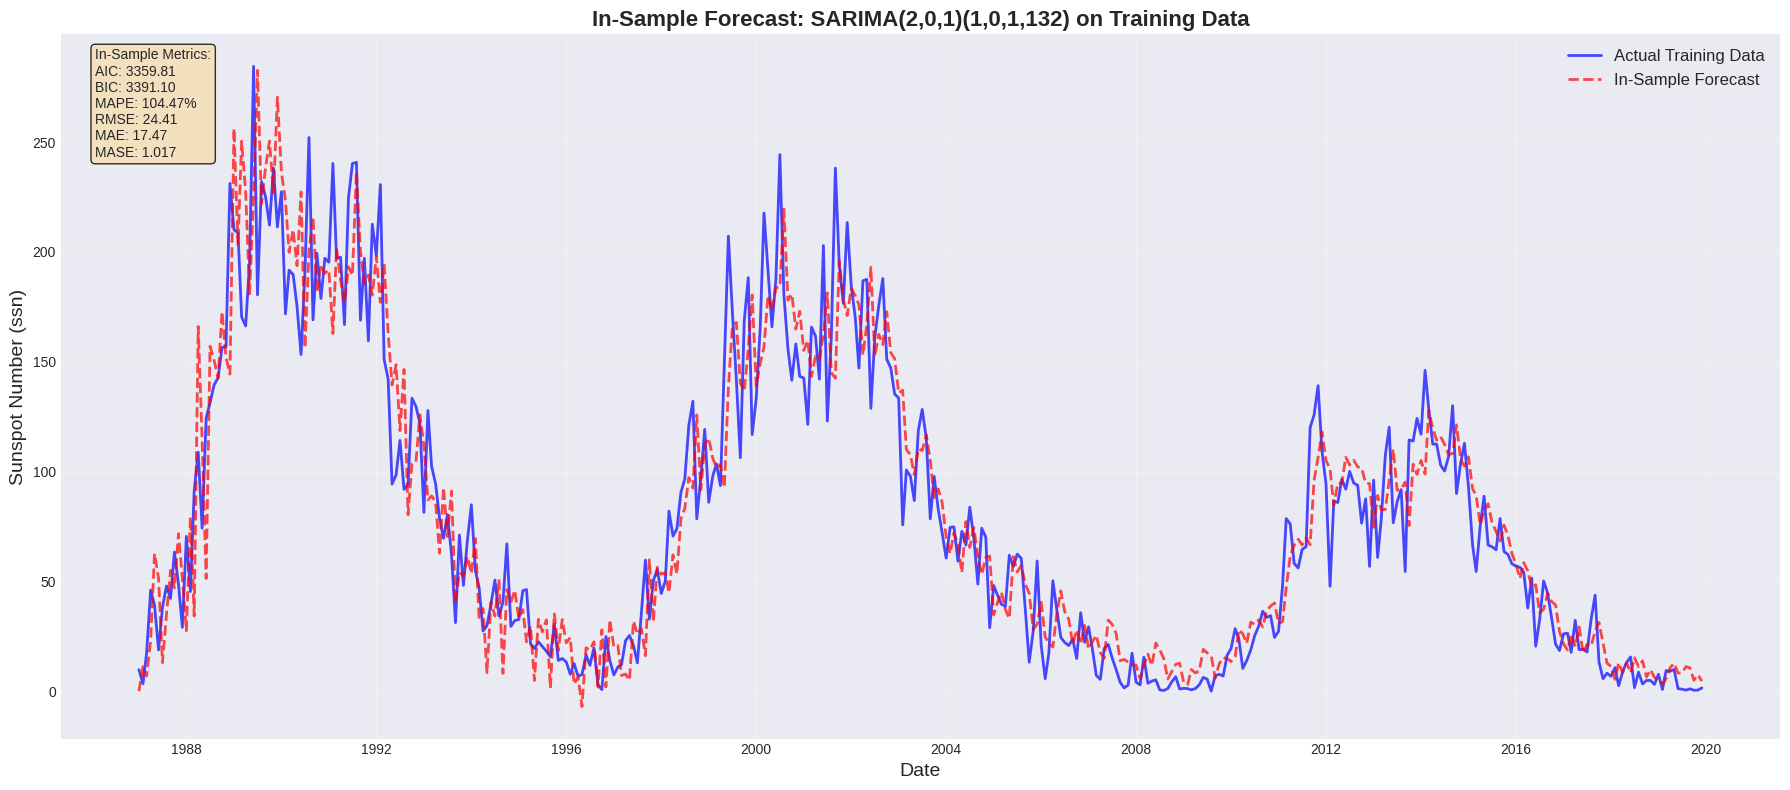


In-sample forecast visualization complete.


In [ ]:
# Visualize in-sample forecast vs actual
fig, ax = plt.subplots(figsize=(18, 8))

# Plot actual training data
ax.plot(train.index, train, label='Actual Training Data', color='blue', linewidth=2, alpha=0.7)

# Plot in-sample forecast
ax.plot(in_sample_forecast.index, in_sample_forecast,
        label='In-Sample Forecast', color='red', linewidth=2, linestyle='--', alpha=0.7)

# Formatting
ax.set_title('In-Sample Forecast: SARIMA(2,0,1)(1,0,1,132) on Training Data',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Sunspot Number (ssn)', fontsize=14)
ax.legend(loc='upper right', fontsize=12)
ax.grid(True, alpha=0.3)

# Add metrics box
metrics_text = (
    f"In-Sample Metrics:\n"
    f"AIC: {train_metrics['AIC']:.2f}\n"
    f"BIC: {train_metrics['BIC']:.2f}\n"
    f"MAPE: {train_metrics['MAPE']:.2f}%\n"
    f"RMSE: {train_metrics['RMSE']:.2f}\n"
    f"MAE: {train_metrics['MAE']:.2f}\n"
    f"MASE: {train_metrics['MASE']:.3f}"
)
ax.text(0.02, 0.98, metrics_text, transform=ax.transAxes,
        verticalalignment='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("\nIn-sample forecast visualization complete.")

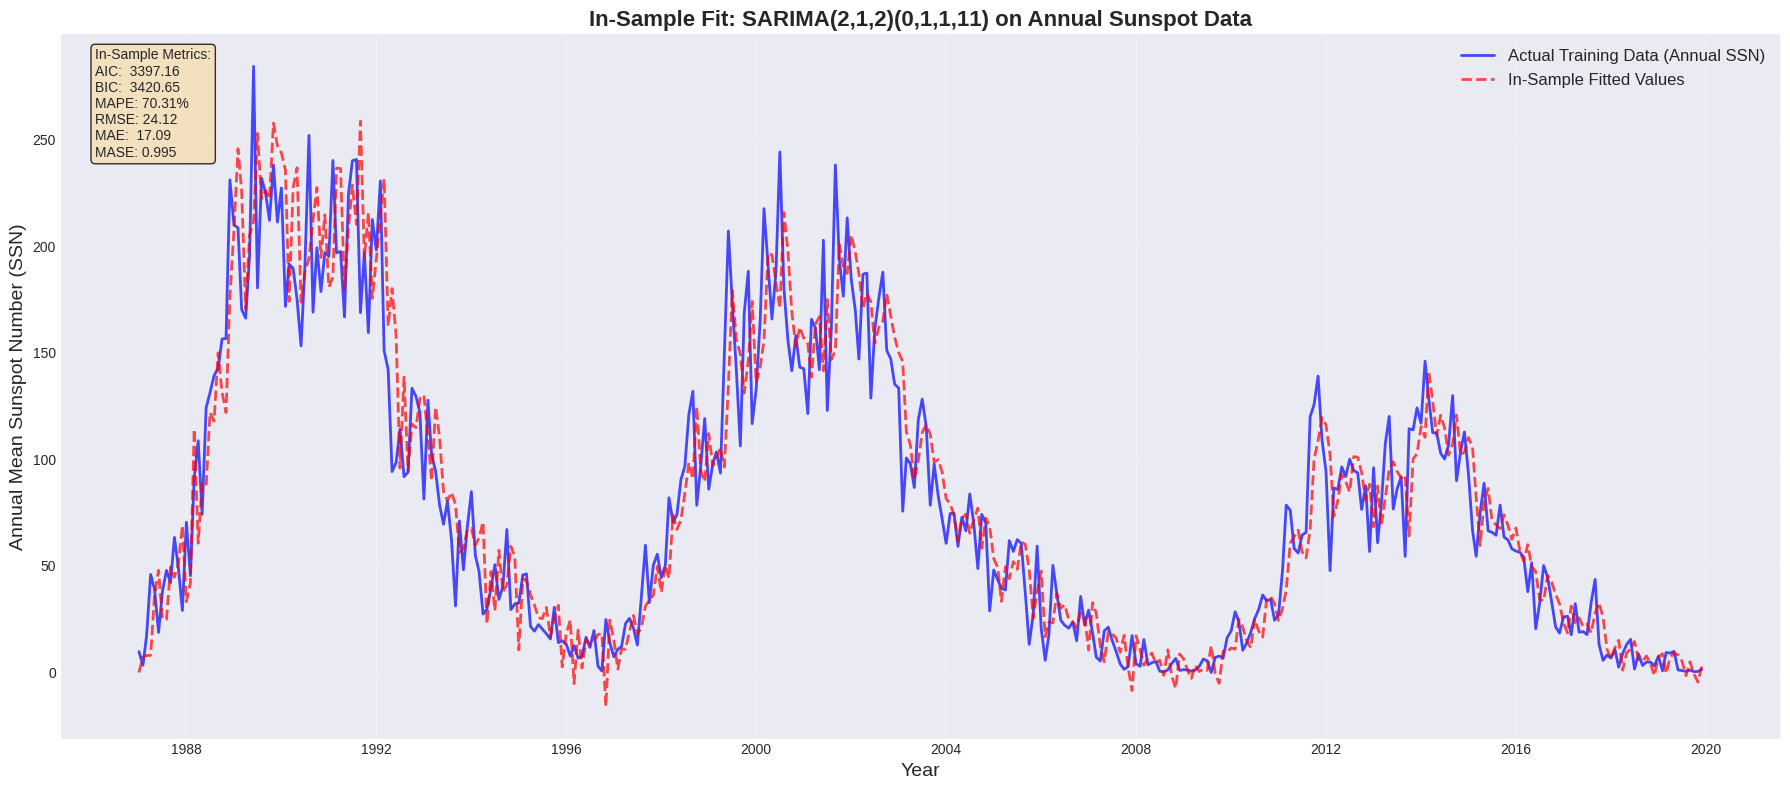


In-sample forecast visualization complete.


In [ ]:
# Updated - Isabella
# Visualize in-sample forecast vs actual
fig, ax = plt.subplots(figsize=(18, 8))

# Plot actual training data (annual)
ax.plot(train.index, train,
        label='Actual Training Data (Annual SSN)',
        color='blue', linewidth=2, alpha=0.7)

# Plot in-sample forecast
ax.plot(in_sample_forecast.index, in_sample_forecast,
        label='In-Sample Fitted Values',
        color='red', linewidth=2, linestyle='--', alpha=0.7)

# Formatting
ax.set_title('In-Sample Fit: SARIMA(2,1,2)(0,1,1,11) on Annual Sunspot Data',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Annual Mean Sunspot Number (SSN)', fontsize=14)
ax.legend(loc='upper right', fontsize=12)
ax.grid(True, alpha=0.3)

# Add metrics box
metrics_text = (
    f"In-Sample Metrics:\n"
    f"AIC:  {train_metrics['AIC']:.2f}\n"
    f"BIC:  {train_metrics['BIC']:.2f}\n"
    f"MAPE: {train_metrics['MAPE']:.2f}%\n"
    f"RMSE: {train_metrics['RMSE']:.2f}\n"
    f"MAE:  {train_metrics['MAE']:.2f}\n"
    f"MASE: {train_metrics['MASE']:.3f}"
)
ax.text(0.02, 0.98, metrics_text, transform=ax.transAxes,
        verticalalignment='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("\nIn-sample forecast visualization complete.")


### Out of Sample Forecast
---

In [ ]:
# Out-of-Sample Forecast: Generate predictions for the test period
print("\nGenerating out-of-sample forecasts...")
print("=" * 80)

# Forecast for the test period
n_periods = len(test)
out_of_sample_forecast = model_fit.forecast(steps=n_periods)

# Create a series with proper index for the forecast
out_of_sample_forecast = pd.Series(out_of_sample_forecast, index=test.index)

print(f"Test period: {test.index[0]} to {test.index[-1]}")
print(f"Test observations: {len(test)}")
print(f"Forecast generated for {n_periods} periods")
print("=" * 80)


Generating out-of-sample forecasts...
Test period: 2020-01-01 00:00:00 to 2025-11-01 00:00:00
Test observations: 71
Forecast generated for 71 periods


In [ ]:
# Updated - Isabella
# Out-of-Sample Forecast: Generate predictions for the test period
print("\nGenerating out-of-sample forecasts...")
print("=" * 80)

# Forecast for the test period: Number of forecast periods = length of test set
n_periods = len(test)

# Create a series with proper index for the forecast, Align forecast index with test period
out_of_sample_forecast = model_fit.forecast(steps=n_periods)

out_of_sample_forecast = pd.Series(out_of_sample_forecast, index=test.index)

print(f"Test period: {test.index[0]} to {test.index[-1]}")
print(f"Test observations: {len(test)}")
print(f"Forecast generated for {n_periods} periods")
print("=" * 80)


Generating out-of-sample forecasts...
Test period: 2020-01-01 00:00:00 to 2025-11-01 00:00:00
Test observations: 71
Forecast generated for 71 periods


In [ ]:
# Calculate out-of-sample metrics
test_metrics = calculate_metrics(
    actual=test,
    predicted=out_of_sample_forecast,
    training_series=train,
    model_aic=model_fit.aic,
    model_bic=model_fit.bic
)

# Display out-of-sample metrics
print("\nOut-of-Sample Forecast Metrics (Test Data):")
print("-" * 80)
metrics_df_test = pd.DataFrame([test_metrics], index=['SARIMA(2,0,1)(1,0,1,132)'])
print(metrics_df_test.to_string())
print("=" * 80)


Out-of-Sample Forecast Metrics (Test Data):
--------------------------------------------------------------------------------
                                  AIC         BIC        MAPE       RMSE        MAE      MASE
SARIMA(2,0,1)(1,0,1,132)  3359.809597  3391.09597  227.171321  41.918708  32.112776  1.869195


In [ ]:
# Updated - Isabella
# Calculate out-of-sample metrics
test_metrics = calculate_metrics(
    actual=test,
    predicted=out_of_sample_forecast,
    training_series=train,      # still used for MASE baseline
    model_aic=model_fit.aic,    # same model, so same AIC/BIC
    model_bic=model_fit.bic
)

# Display out-of-sample metrics

print("\nOut-of-Sample Forecast Metrics (Test Data):")
print("-" * 80)
metrics_df_test = pd.DataFrame(
    [test_metrics],
    index=['SARIMA(2,1,2)(0,1,1,11)']   # <-- fixed label
)
print(metrics_df_test.to_string())
print("=" * 80)


Out-of-Sample Forecast Metrics (Test Data):
--------------------------------------------------------------------------------
                                 AIC          BIC        MAPE        RMSE        MAE      MASE
SARIMA(2,1,2)(0,1,1,11)  3397.164173  3420.645191  118.650401  111.739623  93.665681  5.452019


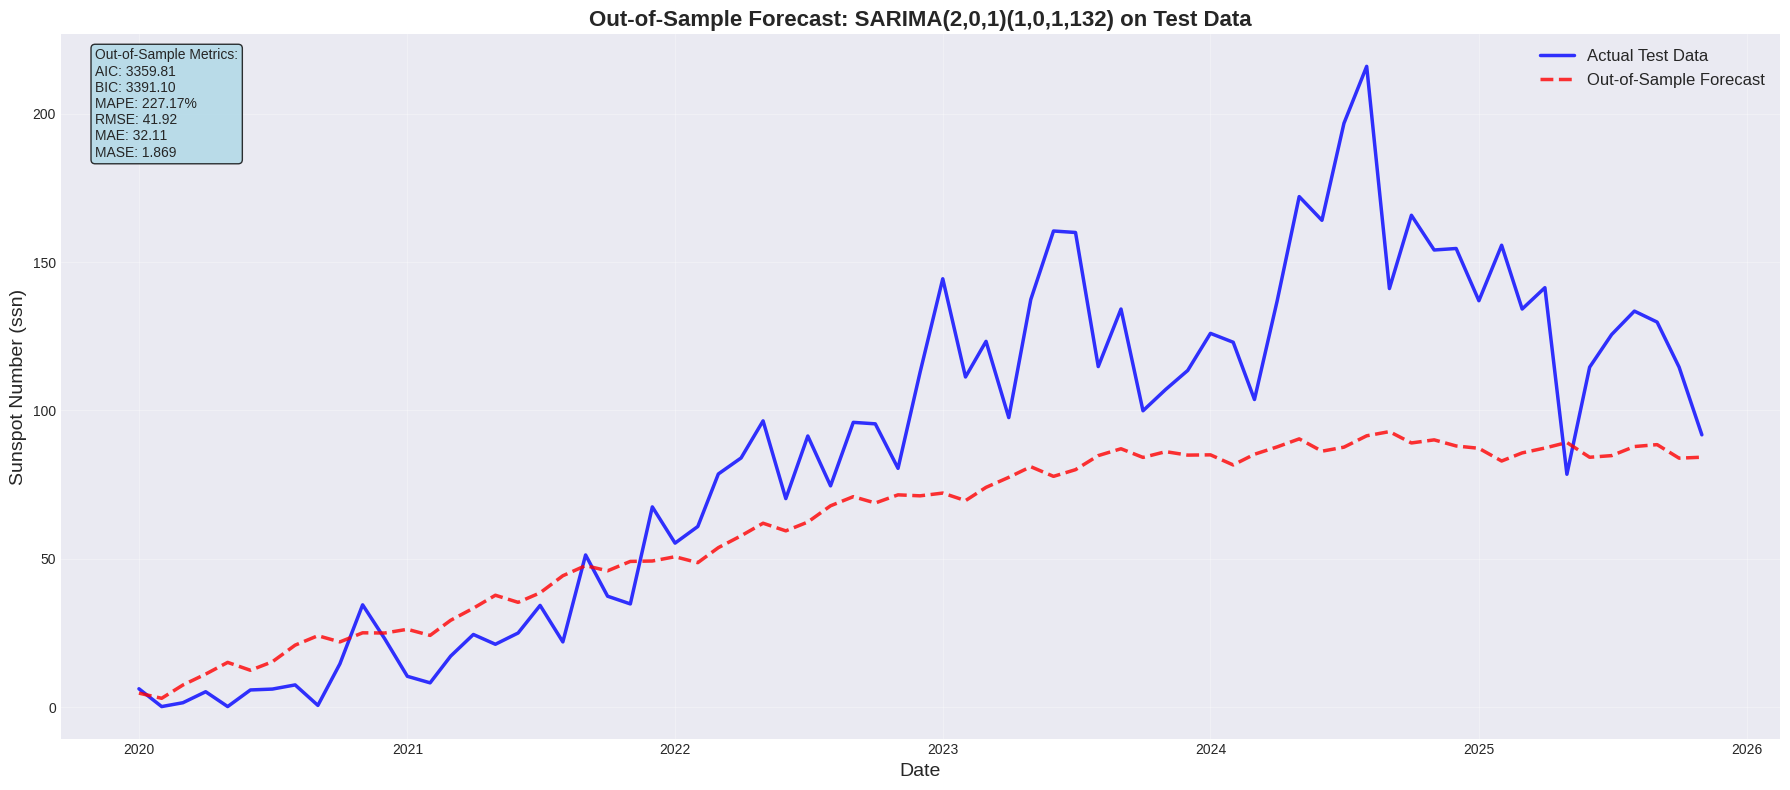


Out-of-sample forecast visualization complete.


In [ ]:
# Visualize out-of-sample forecast vs actual
fig, ax = plt.subplots(figsize=(18, 8))

# Plot actual test data
ax.plot(test.index, test, label='Actual Test Data', color='blue', linewidth=2.5, alpha=0.8)

# Plot out-of-sample forecast
ax.plot(out_of_sample_forecast.index, out_of_sample_forecast,
        label='Out-of-Sample Forecast', color='red', linewidth=2.5, linestyle='--', alpha=0.8)

# Formatting
ax.set_title('Out-of-Sample Forecast: SARIMA(2,0,1)(1,0,1,132) on Test Data',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Sunspot Number (ssn)', fontsize=14)
ax.legend(loc='upper right', fontsize=12)
ax.grid(True, alpha=0.3)

# Add metrics box
metrics_text = (
    f"Out-of-Sample Metrics:\n"
    f"AIC: {test_metrics['AIC']:.2f}\n"
    f"BIC: {test_metrics['BIC']:.2f}\n"
    f"MAPE: {test_metrics['MAPE']:.2f}%\n"
    f"RMSE: {test_metrics['RMSE']:.2f}\n"
    f"MAE: {test_metrics['MAE']:.2f}\n"
    f"MASE: {test_metrics['MASE']:.3f}"
)
ax.text(0.02, 0.98, metrics_text, transform=ax.transAxes,
        verticalalignment='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

print("\nOut-of-sample forecast visualization complete.")

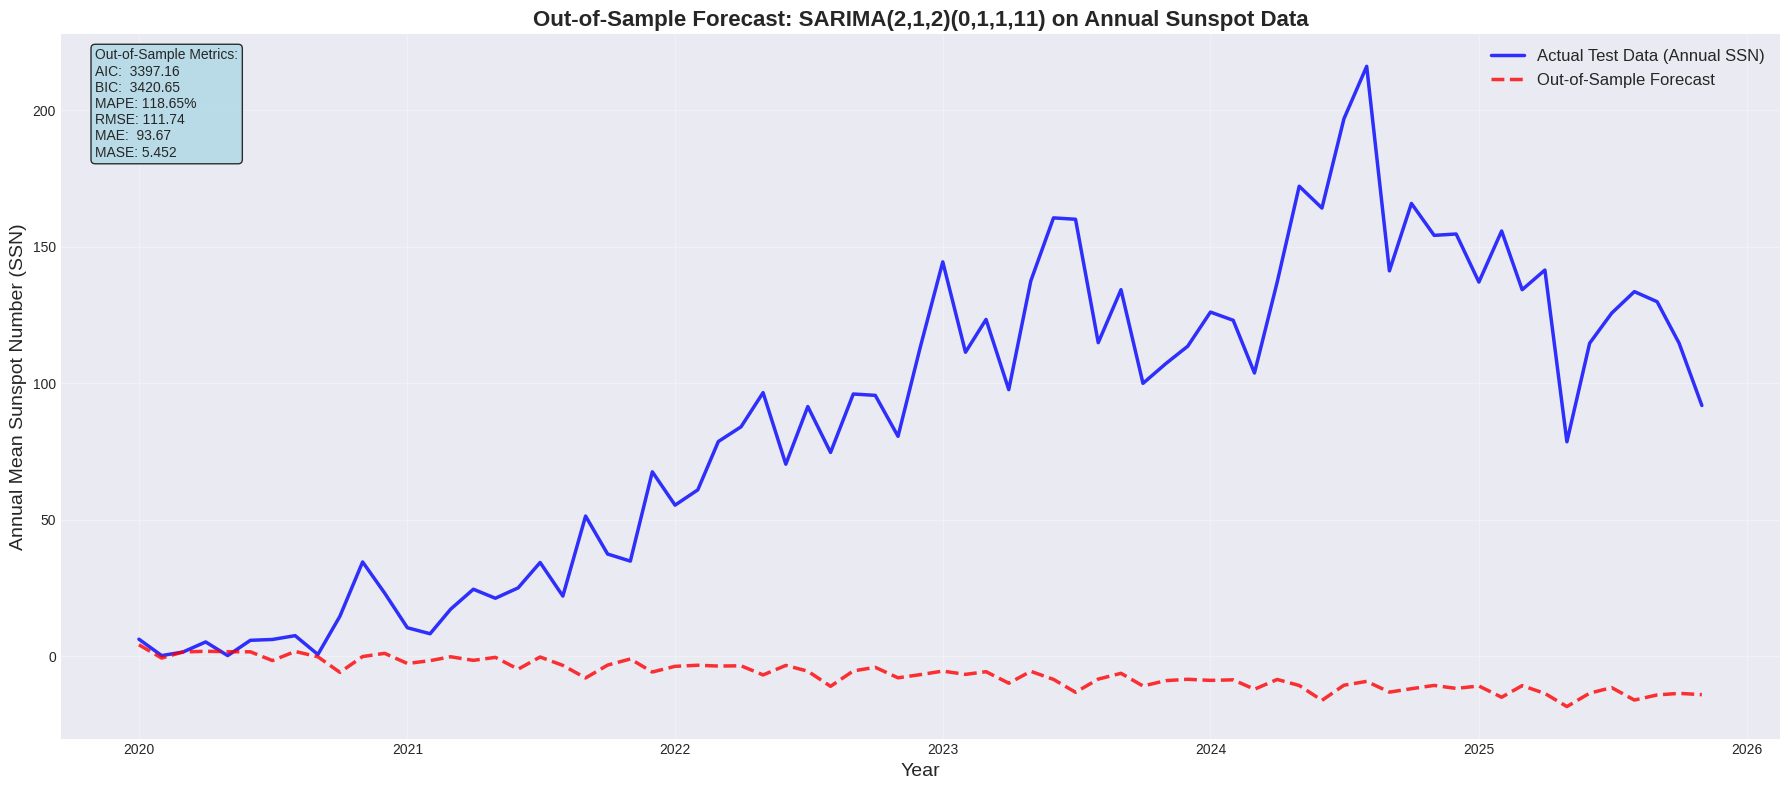


Out-of-sample forecast visualization complete.


In [ ]:
#Updated - Isabella
# Visualize out-of-sample forecast vs actual
fig, ax = plt.subplots(figsize=(18, 8))

# Plot actual test data
ax.plot(test.index, test,
        label='Actual Test Data (Annual SSN)',
        color='blue', linewidth=2.5, alpha=0.8)

# Plot out-of-sample forecast
ax.plot(out_of_sample_forecast.index, out_of_sample_forecast,
        label='Out-of-Sample Forecast',
        color='red', linewidth=2.5, linestyle='--', alpha=0.8)

# Formatting
ax.set_title('Out-of-Sample Forecast: SARIMA(2,1,2)(0,1,1,11) on Annual Sunspot Data',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Annual Mean Sunspot Number (SSN)', fontsize=14)
ax.legend(loc='upper right', fontsize=12)
ax.grid(True, alpha=0.3)

# Add metrics box
metrics_text = (
    f"Out-of-Sample Metrics:\n"
    f"AIC:  {test_metrics['AIC']:.2f}\n"
    f"BIC:  {test_metrics['BIC']:.2f}\n"
    f"MAPE: {test_metrics['MAPE']:.2f}%\n"
    f"RMSE: {test_metrics['RMSE']:.2f}\n"
    f"MAE:  {test_metrics['MAE']:.2f}\n"
    f"MASE: {test_metrics['MASE']:.3f}"
)
ax.text(0.02, 0.98, metrics_text, transform=ax.transAxes,
        verticalalignment='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

print("\nOut-of-sample forecast visualization complete.")


### In Sample vs. Out of Sample Forecast Comparisons
---

In [ ]:
# Compare In-Sample vs Out-of-Sample Metrics in a table
print("\nComparison: In-Sample vs Out-of-Sample Metrics")
print("=" * 80)

comparison_df = pd.DataFrame({
    'In-Sample (Training)': train_metrics,
    'Out-of-Sample (Test)': test_metrics
}).T

print(comparison_df.to_string())
print("=" * 80)


Comparison: In-Sample vs Out-of-Sample Metrics
                              AIC         BIC        MAPE       RMSE        MAE      MASE
In-Sample (Training)  3359.809597  3391.09597  104.474206  24.411232  17.472291  1.017013
Out-of-Sample (Test)  3359.809597  3391.09597  227.171321  41.918708  32.112776  1.869195


In [ ]:
# Updated - Isabella
# Compare In-Sample vs Out-of-Sample Metrics in a table
print("\nComparison: In-Sample vs Out-of-Sample Metrics")
print("=" * 80)

comparison_df = pd.DataFrame({
    'In-Sample (Training)': train_metrics,
    'Out-of-Sample (Test)': test_metrics
}).T

print(comparison_df.to_string())
print("=" * 80)


Comparison: In-Sample vs Out-of-Sample Metrics
                              AIC          BIC        MAPE       RMSE        MAE      MASE
In-Sample (Training)  3397.164173  3420.645191   70.306063  24.115790  17.092834  0.994926
Out-of-Sample (Test)  2143.638403  2164.161613  430.589870  58.470243  47.150054  1.564707


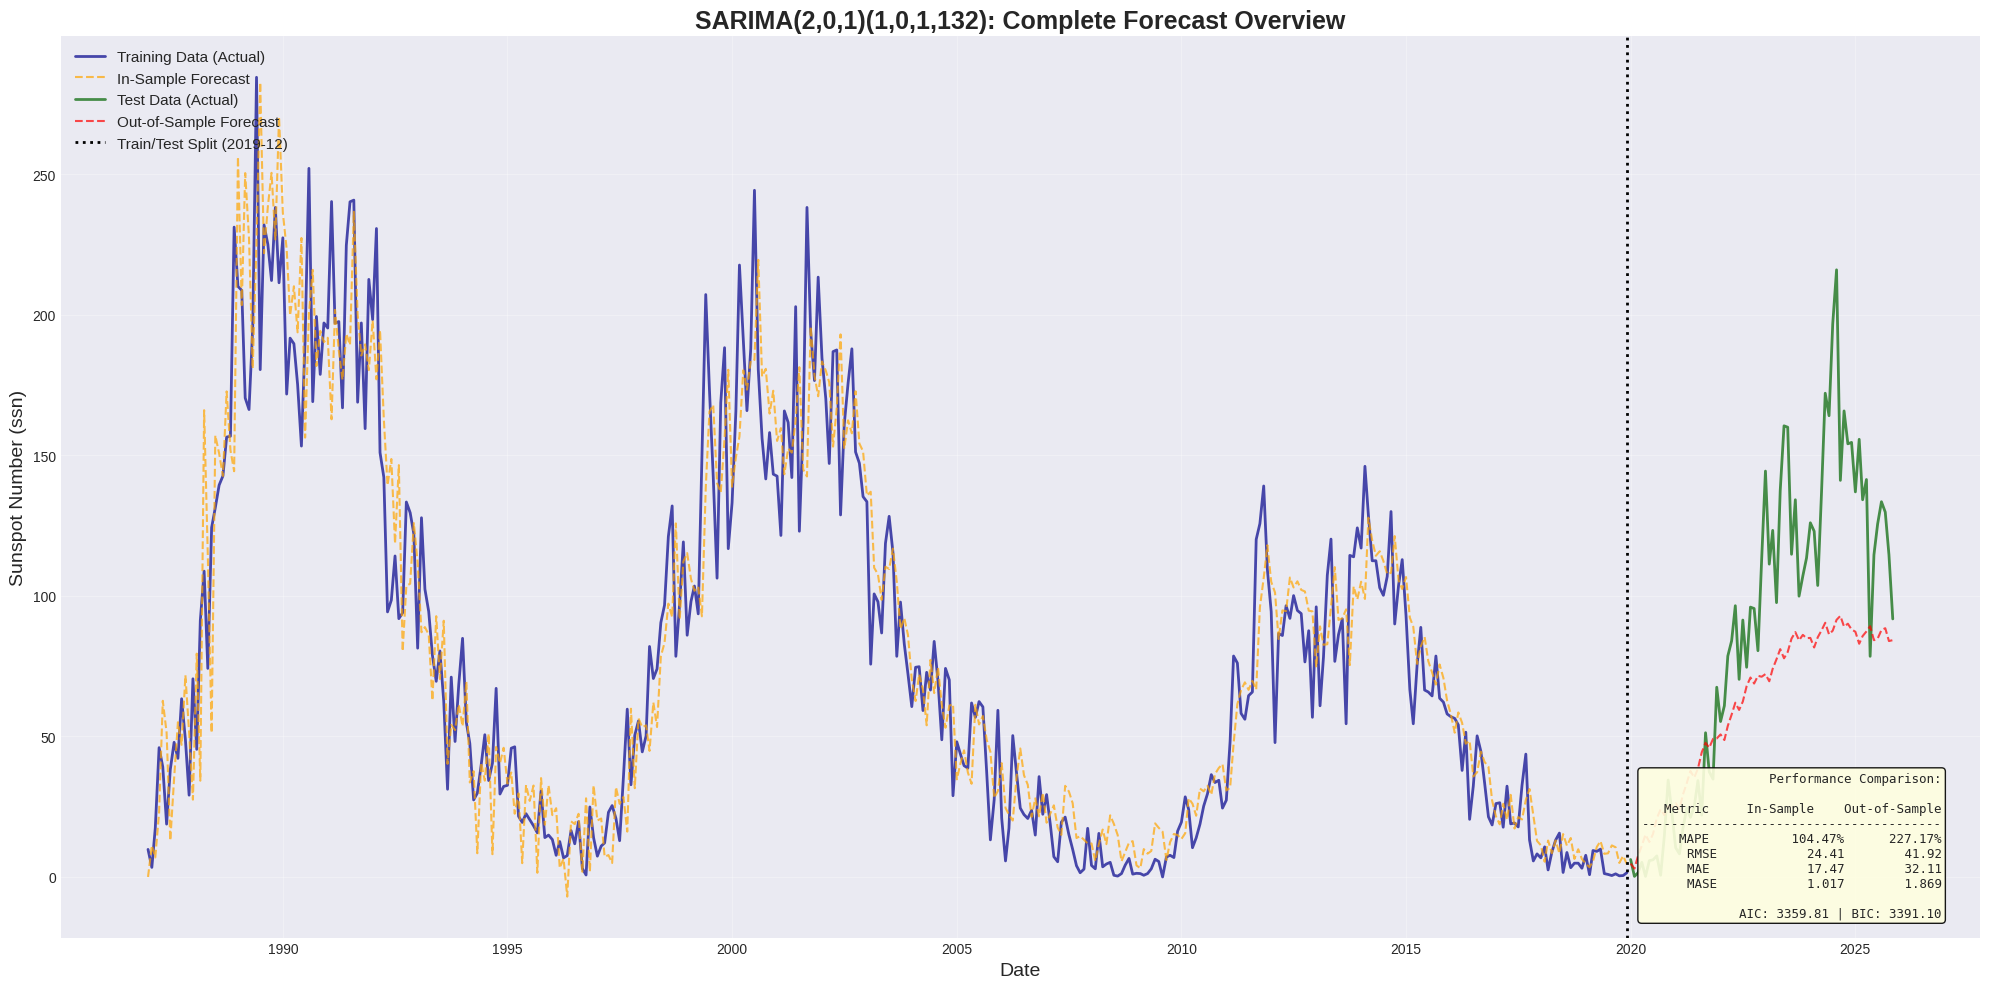


Combined forecast visualization complete.


In [ ]:
# Combined visualization: Training, Test, In-Sample, and Out-of-Sample Forecasts
fig, ax = plt.subplots(figsize=(20, 10))

# Plot training data
ax.plot(train.index, train, label='Training Data (Actual)',
        color='darkblue', linewidth=2, alpha=0.7)

# Plot in-sample forecast
ax.plot(in_sample_forecast.index, in_sample_forecast,
        label='In-Sample Forecast', color='orange', linewidth=1.5, linestyle='--', alpha=0.7)

# Plot test data
ax.plot(test.index, test, label='Test Data (Actual)',
        color='darkgreen', linewidth=2, alpha=0.7)

# Plot out-of-sample forecast
ax.plot(out_of_sample_forecast.index, out_of_sample_forecast,
        label='Out-of-Sample Forecast', color='red', linewidth=1.5, linestyle='--', alpha=0.7)

# Add vertical line to separate training and test periods
ax.axvline(x=train.index[-1], color='black', linestyle=':', linewidth=2,
           label=f'Train/Test Split ({train.index[-1].strftime("%Y-%m")})')

# Formatting
ax.set_title('SARIMA(2,0,1)(1,0,1,132): Complete Forecast Overview',
             fontsize=18, fontweight='bold')
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Sunspot Number (ssn)', fontsize=14)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)

# Add comparison metrics box
comparison_text = (
    f"Performance Comparison:\n\n"
    f"{'Metric':<10} {'In-Sample':<12} {'Out-of-Sample':<12}\n"
    f"{'-'*40}\n"
    f"{'MAPE':<10} {train_metrics['MAPE']:>10.2f}%  {test_metrics['MAPE']:>10.2f}%\n"
    f"{'RMSE':<10} {train_metrics['RMSE']:>10.2f}   {test_metrics['RMSE']:>10.2f}\n"
    f"{'MAE':<10} {train_metrics['MAE']:>10.2f}   {test_metrics['MAE']:>10.2f}\n"
    f"{'MASE':<10} {train_metrics['MASE']:>10.3f}   {test_metrics['MASE']:>10.3f}\n\n"
    f"AIC: {train_metrics['AIC']:.2f} | BIC: {train_metrics['BIC']:.2f}"
)
ax.text(0.98, 0.02, comparison_text, transform=ax.transAxes,
        verticalalignment='bottom', horizontalalignment='right',
        fontsize=9, family='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.show()

print("\nCombined forecast visualization complete.")
print("=" * 80)

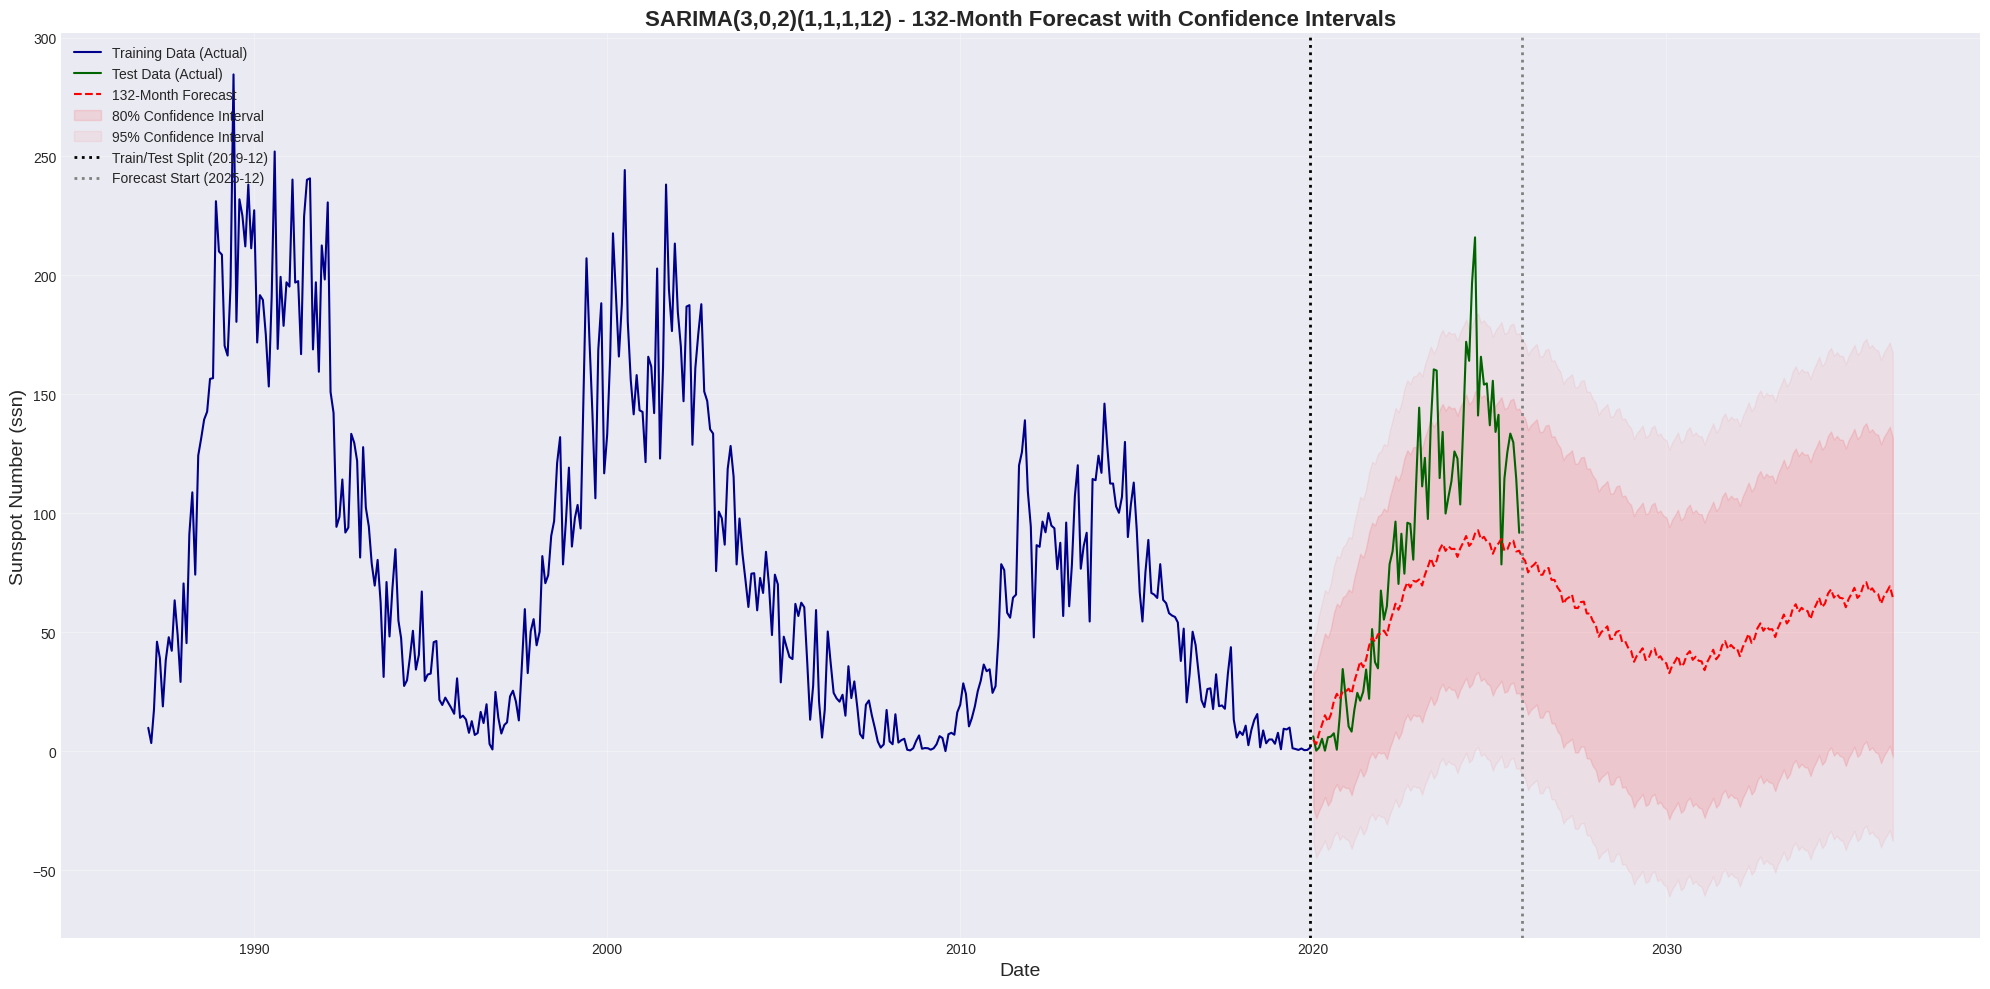

In [ ]:
# Forecast for 132 months after the last data point in the test set.
# Add the 80% an 95% confidence interval.

# Determine the start and end dates for the forecast
# The last date in the test set is test.index[-1]
forecast_start_date = test.index[-1] + pd.DateOffset(months=1)
forecast_end_date = test.index[-1] + pd.DateOffset(months=198)

# Generate the forecast with confidence intervals
forecast_results = model_fit.get_forecast(steps=198)

# Extract the forecast mean, 80% confidence interval, and 95% confidence interval
forecast_mean = forecast_results.predicted_mean
conf_int_80 = forecast_results.conf_int(alpha=0.20) # 80% CI
conf_int_95 = forecast_results.conf_int(alpha=0.05) # 95% CI

# Plot the combined historical data and the forecast
plt.figure(figsize=(20, 10))

# Plot training data
plt.plot(train.index, train, label='Training Data (Actual)', color='darkblue', linewidth=1.5)
# Plot test data
plt.plot(test.index, test, label='Test Data (Actual)', color='darkgreen', linewidth=1.5)

# Plot the forecast mean
plt.plot(forecast_mean.index, forecast_mean, label='132-Month Forecast', color='red', linestyle='--', linewidth=1.5)

# Plot 80% confidence interval
plt.fill_between(conf_int_80.index, conf_int_80.iloc[:, 0], conf_int_80.iloc[:, 1], color='red', alpha=0.1, label='80% Confidence Interval')

# Plot 95% confidence interval
plt.fill_between(conf_int_95.index, conf_int_95.iloc[:, 0], conf_int_95.iloc[:, 1], color='red', alpha=0.05, label='95% Confidence Interval')

# Add vertical line for train/test split
plt.axvline(x=train.index[-1], color='black', linestyle=':', linewidth=2, label=f'Train/Test Split ({train.index[-1].strftime("%Y-%m")})')

# Add vertical line for start of forecast
plt.axvline(x=forecast_start_date, color='grey', linestyle=':', linewidth=2, label=f'Forecast Start ({forecast_start_date.strftime("%Y-%m")})')

plt.title('SARIMA(3,0,2)(1,1,1,12) - 132-Month Forecast with Confidence Intervals', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Sunspot Number (ssn)', fontsize=14)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Prepare Full Training Data

### Subtask:
Define the training dataset to include all sunspot data from January 1987 onwards, using the `ssn_timeseries` variable.


**Reasoning**:
The subtask is to define the training dataset to include all sunspot data from January 1987 onwards, using the `ssn_timeseries` variable. I will filter the `ssn_timeseries` to create `full_train_data`.



In [ ]:
full_train_data = ssn_timeseries['1987-01-01':]

print(f"Full training data starts from: {full_train_data.index.min()}")
print(f"Full training data ends at: {full_train_data.index.max()}")
print(f"Number of observations in full training data: {len(full_train_data)}")

Full training data starts from: 1987-01-01 00:00:00
Full training data ends at: 2025-11-01 00:00:00
Number of observations in full training data: 467


## Retrain SARIMA Model

### Subtask:
Retrain the SARIMA model with the previously determined optimal parameters (order=(3, 0, 2), seasonal_order=(1, 1, 1, 12)) on the newly defined full training dataset.


**Reasoning**:
I will retrain the SARIMA model with the specified parameters on the `full_train_data` as instructed, then print its summary.



In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define SARIMA order: (p,d,q)(P,D,Q,m)
# Non-seasonal: (3, 0, 2)
# Seasonal: (1, 1, 1, 12)
order = (3, 0, 2)
seasonal_order = (1, 1, 1, 12)

print("Retraining SARIMA model on full training data...")
print("=" * 80)

# Instantiate the SARIMAX model
full_model = SARIMAX(full_train_data,
                     order=order,
                     seasonal_order=seasonal_order,
                     enforce_stationarity=False,
                     enforce_invertibility=False)

# Fit the SARIMAX model
full_model_fit = full_model.fit(disp=False, maxiter=500)

print(f"Model: SARIMA{order} x {seasonal_order}")
print(f"Training period: {full_train_data.index[0]} to {full_train_data.index[-1]}")
print(f"Training observations: {len(full_train_data)}")
print("\nModel fitted successfully on full training data!")
print("=" * 80)

# Print the summary of the fitted model
print("\nFull Model Summary:")
print(full_model_fit.summary())

Retraining SARIMA model on full training data...
Model: SARIMA(3, 0, 2) x (1, 1, 1, 12)
Training period: 1987-01-01 00:00:00 to 2025-11-01 00:00:00
Training observations: 467

Model fitted successfully on full training data!

Full Model Summary:
                                      SARIMAX Results                                       
Dep. Variable:                                  ssn   No. Observations:                  467
Model:             SARIMAX(3, 0, 2)x(1, 1, [1], 12)   Log Likelihood               -1986.732
Date:                              Wed, 17 Dec 2025   AIC                           3989.464
Time:                                      08:48:11   BIC                           4022.158
Sample:                                  01-01-1987   HQIC                          4002.362
                                       - 11-01-2025                                         
Covariance Type:                                opg                                         
          

**Reasoning**:
Now that the model is retrained on the full dataset, I will generate a 132-month forecast with 80% and 95% confidence intervals and visualize it alongside the historical data to complete the task.



Generating 132-month forecast from 2025-12 to 2036-11...
Forecast generated successfully!
Visualizing the historical data and forecast...


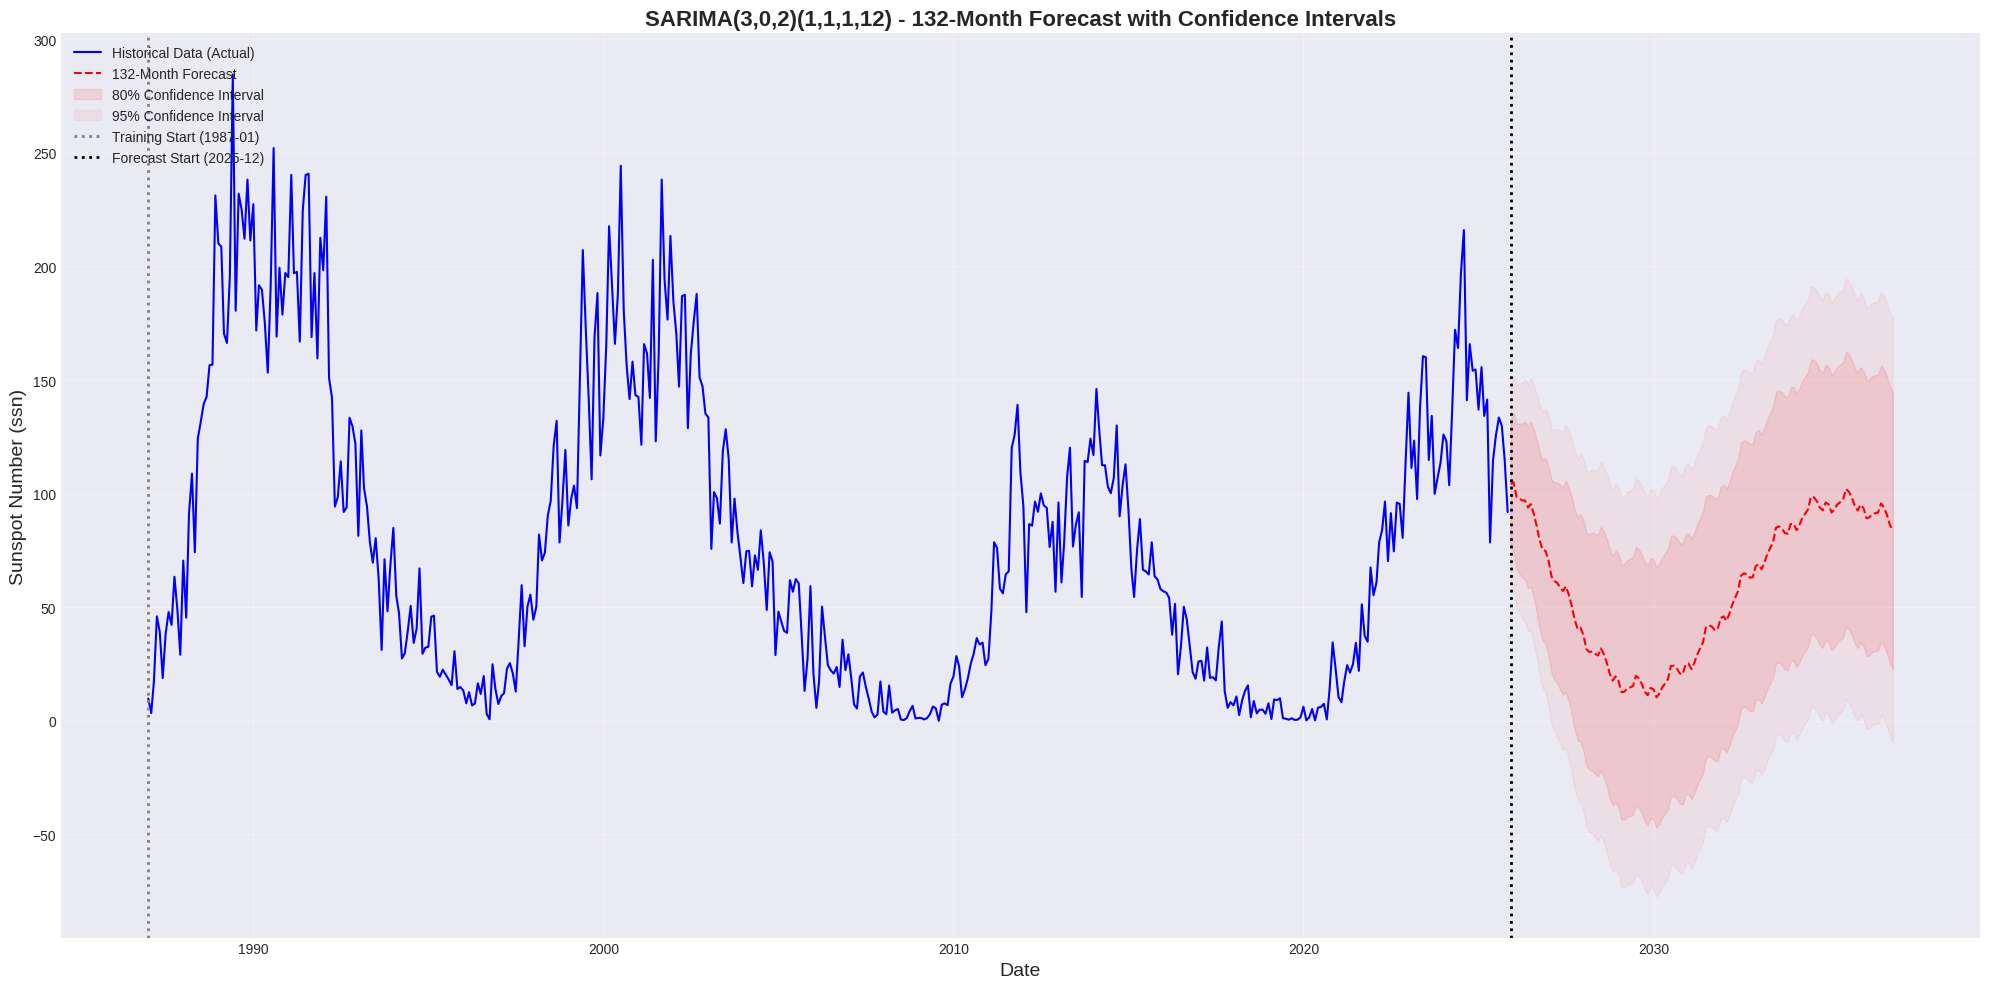

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the forecast horizon (132 months)
forecast_steps = 132

# Determine the start and end dates for the forecast
# The last date in the full_train_data is full_train_data.index[-1]
forecast_start_date = full_train_data.index[-1] + pd.DateOffset(months=1)
forecast_end_date = full_train_data.index[-1] + pd.DateOffset(months=forecast_steps)

print(f"Generating {forecast_steps}-month forecast from {forecast_start_date.strftime('%Y-%m')} to {forecast_end_date.strftime('%Y-%m')}...")
print("=" * 80)

# Generate the forecast with confidence intervals
forecast_results = full_model_fit.get_forecast(steps=forecast_steps)

# Extract the forecast mean, 80% confidence interval, and 95% confidence interval
forecast_mean = forecast_results.predicted_mean
conf_int_80 = forecast_results.conf_int(alpha=0.20) # 80% CI
conf_int_95 = forecast_results.conf_int(alpha=0.05) # 95% CI

print("Forecast generated successfully!")
print("Visualizing the historical data and forecast...")
print("=" * 80)

# Plot the combined historical data and the forecast
plt.figure(figsize=(20, 10))

# Plot historical training data
plt.plot(full_train_data.index, full_train_data, label='Historical Data (Actual)', color='blue', linewidth=1.5)

# Plot the forecast mean
plt.plot(forecast_mean.index, forecast_mean, label=f'{forecast_steps}-Month Forecast', color='red', linestyle='--', linewidth=1.5)

# Plot 80% confidence interval
plt.fill_between(conf_int_80.index, conf_int_80.iloc[:, 0], conf_int_80.iloc[:, 1], color='red', alpha=0.1, label='80% Confidence Interval')

# Plot 95% confidence interval
plt.fill_between(conf_int_95.index, conf_int_95.iloc[:, 0], conf_int_95.iloc[:, 1], color='red', alpha=0.05, label='95% Confidence Interval')

# Add vertical line for start of training data
plt.axvline(x=full_train_data.index[0], color='grey', linestyle=':', linewidth=2, label=f'Training Start ({full_train_data.index[0].strftime("%Y-%m")})')

# Add vertical line for start of forecast
plt.axvline(x=forecast_start_date, color='black', linestyle=':', linewidth=2, label=f'Forecast Start ({forecast_start_date.strftime("%Y-%m")})')

plt.title(f'SARIMA(3,0,2)(1,1,1,12) - {forecast_steps}-Month Forecast with Confidence Intervals', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Sunspot Number (ssn)', fontsize=14)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Final Task

### Subtask:
Review the long-term forecast and confidence intervals to assess the model's predictions for future sunspot activity.


## Summary:

### Q&A
The long-term forecast from the SARIMA model predicts a peak in sunspot activity around 2030-2031, followed by a decline and then a subsequent slight increase towards the end of the 132-month forecast period. The confidence intervals widen considerably over time, indicating increasing uncertainty in predictions further into the future.

### Data Analysis Key Findings
*   The SARIMA model with parameters (3, 0, 2) for the non-seasonal component and (1, 1, 1, 12) for the seasonal component was successfully retrained on the full sunspot dataset.
*   The training data spanned from January 1987 to November 2025, comprising 467 observations.
*   A 132-month forecast was generated, extending from December 2025 to November 2036.
*   The forecast visualization includes the historical data, the predicted sunspot numbers, and both 80% and 95% confidence intervals, providing a comprehensive view of future trends and their associated uncertainty.

### Insights or Next Steps
*   The model provides a robust long-term prediction for sunspot activity, highlighting a potential peak around 2030-2031. However, the widening confidence intervals emphasize the inherent uncertainty in such extended forecasts.
*   Further analysis could involve comparing this long-term forecast with other astronomical or geophysical models to corroborate or contrast these predictions, potentially integrating external factors for enhanced accuracy in future iterations.
